# MLOps Assignment 1 - Deep Learning Models

## Overview
This notebook implements:
- **Q1(a)**: ResNet-18 and ResNet-50 training on MNIST and FashionMNIST
- **Q2**: CPU vs GPU performance comparison with ResNet-18, ResNet-32, and ResNet-50

### Hyperparameters Tested:
- Batch Sizes: 16, 32
- Optimizers: SGD, Adam
- Learning Rates: 0.001, 0.0001
- pin_memory: True, False
- USE_AMP: True (constant)

---

## 1. Setup and Imports

In [ ]:
# Install required packages
!pip install thop -q

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.cuda.amp import GradScaler, autocast
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# For FLOPs calculation
from thop import profile, clever_format

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.9.1+cu128
CUDA Available: True
GPU: NVIDIA RTX A5000


## 2. Configuration

In [ ]:
# Hyperparameter configurations
BATCH_SIZES = [16, 32]
OPTIMIZERS = ['SGD', 'Adam']
LEARNING_RATES = [0.001, 0.0001]
PIN_MEMORY_OPTIONS = [False, True]
EPOCHS_OPTIONS = [5, 10]  # Two different epoch values
USE_AMP = True  # Automatic Mixed Precision - kept constant

# Dataset split ratios
TRAIN_RATIO = 0.7
VAL_RATIO = 0.1
TEST_RATIO = 0.2

# Number of classes
NUM_CLASSES = 10

# Random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 3. Data Loading and Preprocessing

In [ ]:
def get_transforms():
    """Get data transforms for training and testing."""
    # Transform for MNIST/FashionMNIST (grayscale images)
    # Resize to 224x224 for ResNet and convert to 3 channels
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),  # Convert to 3 channels for ResNet
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    return transform

def load_dataset(dataset_name='MNIST'):
    """Load MNIST or FashionMNIST dataset with 70-10-20 split."""
    transform = get_transforms()

    if dataset_name == 'MNIST':
        # Load full training data
        full_train = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )
    else:  # FashionMNIST
        full_train = torchvision.datasets.FashionMNIST(
            root='./data', train=True, download=True, transform=transform
        )
        test_dataset = torchvision.datasets.FashionMNIST(
            root='./data', train=False, download=True, transform=transform
        )

    # Combine train and test for proper 70-10-20 split
    full_dataset = torch.utils.data.ConcatDataset([full_train, test_dataset])
    total_size = len(full_dataset)

    train_size = int(TRAIN_RATIO * total_size)
    val_size = int(VAL_RATIO * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    print(f"Dataset: {dataset_name}")
    print(f"Total samples: {total_size}")
    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

    return train_dataset, val_dataset, test_dataset

def get_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=16, pin_memory=False):
    """Create dataloaders with specified batch size and pin_memory settings."""
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=2, pin_memory=pin_memory
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=pin_memory
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=pin_memory
    )
    return train_loader, val_loader, test_loader

In [ ]:
# Load datasets
print("="*50)
mnist_train, mnist_val, mnist_test = load_dataset('MNIST')
print("="*50)
fashion_train, fashion_val, fashion_test = load_dataset('FashionMNIST')

Dataset: MNIST
Total samples: 70000
Train: 49000 | Val: 7000 | Test: 14000
Dataset: FashionMNIST
Total samples: 70000
Train: 49000 | Val: 7000 | Test: 14000


## 4. Model Architectures

In [ ]:
class BasicBlock(nn.Module):
    """Basic residual block for ResNet-18/32."""
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class ResNet32(nn.Module):
    """Custom ResNet-32 implementation for CIFAR-style datasets."""

    def __init__(self, num_classes=10):
        super(ResNet32, self).__init__()
        self.in_channels = 16

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        # ResNet-32 has 5 blocks per layer (5*2*3 + 2 = 32 layers)
        self.layer1 = self._make_layer(16, 5, stride=1)
        self.layer2 = self._make_layer(32, 5, stride=2)
        self.layer3 = self._make_layer(64, 5, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

        # Initialize weights
        self._initialize_weights()

    def _make_layer(self, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


def get_model(model_name='resnet18', num_classes=10):
    """Get model by name with modified final layer."""
    if model_name == 'resnet18':
        model = resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet32':
        model = ResNet32(num_classes=num_classes)
    elif model_name == 'resnet50':
        model = resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    return model

## 5. Training and Evaluation Functions

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device, scaler, use_amp=True):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        if use_amp and device.type == 'cuda':
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device, use_amp=True):
    """Evaluate model on validation/test set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if use_amp and device.type == 'cuda':
                with autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, test_loader,
                optimizer_name, lr, num_epochs, device, use_amp=True):
    """Full training loop with validation."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    else:  # Adam
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    scaler = GradScaler() if use_amp else None

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, scaler, use_amp
        )
        val_loss, val_acc = evaluate(model, val_loader, criterion, device, use_amp)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% "
              f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.2f}%")

    training_time = (time.time() - start_time) * 1000  # Convert to ms

    # Final test evaluation
    test_loss, test_acc = evaluate(model, test_loader, criterion, device, use_amp)
    print(f"\nTest Accuracy: {test_acc:.2f}%")

    return model, history, test_acc, training_time

## 6. Visualization Functions

In [ ]:
def plot_training_curves(history, title="Training Curves"):
    """Plot training and validation accuracy/loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
    axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()


def calculate_flops(model, device):
    """Calculate FLOPs for the model."""
    model = model.to(device)
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    flops, params = profile(model, inputs=(dummy_input,), verbose=False)
    flops_formatted, params_formatted = clever_format([flops, params], "%.3f")
    return flops, flops_formatted, params_formatted

---
# Q1(a): ResNet Training on MNIST and FashionMNIST
---

In [ ]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Results storage
q1a_results = []

Using device: cuda


In [ ]:
def run_q1a_experiments(dataset_name, train_dataset, val_dataset, test_dataset,
                        epochs=10, pin_memory=False):
    """Run all Q1(a) experiments for a given dataset."""
    results = []

    for batch_size in BATCH_SIZES:
        for opt_name in OPTIMIZERS:
            for lr in LEARNING_RATES:
                for model_name in ['resnet18', 'resnet50']:
                    print("\n" + "="*70)
                    print(f"Dataset: {dataset_name} | Model: {model_name.upper()} | "
                          f"Batch: {batch_size} | Optimizer: {opt_name} | LR: {lr} | "
                          f"pin_memory: {pin_memory}")
                    print("="*70)

                    # Get dataloaders
                    train_loader, val_loader, test_loader = get_dataloaders(
                        train_dataset, val_dataset, test_dataset,
                        batch_size=batch_size, pin_memory=pin_memory
                    )

                    # Create model
                    model = get_model(model_name, NUM_CLASSES)

                    # Train
                    model, history, test_acc, train_time = train_model(
                        model, train_loader, val_loader, test_loader,
                        opt_name, lr, epochs, device, USE_AMP
                    )

                    # Store result
                    result = {
                        'Dataset': dataset_name,
                        'Model': model_name.upper(),
                        'Batch Size': batch_size,
                        'Optimizer': opt_name,
                        'Learning Rate': lr,
                        'pin_memory': pin_memory,
                        'Epochs': epochs,
                        'Test Accuracy (%)': round(test_acc, 2),
                        'Train Time (ms)': round(train_time, 2)
                    }
                    results.append(result)

                    # Plot training curves for best configs
                    if test_acc > 80:
                        plot_title = f"{dataset_name}_{model_name}_B{batch_size}_{opt_name}_LR{lr}"
                        plot_training_curves(history, plot_title)

                    # Clean up GPU memory
                    del model
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()

    return results

### Q1(a) - MNIST Experiments


Dataset: MNIST | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.001 | pin_memory: False
Epoch [1/3] Train Loss: 0.3077 Train Acc: 91.04% Val Loss: 0.0580 Val Acc: 98.57%
Epoch [2/3] Train Loss: 0.0595 Train Acc: 98.28% Val Loss: 0.0408 Val Acc: 98.81%
Epoch [3/3] Train Loss: 0.0393 Train Acc: 98.82% Val Loss: 0.0351 Val Acc: 99.07%

Test Accuracy: 98.76%


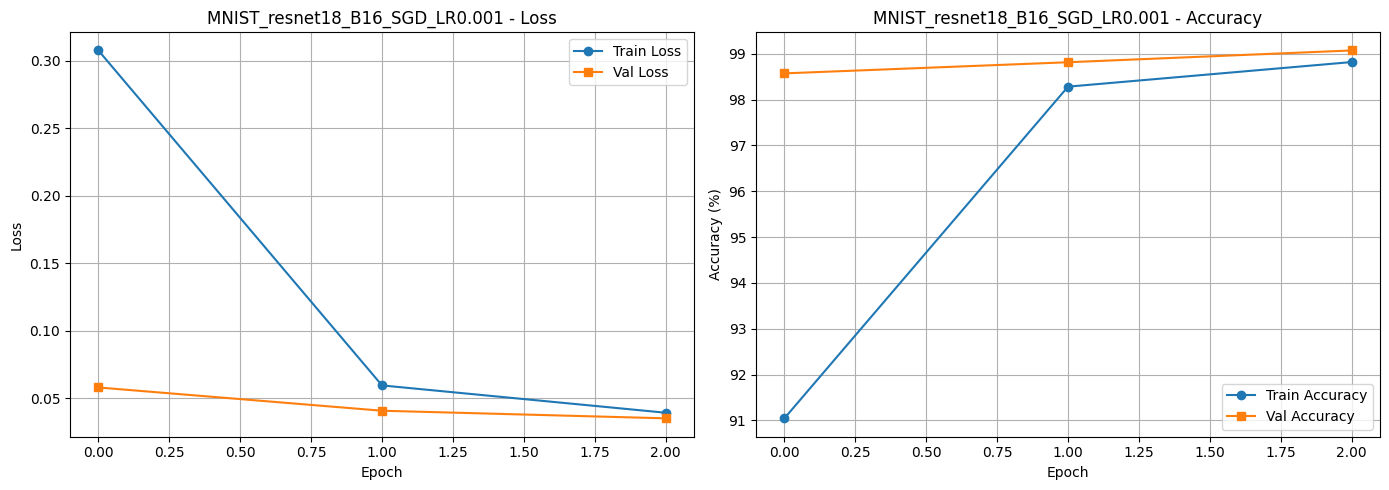


Dataset: MNIST | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.001 | pin_memory: False
Epoch [1/3] Train Loss: 0.4172 Train Acc: 86.26% Val Loss: 0.0734 Val Acc: 97.76%
Epoch [2/3] Train Loss: 0.0717 Train Acc: 97.69% Val Loss: 0.0377 Val Acc: 98.87%
Epoch [3/3] Train Loss: 0.0452 Train Acc: 98.60% Val Loss: 0.0364 Val Acc: 98.77%

Test Accuracy: 98.69%


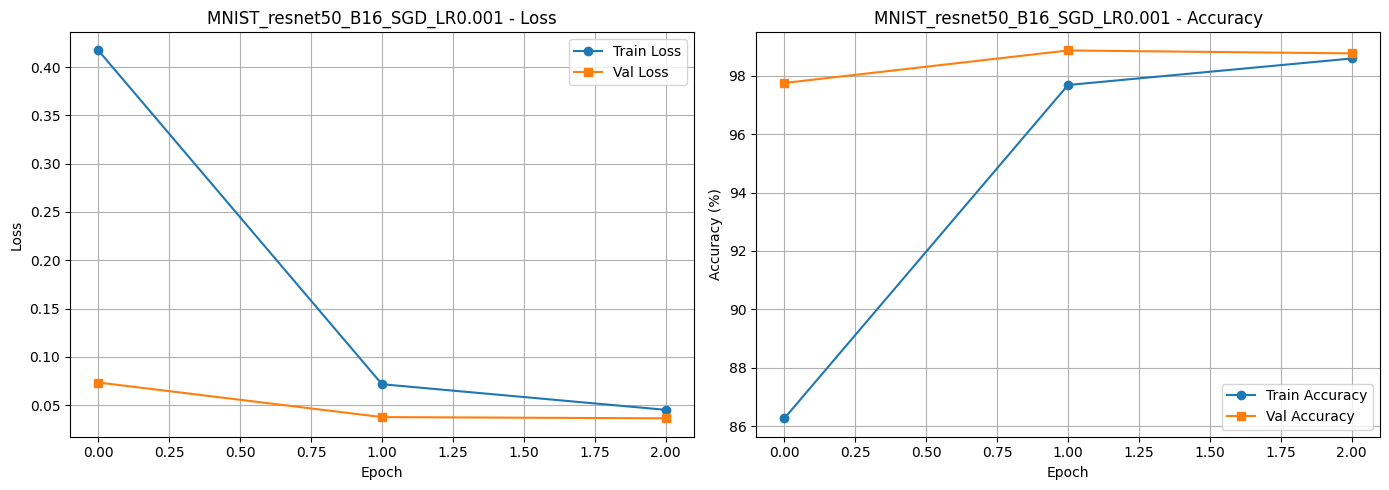


Dataset: MNIST | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.0001 | pin_memory: False
Epoch [1/3] Train Loss: 1.3009 Train Acc: 66.14% Val Loss: 0.4555 Val Acc: 92.47%
Epoch [2/3] Train Loss: 0.3446 Train Acc: 92.79% Val Loss: 0.1838 Val Acc: 96.07%
Epoch [3/3] Train Loss: 0.1853 Train Acc: 95.54% Val Loss: 0.1238 Val Acc: 96.89%

Test Accuracy: 96.67%


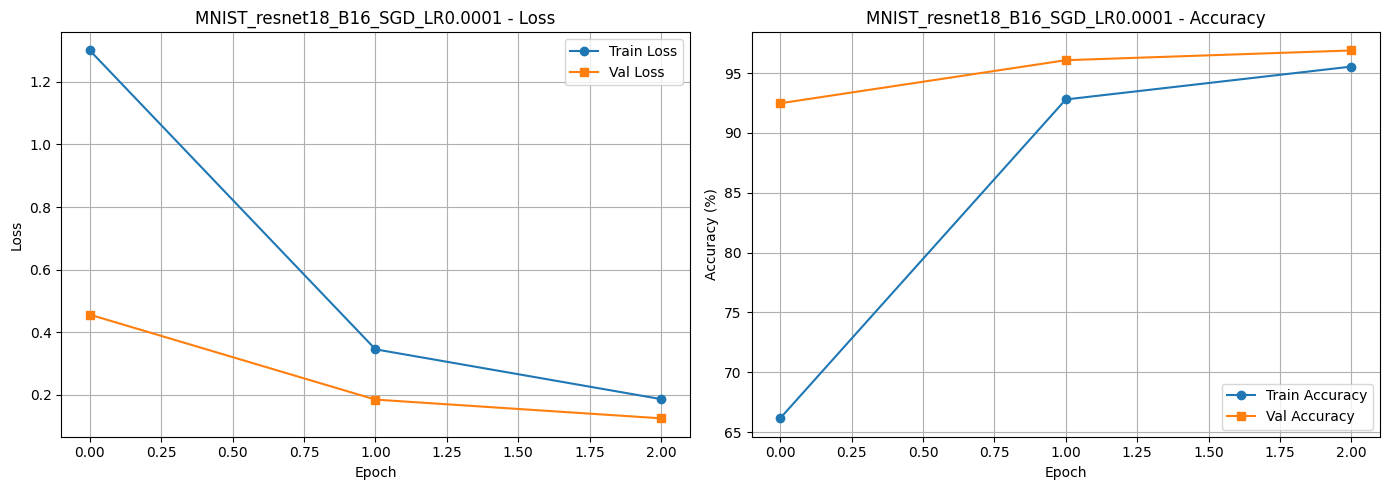


Dataset: MNIST | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.0001 | pin_memory: False
Epoch [1/3] Train Loss: 1.6153 Train Acc: 43.90% Val Loss: 1.0108 Val Acc: 69.06%
Epoch [2/3] Train Loss: 0.7048 Train Acc: 79.42% Val Loss: 0.3570 Val Acc: 91.14%
Epoch [3/3] Train Loss: 0.2905 Train Acc: 92.40% Val Loss: 0.1541 Val Acc: 96.31%

Test Accuracy: 95.88%


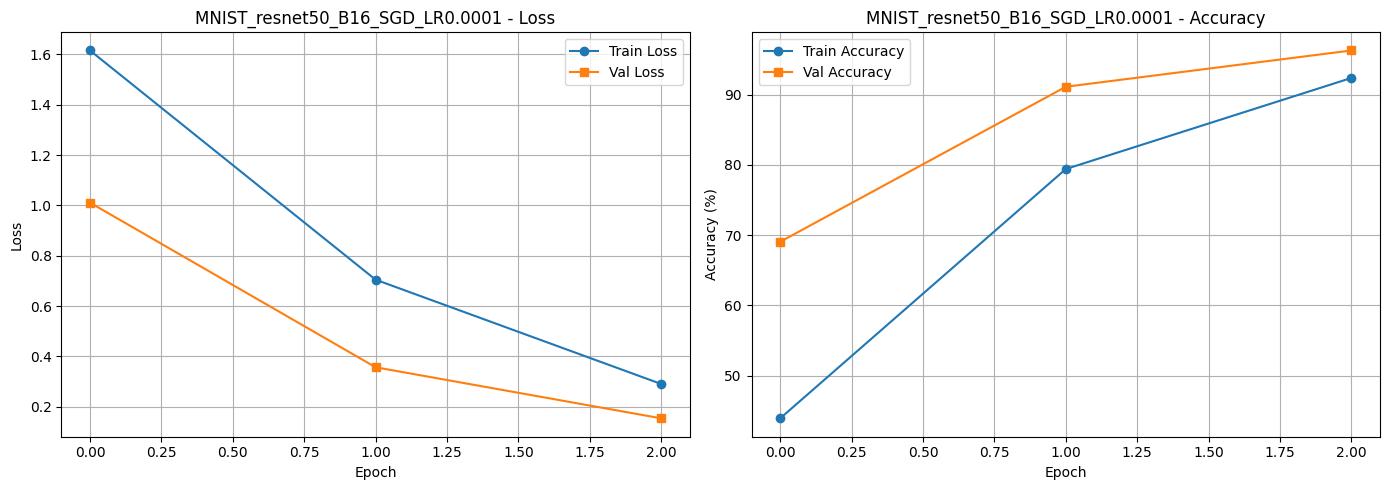


Dataset: MNIST | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.001 | pin_memory: False
Epoch [1/3] Train Loss: 0.1773 Train Acc: 94.77% Val Loss: 0.3951 Val Acc: 87.66%
Epoch [2/3] Train Loss: 0.0939 Train Acc: 97.23% Val Loss: 0.0627 Val Acc: 98.10%
Epoch [3/3] Train Loss: 0.0692 Train Acc: 98.00% Val Loss: 0.0655 Val Acc: 98.09%

Test Accuracy: 98.06%


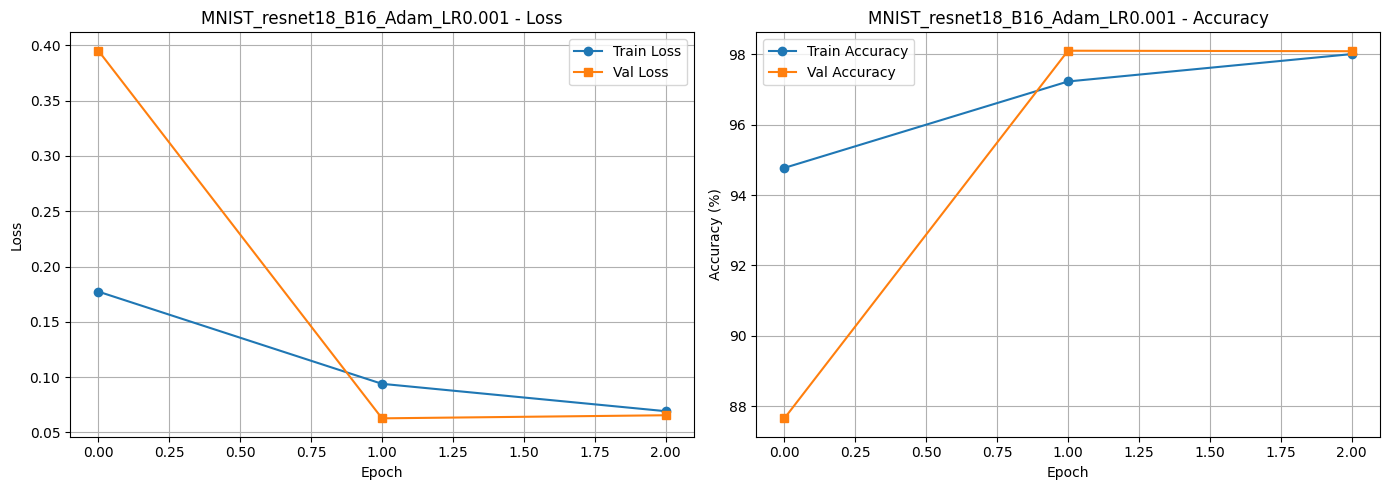


Dataset: MNIST | Model: RESNET50 | Batch: 16 | Optimizer: Adam | LR: 0.001 | pin_memory: False
Epoch [1/3] Train Loss: 0.2566 Train Acc: 92.21% Val Loss: 0.1452 Val Acc: 95.71%
Epoch [2/3] Train Loss: 0.1353 Train Acc: 96.02% Val Loss: 0.0836 Val Acc: 97.54%
Epoch [3/3] Train Loss: 0.0931 Train Acc: 97.25% Val Loss: 0.0594 Val Acc: 98.50%

Test Accuracy: 98.02%


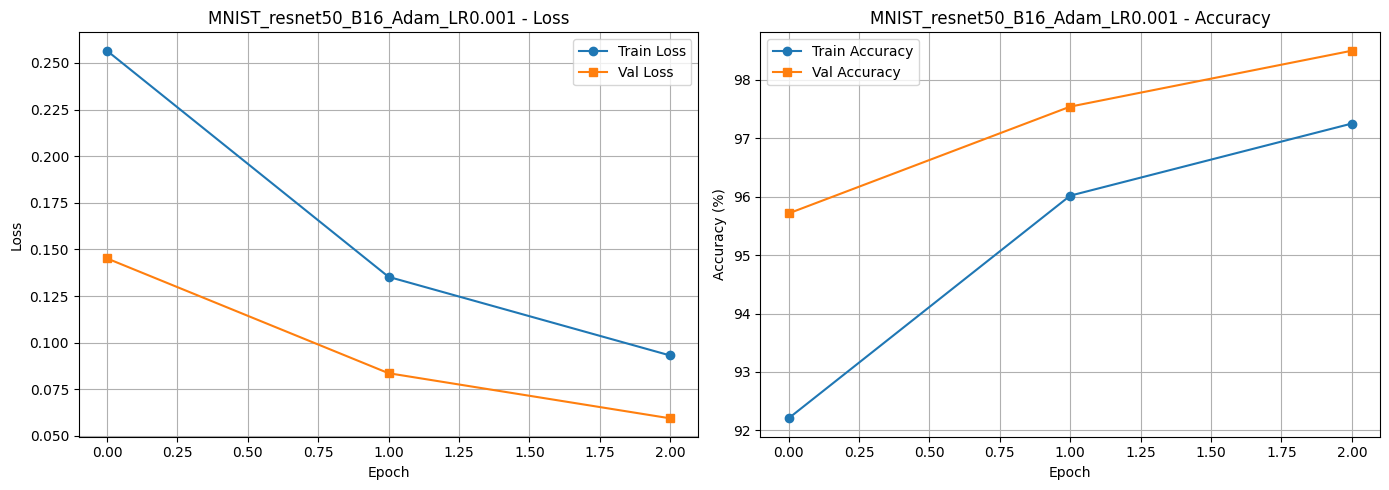


Dataset: MNIST | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.0001 | pin_memory: False
Epoch [1/3] Train Loss: 0.1261 Train Acc: 96.39% Val Loss: 0.0508 Val Acc: 98.43%
Epoch [2/3] Train Loss: 0.0554 Train Acc: 98.37% Val Loss: 0.0555 Val Acc: 98.36%
Epoch [3/3] Train Loss: 0.0471 Train Acc: 98.67% Val Loss: 0.0460 Val Acc: 98.70%

Test Accuracy: 98.88%


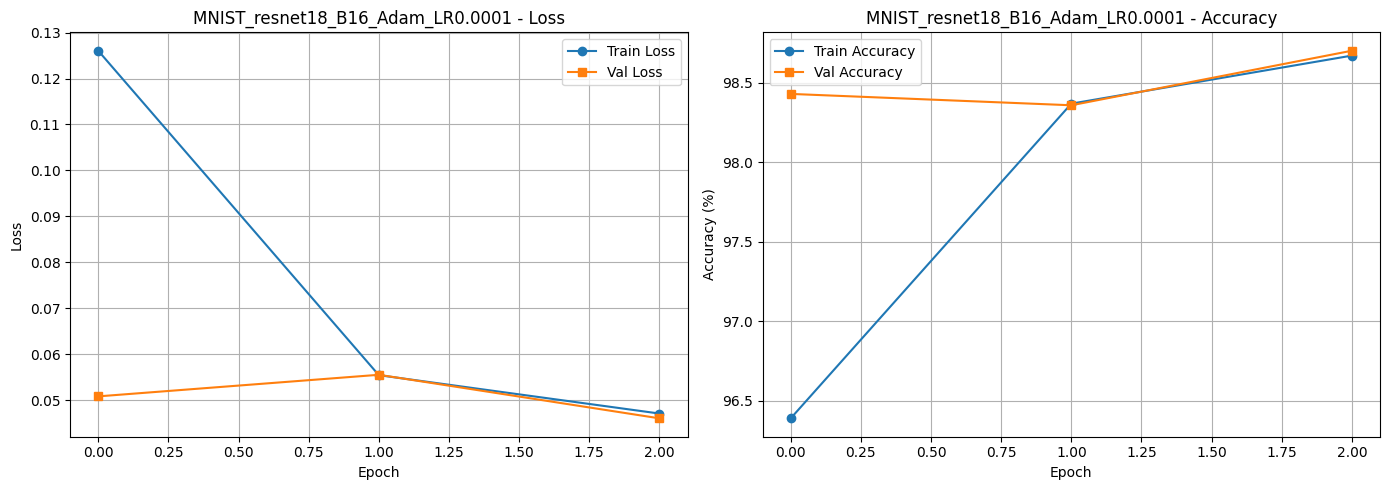


Dataset: MNIST | Model: RESNET50 | Batch: 16 | Optimizer: Adam | LR: 0.0001 | pin_memory: False
Epoch [1/3] Train Loss: 0.1955 Train Acc: 93.95% Val Loss: 0.1252 Val Acc: 96.06%
Epoch [2/3] Train Loss: 0.0695 Train Acc: 97.90% Val Loss: 0.0643 Val Acc: 98.10%
Epoch [3/3] Train Loss: 0.0609 Train Acc: 98.20% Val Loss: 0.0453 Val Acc: 98.70%

Test Accuracy: 98.52%


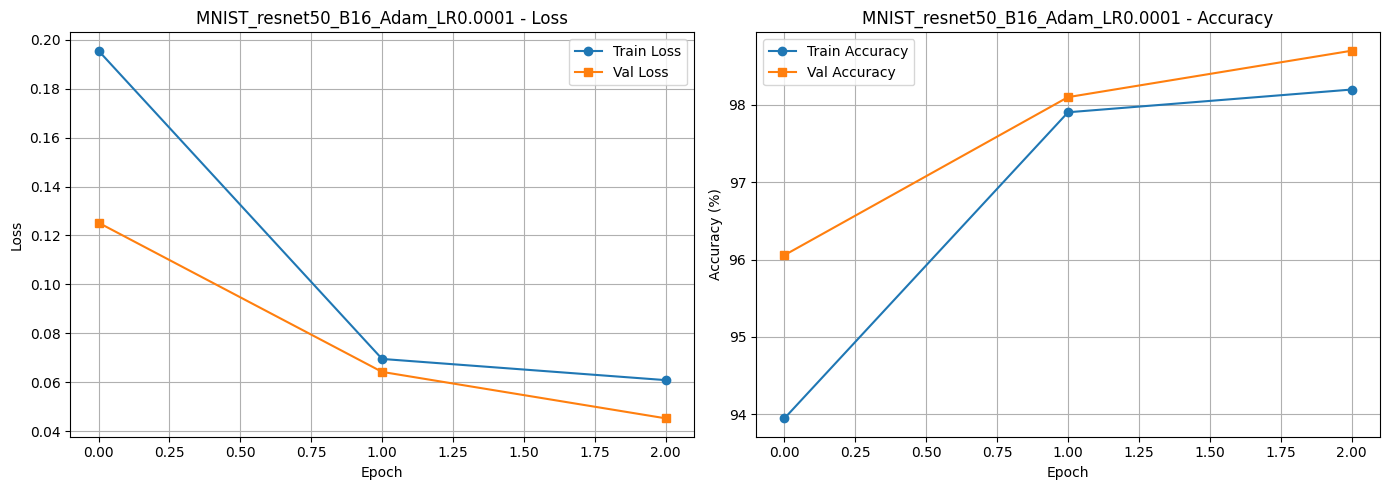


Dataset: MNIST | Model: RESNET18 | Batch: 32 | Optimizer: SGD | LR: 0.001 | pin_memory: False
Epoch [1/3] Train Loss: 0.4515 Train Acc: 87.37% Val Loss: 0.1238 Val Acc: 96.51%
Epoch [2/3] Train Loss: 0.0768 Train Acc: 97.87% Val Loss: 0.0766 Val Acc: 97.74%
Epoch [3/3] Train Loss: 0.0500 Train Acc: 98.59% Val Loss: 0.0461 Val Acc: 98.57%

Test Accuracy: 98.46%


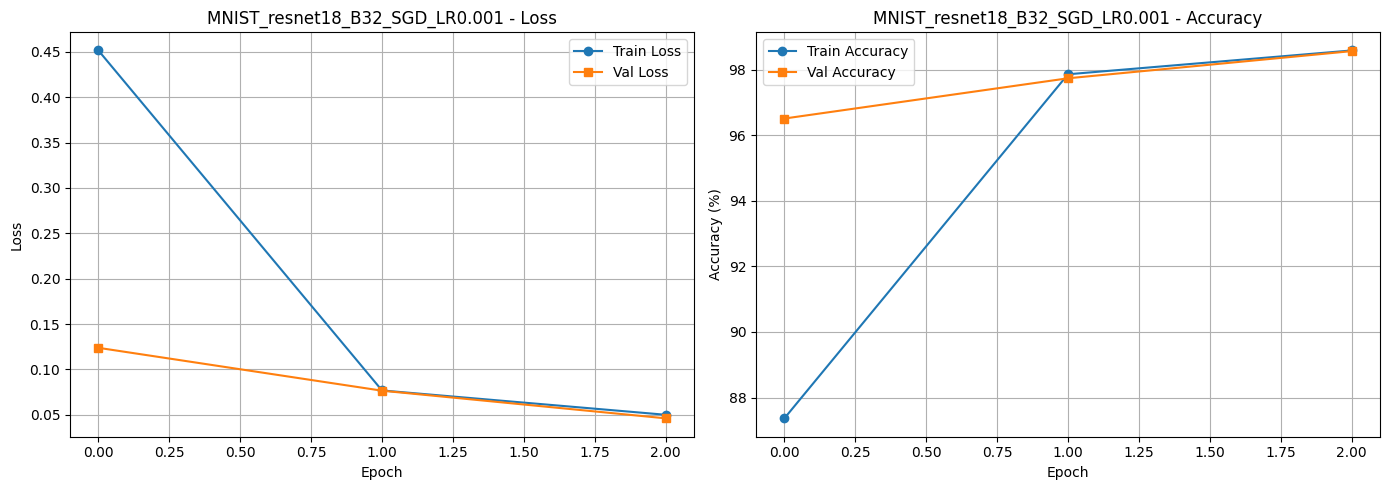


Dataset: MNIST | Model: RESNET50 | Batch: 32 | Optimizer: SGD | LR: 0.001 | pin_memory: False
Epoch [1/3] Train Loss: 0.6243 Train Acc: 79.29% Val Loss: 0.0991 Val Acc: 97.26%
Epoch [2/3] Train Loss: 0.0863 Train Acc: 97.42% Val Loss: 0.0600 Val Acc: 98.14%
Epoch [3/3] Train Loss: 0.0470 Train Acc: 98.59% Val Loss: 0.0433 Val Acc: 98.70%

Test Accuracy: 98.62%


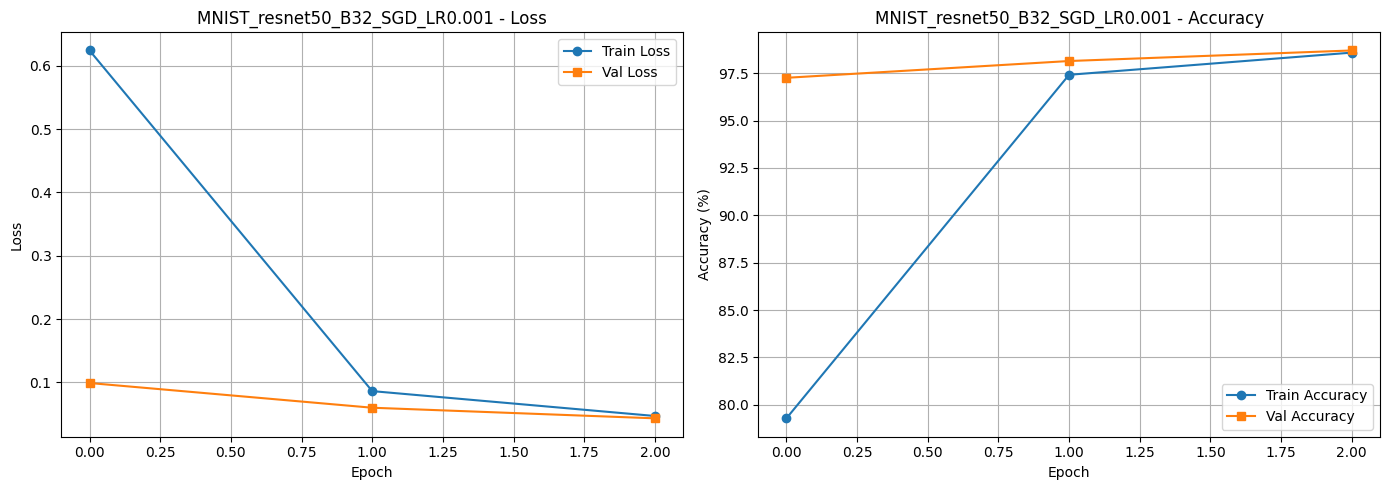


Dataset: MNIST | Model: RESNET18 | Batch: 32 | Optimizer: SGD | LR: 0.0001 | pin_memory: False
Epoch [1/3] Train Loss: 1.6895 Train Acc: 54.29% Val Loss: 1.1491 Val Acc: 76.93%
Epoch [2/3] Train Loss: 0.7710 Train Acc: 84.64% Val Loss: 0.5243 Val Acc: 90.03%
Epoch [3/3] Train Loss: 0.3595 Train Acc: 92.80% Val Loss: 0.4246 Val Acc: 89.50%

Test Accuracy: 89.44%


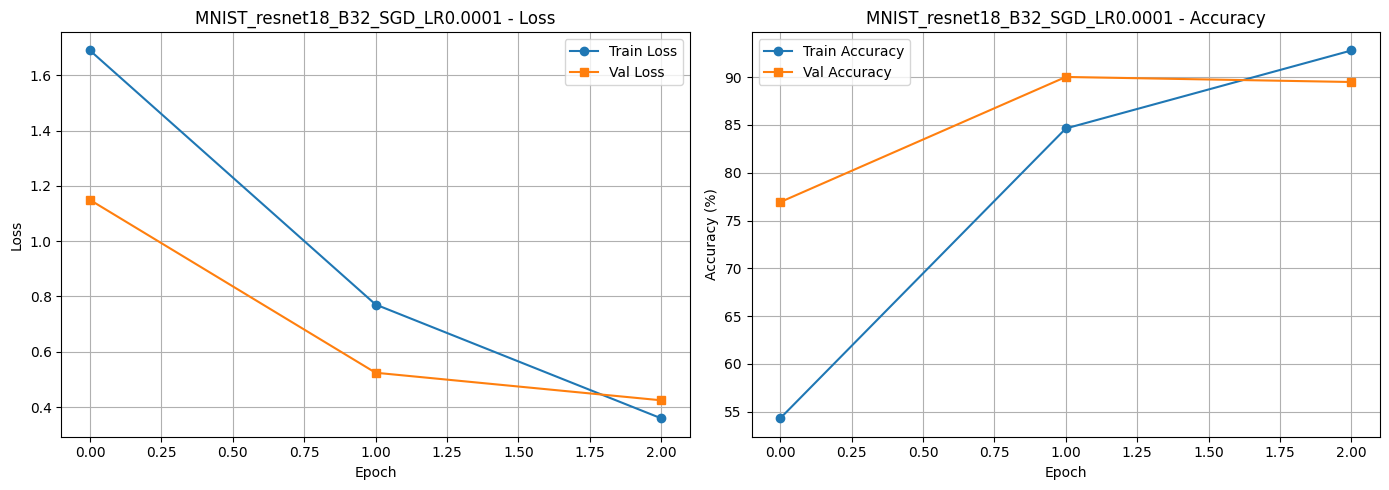


Dataset: MNIST | Model: RESNET50 | Batch: 32 | Optimizer: SGD | LR: 0.0001 | pin_memory: False
Epoch [1/3] Train Loss: 1.8561 Train Acc: 32.02% Val Loss: 1.5695 Val Acc: 49.59%
Epoch [2/3] Train Loss: 1.3628 Train Acc: 57.87% Val Loss: 1.0275 Val Acc: 73.60%
Epoch [3/3] Train Loss: 0.7606 Train Acc: 80.33% Val Loss: 0.4795 Val Acc: 89.04%

Test Accuracy: 88.04%


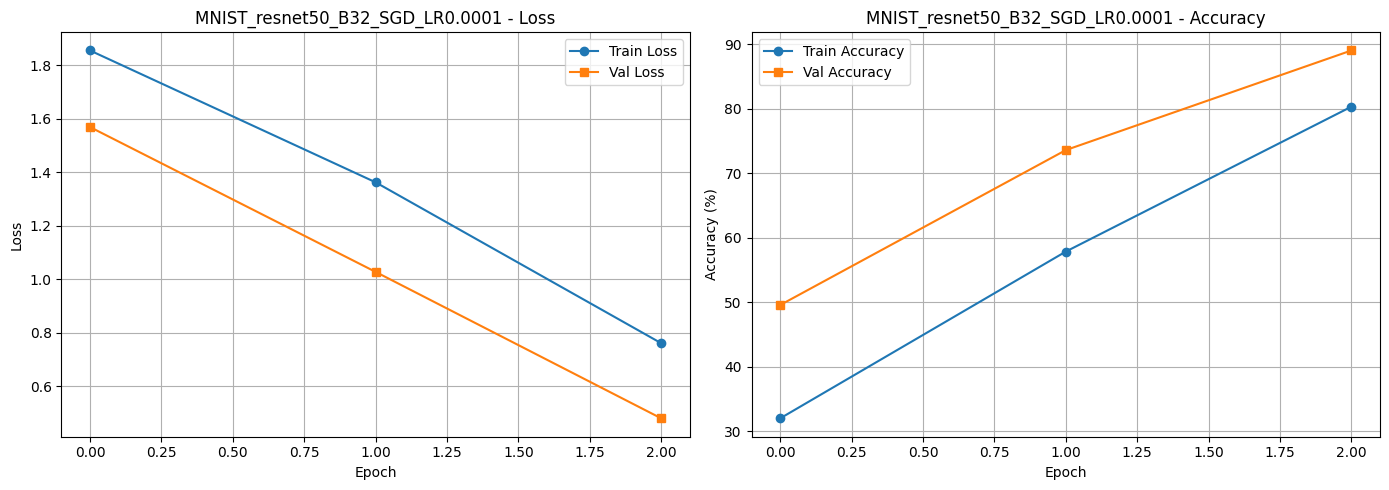


Dataset: MNIST | Model: RESNET18 | Batch: 32 | Optimizer: Adam | LR: 0.001 | pin_memory: False
Epoch [1/3] Train Loss: 0.1496 Train Acc: 95.60% Val Loss: 0.1752 Val Acc: 94.69%
Epoch [2/3] Train Loss: 0.0922 Train Acc: 97.29% Val Loss: 0.1063 Val Acc: 96.51%
Epoch [3/3] Train Loss: 0.0683 Train Acc: 98.00% Val Loss: 0.0855 Val Acc: 97.47%

Test Accuracy: 97.31%


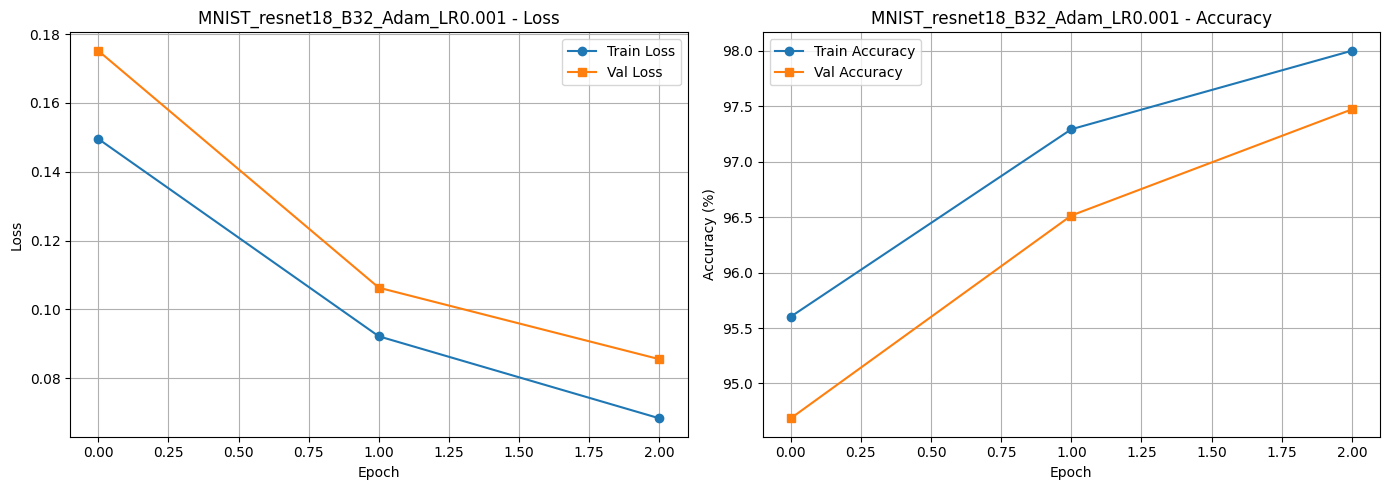


Dataset: MNIST | Model: RESNET50 | Batch: 32 | Optimizer: Adam | LR: 0.001 | pin_memory: False
Epoch [1/3] Train Loss: 0.2202 Train Acc: 93.40% Val Loss: 0.4223 Val Acc: 85.81%
Epoch [2/3] Train Loss: 0.1299 Train Acc: 96.22% Val Loss: 0.1849 Val Acc: 94.73%
Epoch [3/3] Train Loss: 0.0949 Train Acc: 97.18% Val Loss: 0.0683 Val Acc: 97.91%

Test Accuracy: 97.76%


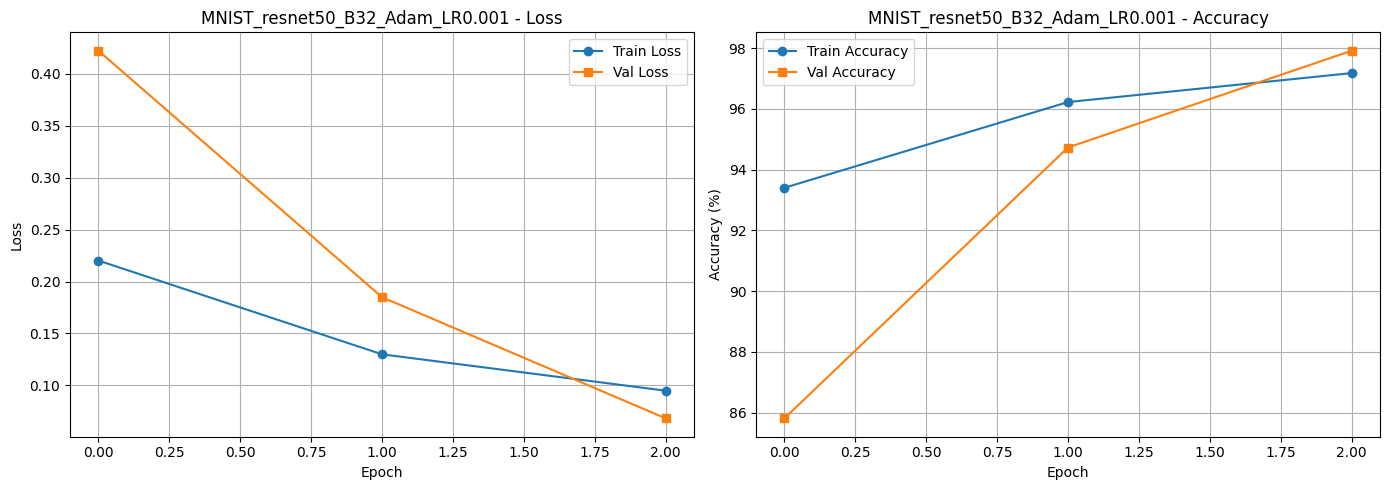


Dataset: MNIST | Model: RESNET18 | Batch: 32 | Optimizer: Adam | LR: 0.0001 | pin_memory: False
Epoch [1/3] Train Loss: 0.1380 Train Acc: 96.17% Val Loss: 0.0430 Val Acc: 98.70%
Epoch [2/3] Train Loss: 0.0441 Train Acc: 98.71% Val Loss: 0.0408 Val Acc: 98.93%
Epoch [3/3] Train Loss: 0.0390 Train Acc: 98.82% Val Loss: 0.0442 Val Acc: 98.76%

Test Accuracy: 98.61%


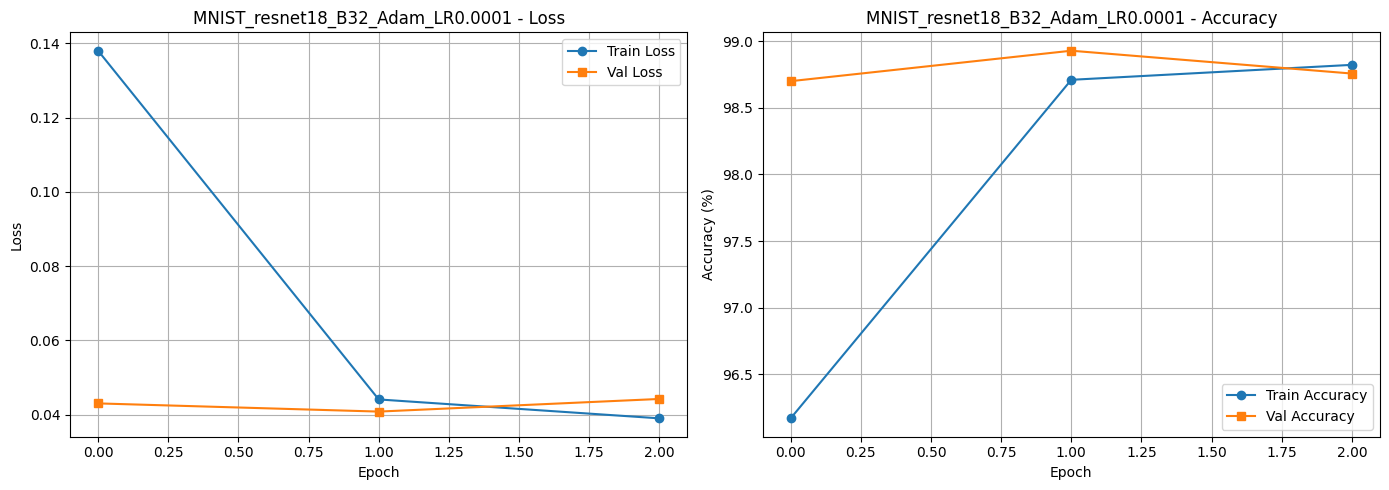


Dataset: MNIST | Model: RESNET50 | Batch: 32 | Optimizer: Adam | LR: 0.0001 | pin_memory: False
Epoch [1/3] Train Loss: 0.2094 Train Acc: 93.42% Val Loss: 0.0620 Val Acc: 98.09%
Epoch [2/3] Train Loss: 0.0553 Train Acc: 98.24% Val Loss: 0.0480 Val Acc: 98.64%
Epoch [3/3] Train Loss: 0.0463 Train Acc: 98.57% Val Loss: 0.0997 Val Acc: 96.93%

Test Accuracy: 96.73%


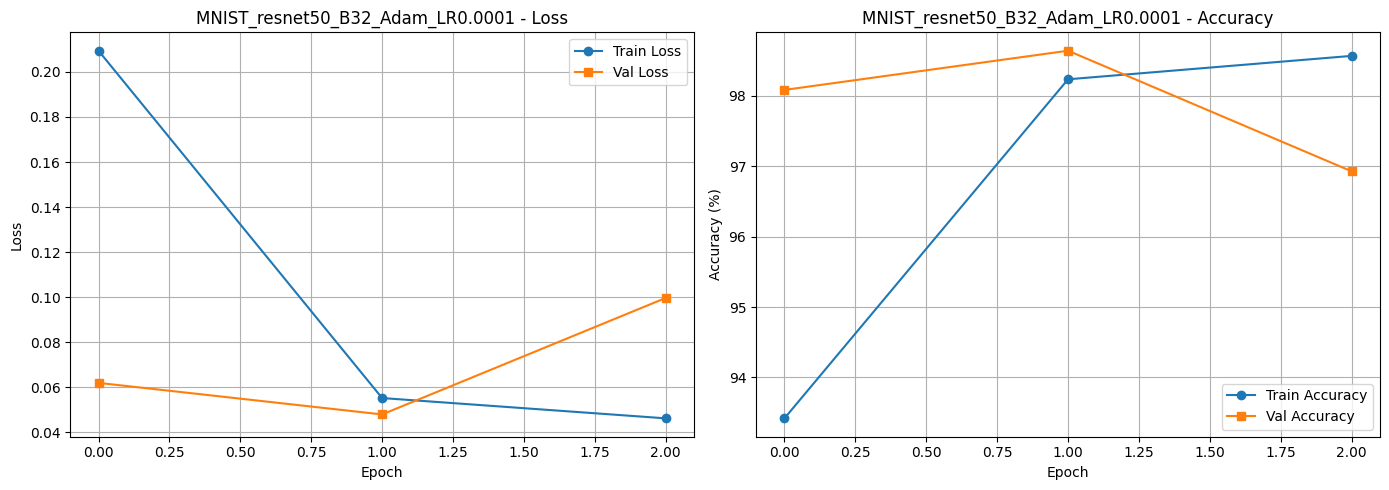

In [ ]:
# Run MNIST experiments with pin_memory=False and 10 epochs
mnist_results = run_q1a_experiments(
    'MNIST', mnist_train, mnist_val, mnist_test,
    epochs=3, pin_memory=False
)
q1a_results.extend(mnist_results)


Dataset: MNIST | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.3070 Train Acc: 91.03% Val Loss: 0.0639 Val Acc: 98.03%
Epoch [2/5] Train Loss: 0.0581 Train Acc: 98.32% Val Loss: 0.0354 Val Acc: 99.01%
Epoch [3/5] Train Loss: 0.0363 Train Acc: 98.95% Val Loss: 0.0427 Val Acc: 98.70%
Epoch [4/5] Train Loss: 0.0290 Train Acc: 99.12% Val Loss: 0.0240 Val Acc: 99.36%
Epoch [5/5] Train Loss: 0.0214 Train Acc: 99.39% Val Loss: 0.0236 Val Acc: 99.30%

Test Accuracy: 99.20%


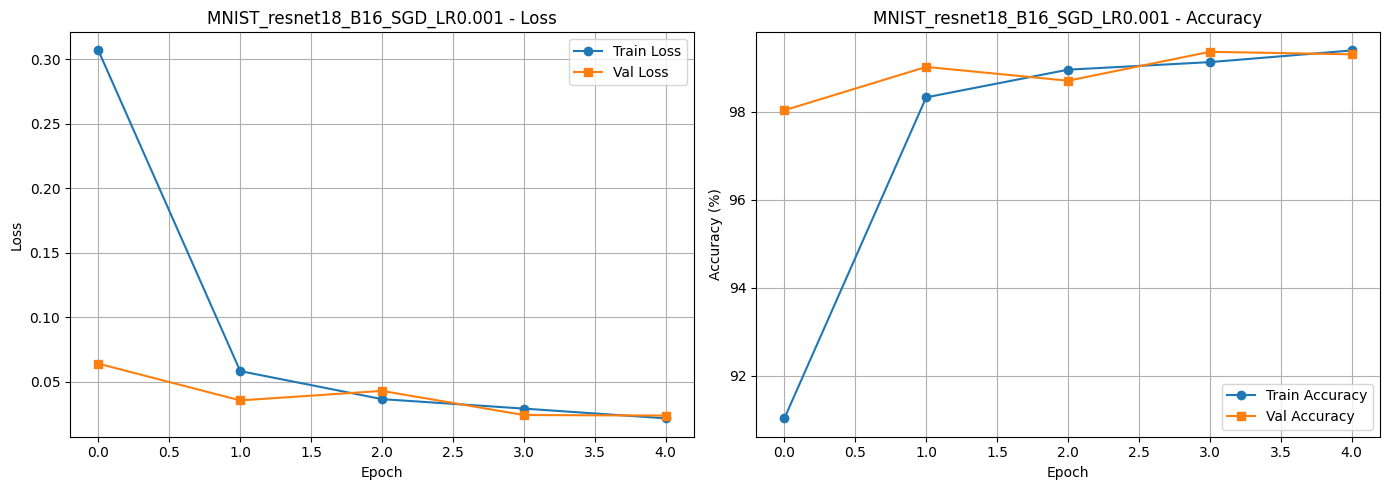


Dataset: MNIST | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.4242 Train Acc: 86.00% Val Loss: 0.0600 Val Acc: 98.17%
Epoch [2/5] Train Loss: 0.0729 Train Acc: 97.76% Val Loss: 0.0398 Val Acc: 98.80%
Epoch [3/5] Train Loss: 0.0434 Train Acc: 98.70% Val Loss: 0.0400 Val Acc: 98.91%
Epoch [4/5] Train Loss: 0.0298 Train Acc: 99.08% Val Loss: 0.0426 Val Acc: 98.94%
Epoch [5/5] Train Loss: 0.0182 Train Acc: 99.44% Val Loss: 0.0298 Val Acc: 99.04%

Test Accuracy: 99.11%


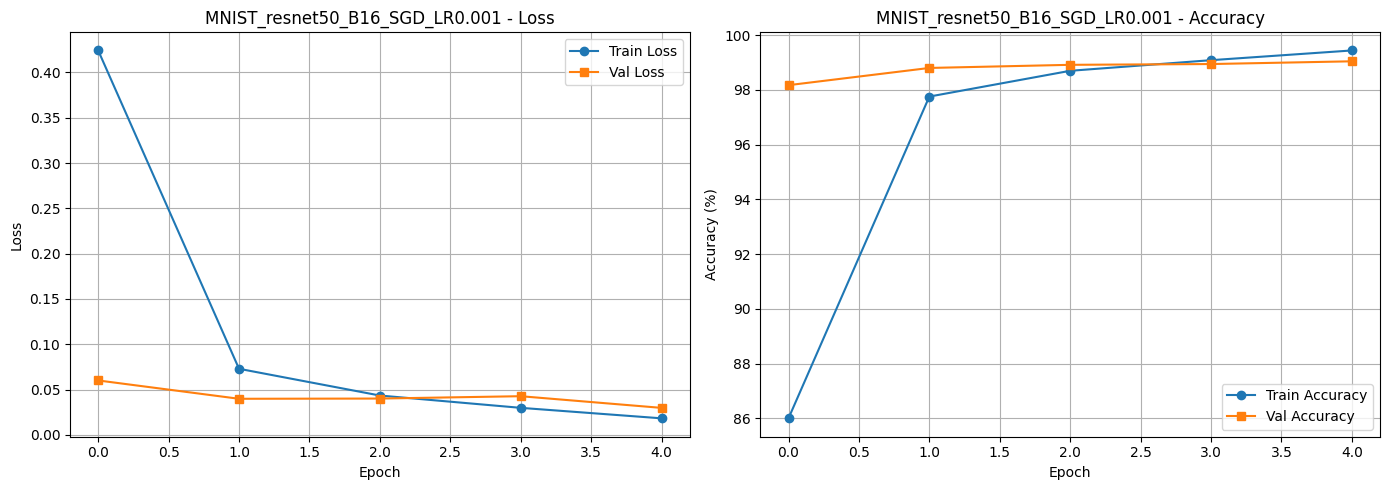


Dataset: MNIST | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 1.2836 Train Acc: 66.54% Val Loss: 0.4845 Val Acc: 91.20%
Epoch [2/5] Train Loss: 0.3475 Train Acc: 92.52% Val Loss: 0.1741 Val Acc: 95.94%
Epoch [3/5] Train Loss: 0.1873 Train Acc: 95.34% Val Loss: 0.1144 Val Acc: 97.00%
Epoch [4/5] Train Loss: 0.1363 Train Acc: 96.49% Val Loss: 0.1035 Val Acc: 97.17%
Epoch [5/5] Train Loss: 0.1086 Train Acc: 97.16% Val Loss: 0.0772 Val Acc: 97.99%

Test Accuracy: 97.70%


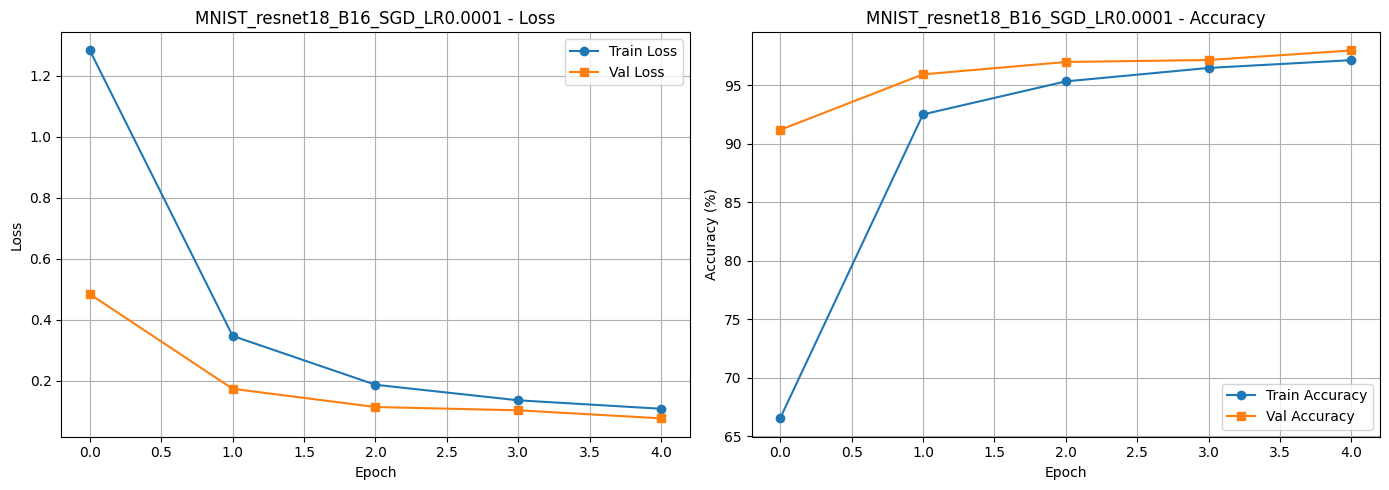


Dataset: MNIST | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 1.6656 Train Acc: 41.74% Val Loss: 1.0352 Val Acc: 72.69%
Epoch [2/5] Train Loss: 0.6315 Train Acc: 83.20% Val Loss: 0.2529 Val Acc: 94.21%
Epoch [3/5] Train Loss: 0.2597 Train Acc: 93.11% Val Loss: 0.1616 Val Acc: 95.63%
Epoch [4/5] Train Loss: 0.1705 Train Acc: 95.29% Val Loss: 0.1135 Val Acc: 96.69%
Epoch [5/5] Train Loss: 0.1315 Train Acc: 96.25% Val Loss: 0.0896 Val Acc: 97.56%

Test Accuracy: 97.27%


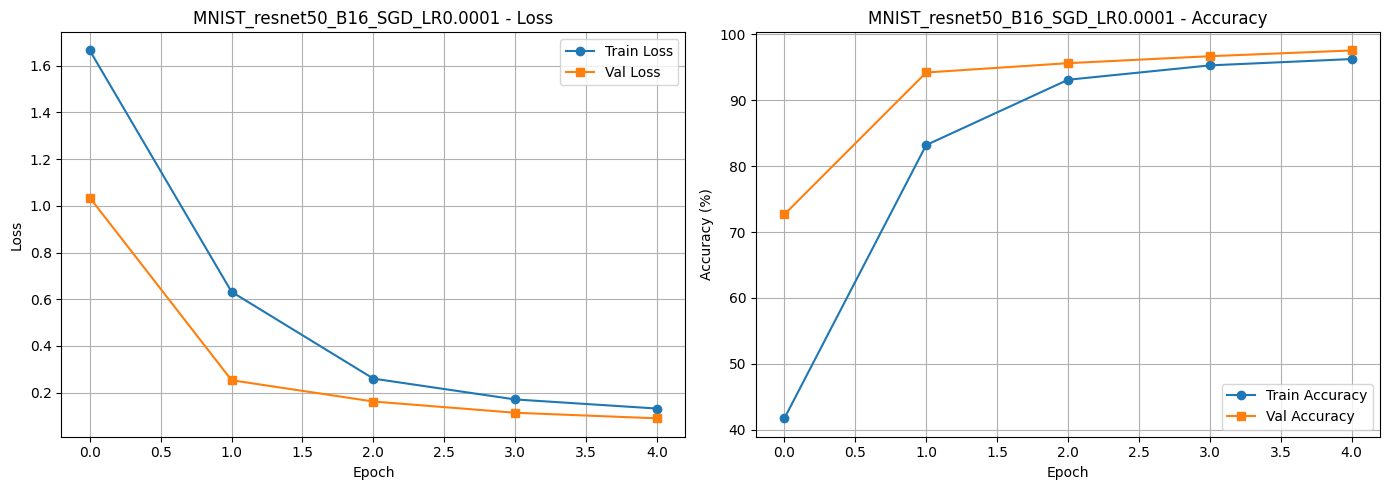


Dataset: MNIST | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.1799 Train Acc: 94.57% Val Loss: 0.1189 Val Acc: 96.64%
Epoch [2/5] Train Loss: 0.0939 Train Acc: 97.24% Val Loss: 0.0533 Val Acc: 98.69%
Epoch [3/5] Train Loss: 0.0683 Train Acc: 98.08% Val Loss: 0.0363 Val Acc: 98.99%
Epoch [4/5] Train Loss: 0.0578 Train Acc: 98.34% Val Loss: 0.0463 Val Acc: 98.70%
Epoch [5/5] Train Loss: 0.0532 Train Acc: 98.48% Val Loss: 0.0508 Val Acc: 98.43%

Test Accuracy: 98.19%


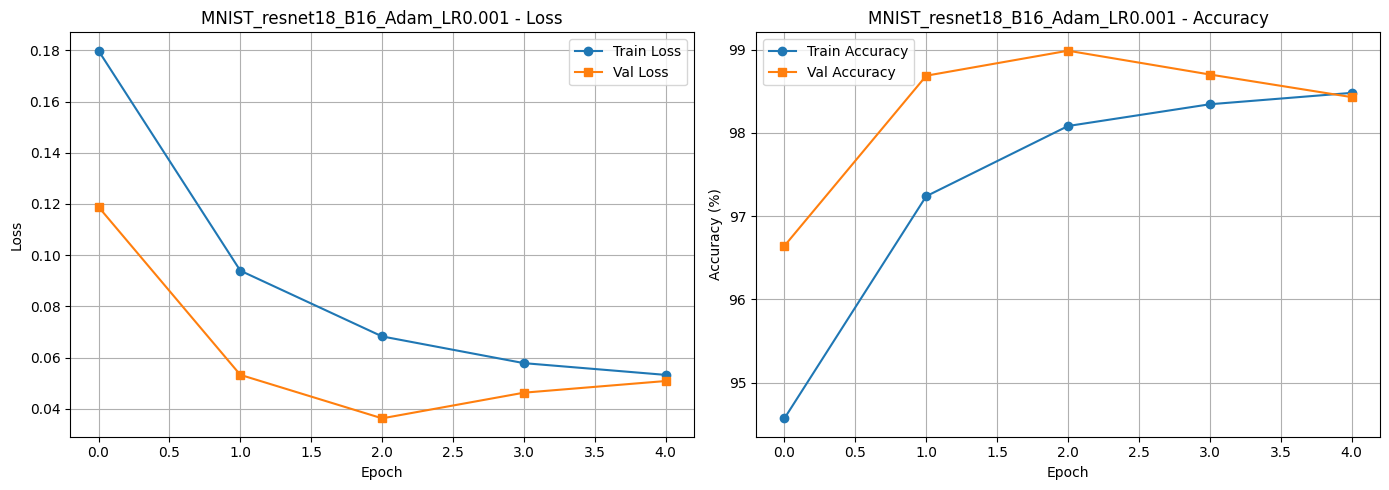


Dataset: MNIST | Model: RESNET50 | Batch: 16 | Optimizer: Adam | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.2555 Train Acc: 92.31% Val Loss: 0.1858 Val Acc: 94.14%
Epoch [2/5] Train Loss: 0.1370 Train Acc: 95.89% Val Loss: 0.0740 Val Acc: 97.66%
Epoch [3/5] Train Loss: 0.0932 Train Acc: 97.30% Val Loss: 0.1262 Val Acc: 96.07%
Epoch [4/5] Train Loss: 0.0787 Train Acc: 97.69% Val Loss: 0.0620 Val Acc: 98.40%
Epoch [5/5] Train Loss: 0.0685 Train Acc: 98.00% Val Loss: 0.0530 Val Acc: 98.53%

Test Accuracy: 98.46%


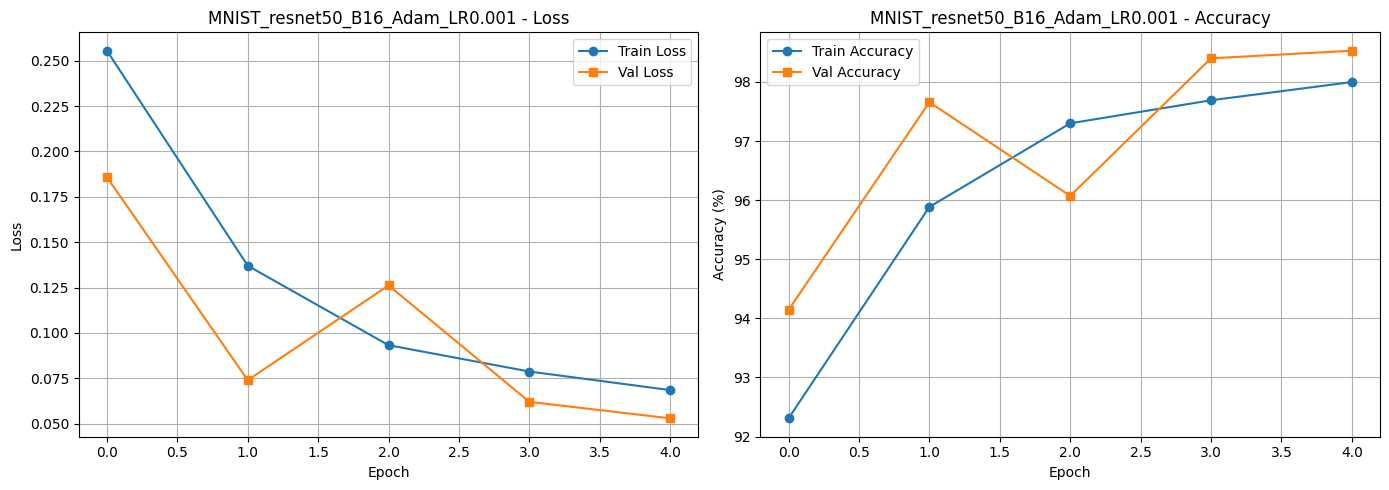


Dataset: MNIST | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 0.1335 Train Acc: 96.29% Val Loss: 0.0484 Val Acc: 98.59%
Epoch [2/5] Train Loss: 0.0554 Train Acc: 98.40% Val Loss: 0.0346 Val Acc: 99.04%
Epoch [3/5] Train Loss: 0.0470 Train Acc: 98.66% Val Loss: 0.0267 Val Acc: 99.27%
Epoch [4/5] Train Loss: 0.0412 Train Acc: 98.86% Val Loss: 0.0589 Val Acc: 98.10%
Epoch [5/5] Train Loss: 0.0382 Train Acc: 98.99% Val Loss: 0.0234 Val Acc: 99.33%

Test Accuracy: 99.15%


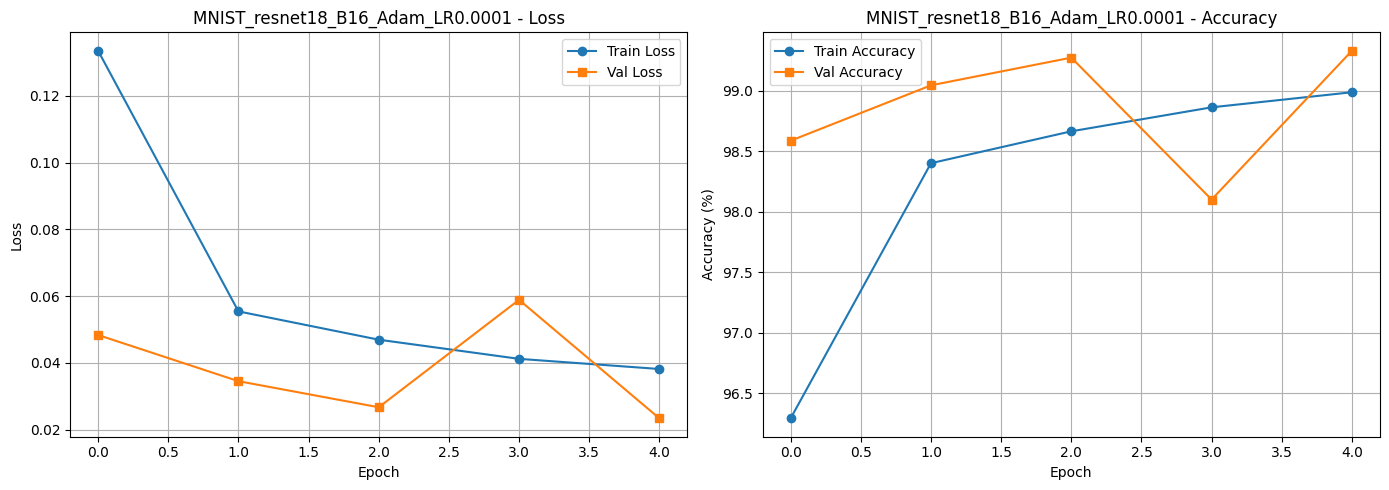


Dataset: MNIST | Model: RESNET50 | Batch: 16 | Optimizer: Adam | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 0.1968 Train Acc: 93.90% Val Loss: 0.0899 Val Acc: 97.26%
Epoch [2/5] Train Loss: 0.0688 Train Acc: 97.91% Val Loss: 0.0599 Val Acc: 98.34%
Epoch [3/5] Train Loss: 0.0627 Train Acc: 98.17% Val Loss: 0.0355 Val Acc: 99.03%
Epoch [4/5] Train Loss: 0.0568 Train Acc: 98.31% Val Loss: 0.0436 Val Acc: 98.59%
Epoch [5/5] Train Loss: 0.0538 Train Acc: 98.45% Val Loss: 0.0594 Val Acc: 98.34%

Test Accuracy: 98.24%


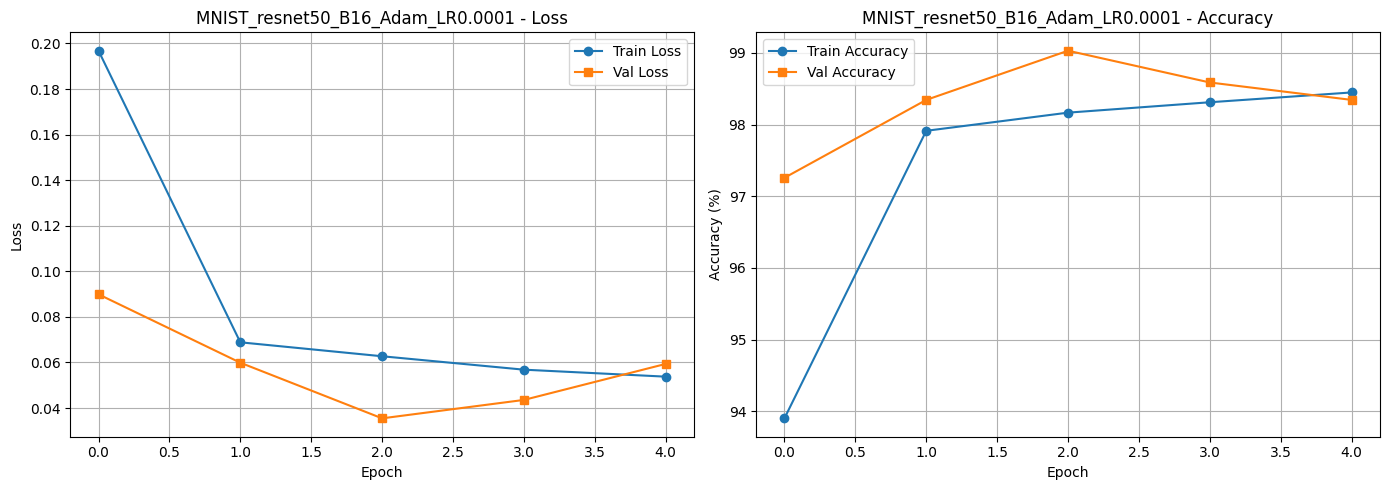


Dataset: MNIST | Model: RESNET18 | Batch: 32 | Optimizer: SGD | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.4504 Train Acc: 87.61% Val Loss: 0.1297 Val Acc: 96.24%
Epoch [2/5] Train Loss: 0.0747 Train Acc: 97.88% Val Loss: 0.0477 Val Acc: 98.73%
Epoch [3/5] Train Loss: 0.0483 Train Acc: 98.61% Val Loss: 0.0423 Val Acc: 98.90%
Epoch [4/5] Train Loss: 0.0346 Train Acc: 99.06% Val Loss: 0.0315 Val Acc: 99.06%
Epoch [5/5] Train Loss: 0.0265 Train Acc: 99.29% Val Loss: 0.0281 Val Acc: 99.20%

Test Accuracy: 98.95%


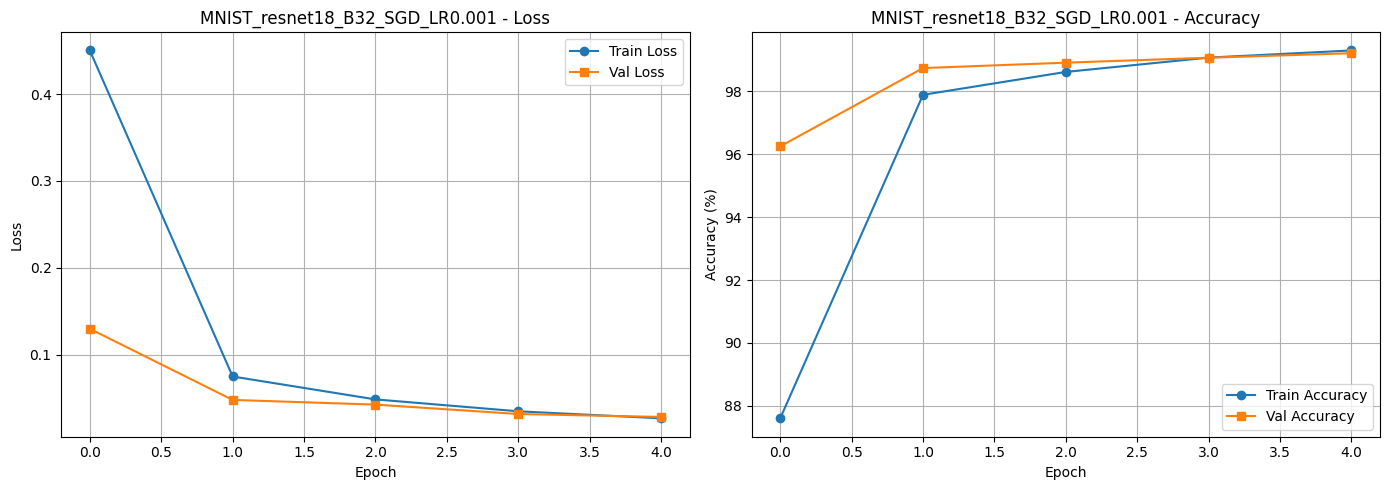


Dataset: MNIST | Model: RESNET50 | Batch: 32 | Optimizer: SGD | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.6018 Train Acc: 79.93% Val Loss: 0.0969 Val Acc: 97.29%
Epoch [2/5] Train Loss: 0.0841 Train Acc: 97.50% Val Loss: 0.0584 Val Acc: 98.34%
Epoch [3/5] Train Loss: 0.0474 Train Acc: 98.60% Val Loss: 0.0551 Val Acc: 98.50%
Epoch [4/5] Train Loss: 0.0304 Train Acc: 99.14% Val Loss: 0.0389 Val Acc: 98.89%
Epoch [5/5] Train Loss: 0.0194 Train Acc: 99.48% Val Loss: 0.0366 Val Acc: 98.90%

Test Accuracy: 98.67%


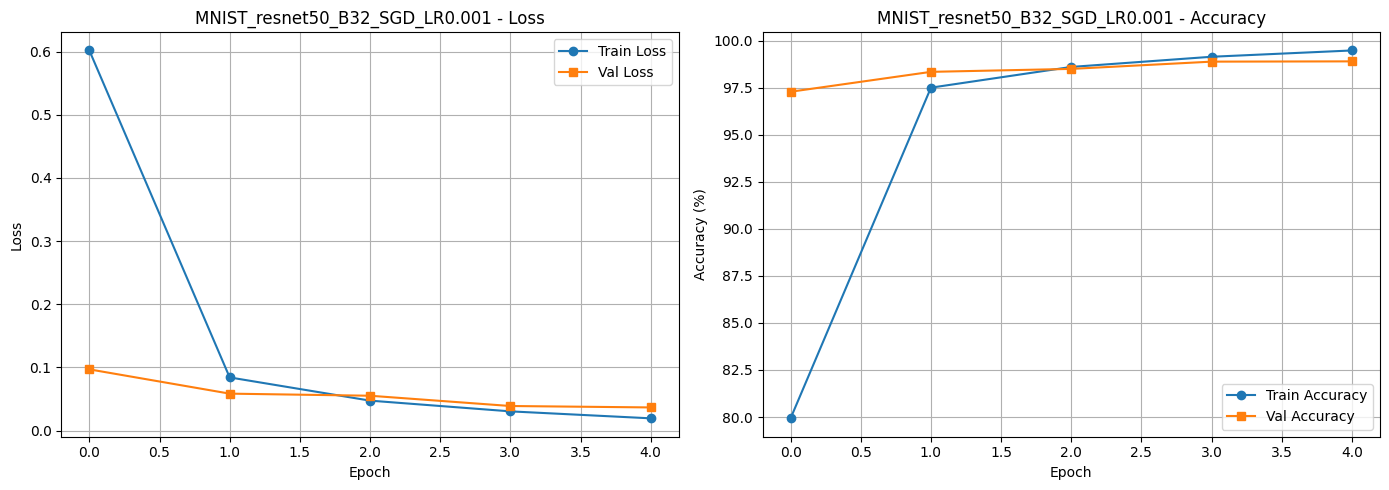


Dataset: MNIST | Model: RESNET18 | Batch: 32 | Optimizer: SGD | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 1.6913 Train Acc: 53.02% Val Loss: 1.1942 Val Acc: 76.39%
Epoch [2/5] Train Loss: 0.7767 Train Acc: 84.57% Val Loss: 0.4949 Val Acc: 90.40%
Epoch [3/5] Train Loss: 0.3653 Train Acc: 92.96% Val Loss: 0.2395 Val Acc: 95.67%
Epoch [4/5] Train Loss: 0.2274 Train Acc: 95.10% Val Loss: 0.1711 Val Acc: 96.40%
Epoch [5/5] Train Loss: 0.1726 Train Acc: 95.92% Val Loss: 0.1324 Val Acc: 97.13%

Test Accuracy: 96.59%


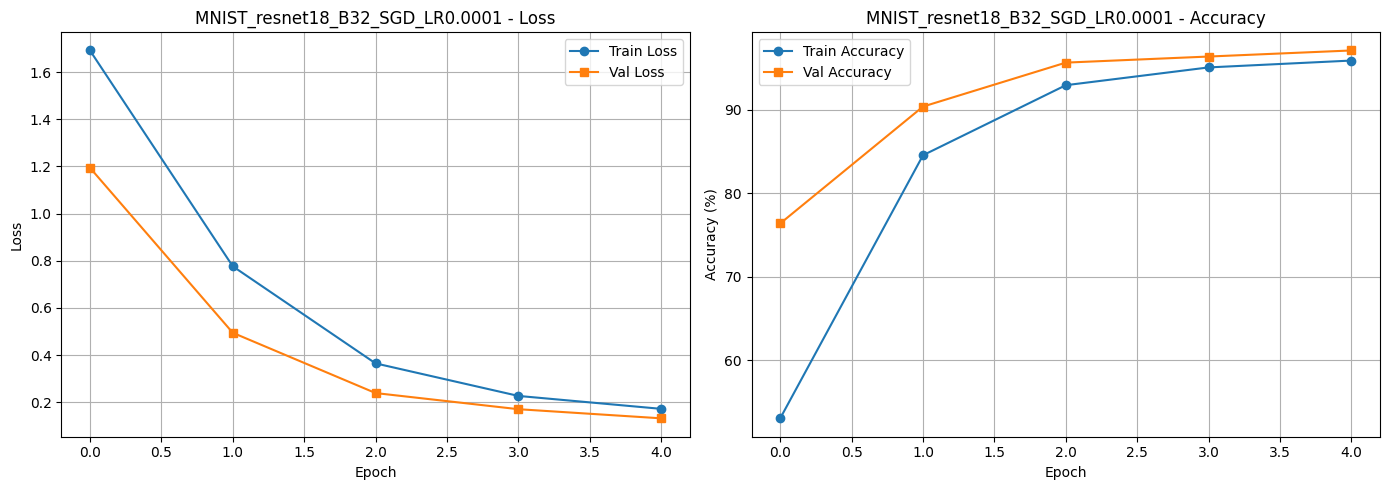


Dataset: MNIST | Model: RESNET50 | Batch: 32 | Optimizer: SGD | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 1.8235 Train Acc: 35.27% Val Loss: 1.5195 Val Acc: 53.61%
Epoch [2/5] Train Loss: 1.2300 Train Acc: 63.65% Val Loss: 0.9313 Val Acc: 72.80%
Epoch [3/5] Train Loss: 0.7353 Train Acc: 79.11% Val Loss: 0.5071 Val Acc: 86.69%
Epoch [4/5] Train Loss: 0.4311 Train Acc: 88.44% Val Loss: 0.2971 Val Acc: 92.39%
Epoch [5/5] Train Loss: 0.2728 Train Acc: 92.83% Val Loss: 0.2044 Val Acc: 94.84%

Test Accuracy: 94.21%


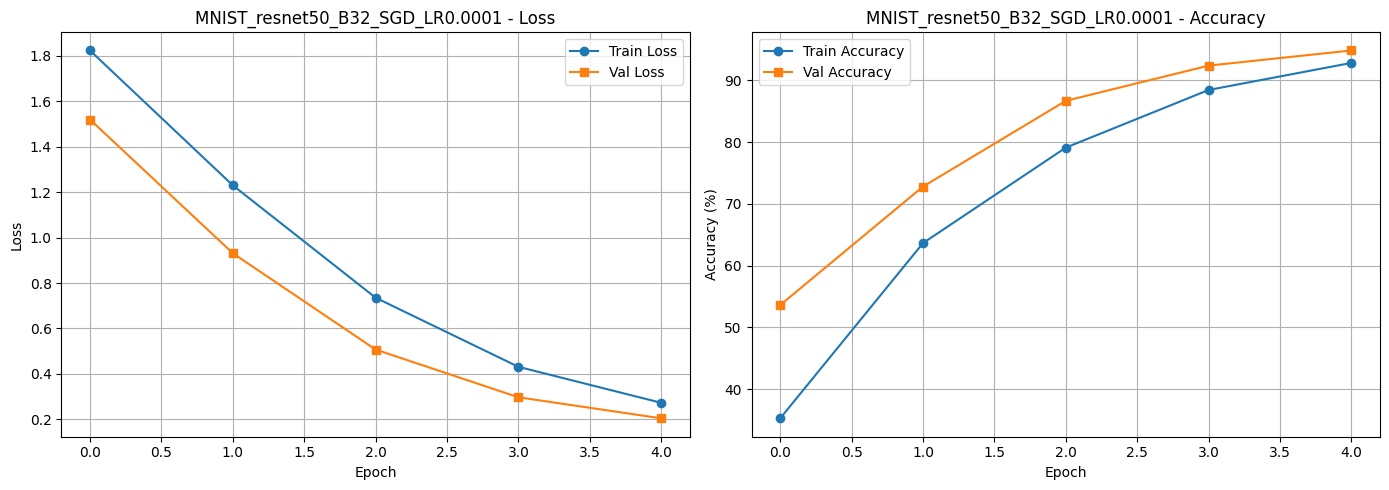


Dataset: MNIST | Model: RESNET18 | Batch: 32 | Optimizer: Adam | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.1532 Train Acc: 95.40% Val Loss: 2.2926 Val Acc: 40.97%
Epoch [2/5] Train Loss: 0.0902 Train Acc: 97.36% Val Loss: 0.1381 Val Acc: 95.87%
Epoch [3/5] Train Loss: 0.0689 Train Acc: 98.02% Val Loss: 0.0637 Val Acc: 98.00%
Epoch [4/5] Train Loss: 0.0576 Train Acc: 98.31% Val Loss: 0.0627 Val Acc: 98.29%
Epoch [5/5] Train Loss: 0.0509 Train Acc: 98.60% Val Loss: 0.0338 Val Acc: 99.00%

Test Accuracy: 98.96%


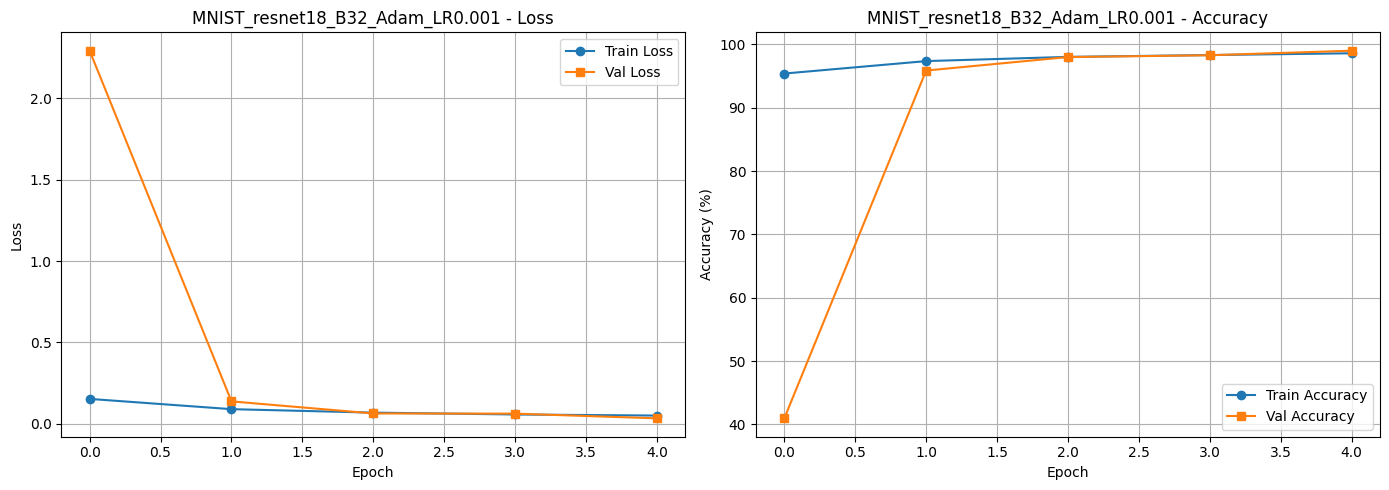


Dataset: MNIST | Model: RESNET50 | Batch: 32 | Optimizer: Adam | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.2116 Train Acc: 93.51% Val Loss: 0.3060 Val Acc: 90.54%
Epoch [2/5] Train Loss: 0.1284 Train Acc: 96.21% Val Loss: 0.1544 Val Acc: 95.41%
Epoch [3/5] Train Loss: 0.0975 Train Acc: 97.12% Val Loss: 0.0656 Val Acc: 97.99%
Epoch [4/5] Train Loss: 0.0754 Train Acc: 97.69% Val Loss: 0.0931 Val Acc: 97.50%
Epoch [5/5] Train Loss: 0.0640 Train Acc: 98.09% Val Loss: 0.0452 Val Acc: 98.87%

Test Accuracy: 98.75%


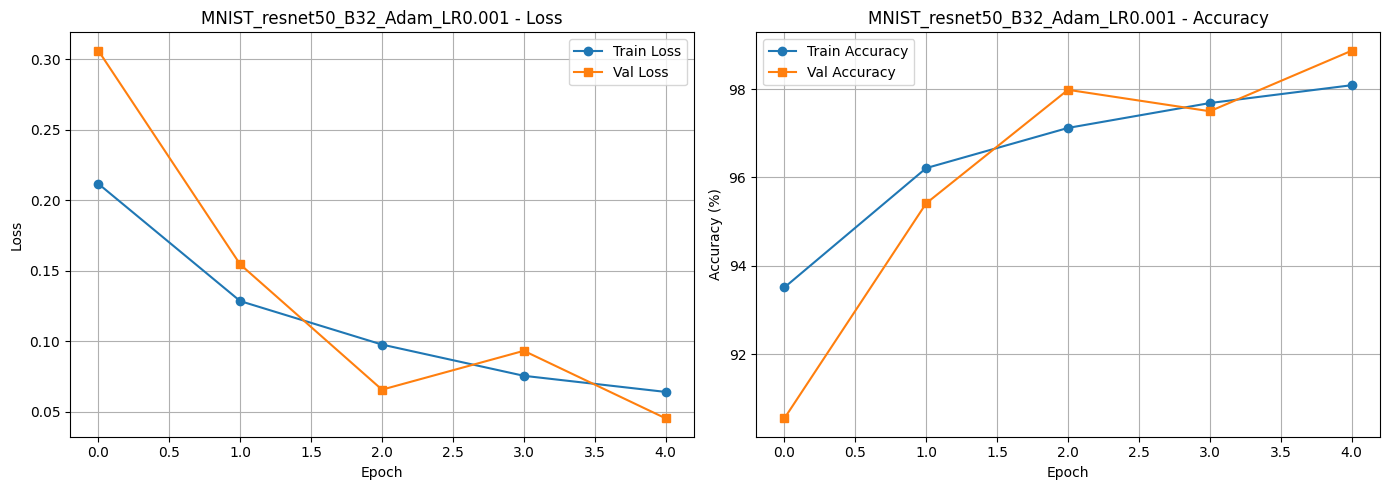


Dataset: MNIST | Model: RESNET18 | Batch: 32 | Optimizer: Adam | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 0.1358 Train Acc: 96.31% Val Loss: 0.0610 Val Acc: 98.04%
Epoch [2/5] Train Loss: 0.0465 Train Acc: 98.67% Val Loss: 0.0335 Val Acc: 99.10%
Epoch [3/5] Train Loss: 0.0381 Train Acc: 98.88% Val Loss: 0.0502 Val Acc: 98.44%
Epoch [4/5] Train Loss: 0.0346 Train Acc: 99.01% Val Loss: 0.0509 Val Acc: 98.50%
Epoch [5/5] Train Loss: 0.0327 Train Acc: 99.06% Val Loss: 0.0385 Val Acc: 98.87%

Test Accuracy: 98.71%


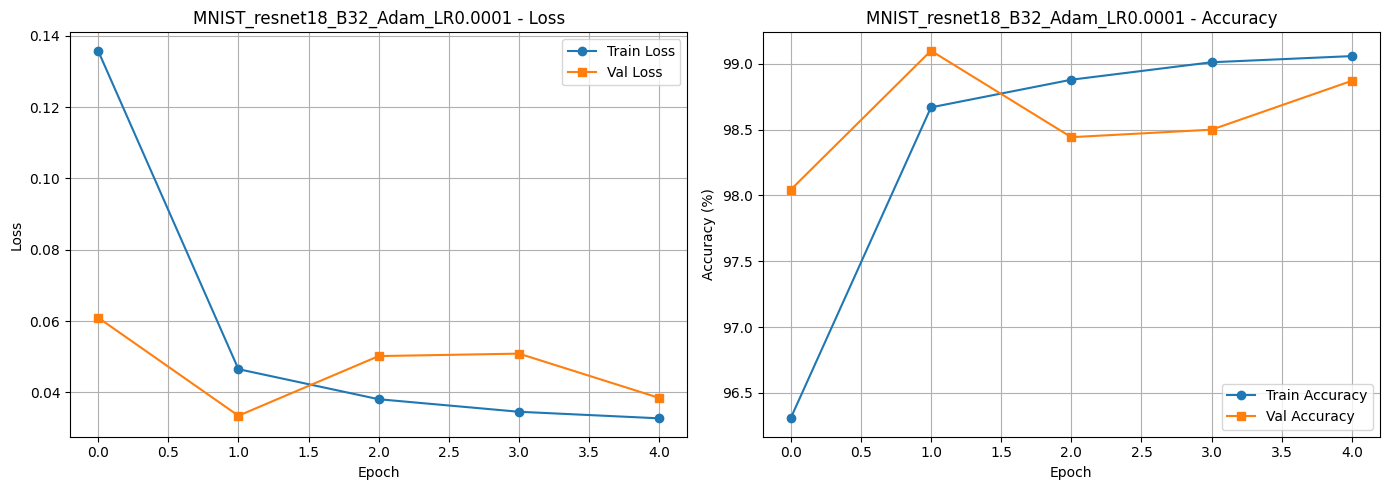


Dataset: MNIST | Model: RESNET50 | Batch: 32 | Optimizer: Adam | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 0.2246 Train Acc: 92.88% Val Loss: 0.0521 Val Acc: 98.50%
Epoch [2/5] Train Loss: 0.0573 Train Acc: 98.28% Val Loss: 0.0663 Val Acc: 98.10%
Epoch [3/5] Train Loss: 0.0507 Train Acc: 98.46% Val Loss: 0.0714 Val Acc: 97.70%
Epoch [4/5] Train Loss: 0.0434 Train Acc: 98.69% Val Loss: 0.0324 Val Acc: 99.04%
Epoch [5/5] Train Loss: 0.0425 Train Acc: 98.71% Val Loss: 0.0641 Val Acc: 98.03%

Test Accuracy: 98.02%


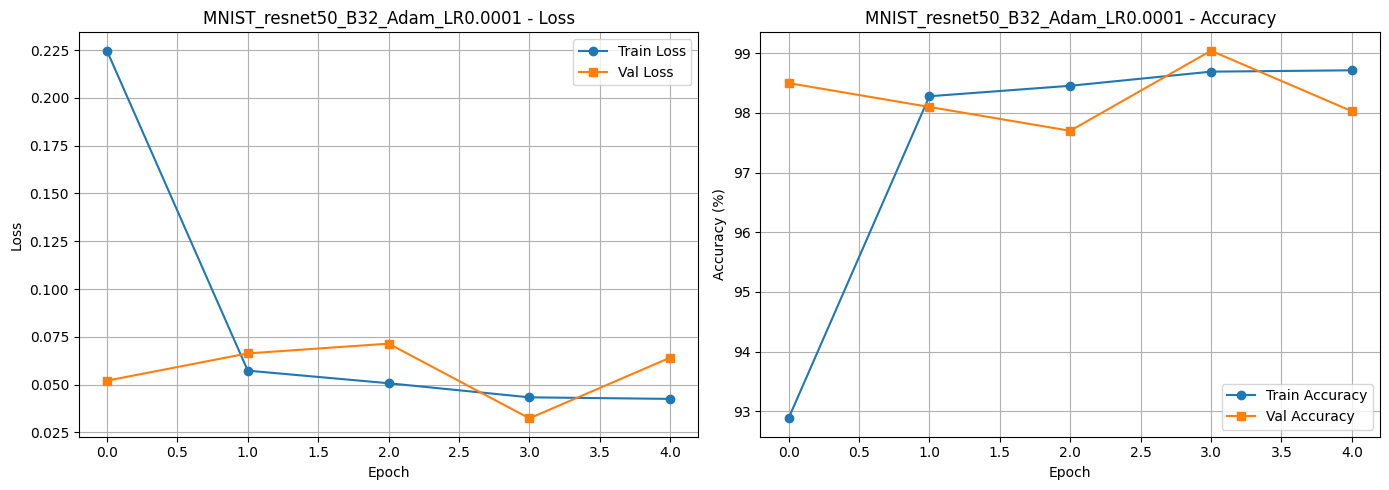

In [ ]:
# Run MNIST experiments with pin_memory=True and 5 epochs
mnist_results_pm = run_q1a_experiments(
    'MNIST', mnist_train, mnist_val, mnist_test,
    epochs=5, pin_memory=True
)
q1a_results.extend(mnist_results_pm)

### Q1(a) - FashionMNIST Experiments


Dataset: FashionMNIST | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.001 | pin_memory: False
Epoch [1/10] Train Loss: 0.5911 Train Acc: 78.69% Val Loss: 1.1887 Val Acc: 65.57%
Epoch [2/10] Train Loss: 0.3280 Train Acc: 88.16% Val Loss: 0.3097 Val Acc: 88.57%
Epoch [3/10] Train Loss: 0.2628 Train Acc: 90.55% Val Loss: 0.2416 Val Acc: 91.40%
Epoch [4/10] Train Loss: 0.2229 Train Acc: 91.99% Val Loss: 0.2722 Val Acc: 89.96%
Epoch [5/10] Train Loss: 0.1943 Train Acc: 92.97% Val Loss: 0.2167 Val Acc: 92.07%
Epoch [6/10] Train Loss: 0.1677 Train Acc: 94.08% Val Loss: 0.2089 Val Acc: 92.24%
Epoch [7/10] Train Loss: 0.1431 Train Acc: 94.91% Val Loss: 0.2624 Val Acc: 90.89%
Epoch [8/10] Train Loss: 0.1189 Train Acc: 95.78% Val Loss: 0.2349 Val Acc: 92.19%
Epoch [9/10] Train Loss: 0.0997 Train Acc: 96.55% Val Loss: 0.2605 Val Acc: 91.49%
Epoch [10/10] Train Loss: 0.0807 Train Acc: 97.20% Val Loss: 0.2516 Val Acc: 91.91%

Test Accuracy: 92.06%


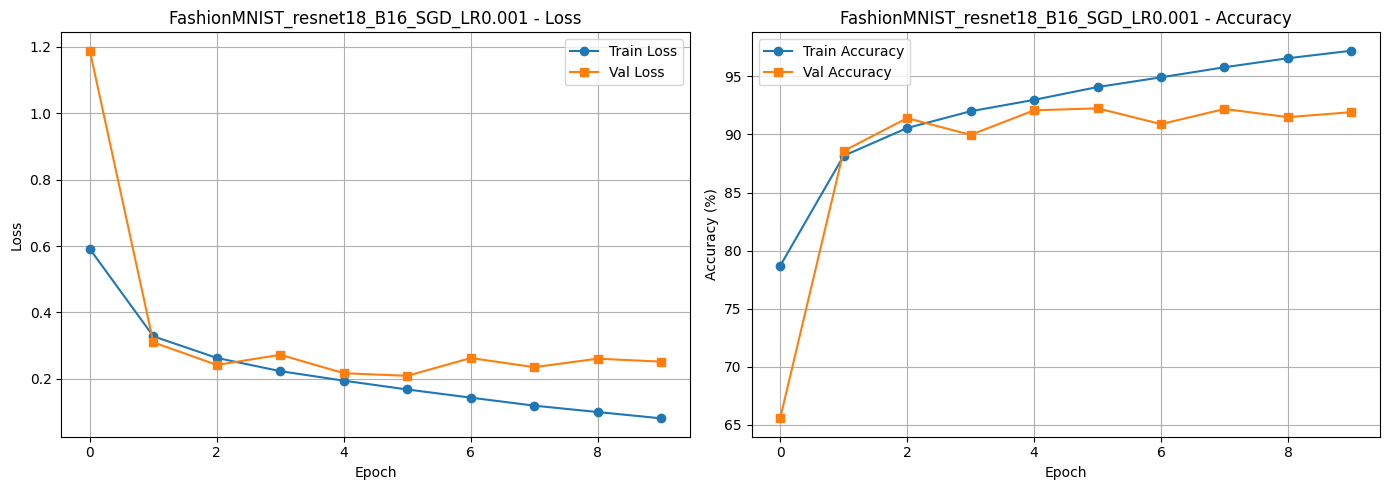


Dataset: FashionMNIST | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.001 | pin_memory: False
Epoch [1/10] Train Loss: 0.8201 Train Acc: 70.28% Val Loss: 0.5577 Val Acc: 80.90%
Epoch [2/10] Train Loss: 0.4163 Train Acc: 85.34% Val Loss: 0.3110 Val Acc: 88.90%
Epoch [3/10] Train Loss: 0.3234 Train Acc: 88.71% Val Loss: 0.3961 Val Acc: 87.56%
Epoch [4/10] Train Loss: 0.2696 Train Acc: 90.56% Val Loss: 0.2298 Val Acc: 91.79%
Epoch [5/10] Train Loss: 0.2238 Train Acc: 92.03% Val Loss: 0.2557 Val Acc: 91.01%
Epoch [6/10] Train Loss: 0.1899 Train Acc: 93.22% Val Loss: 0.2501 Val Acc: 91.06%
Epoch [7/10] Train Loss: 0.1655 Train Acc: 94.20% Val Loss: 0.2806 Val Acc: 90.59%
Epoch [8/10] Train Loss: 0.1399 Train Acc: 95.06% Val Loss: 0.2387 Val Acc: 91.99%
Epoch [9/10] Train Loss: 0.1145 Train Acc: 95.87% Val Loss: 0.2612 Val Acc: 91.89%
Epoch [10/10] Train Loss: 0.1016 Train Acc: 96.39% Val Loss: 0.2686 Val Acc: 91.64%

Test Accuracy: 91.97%


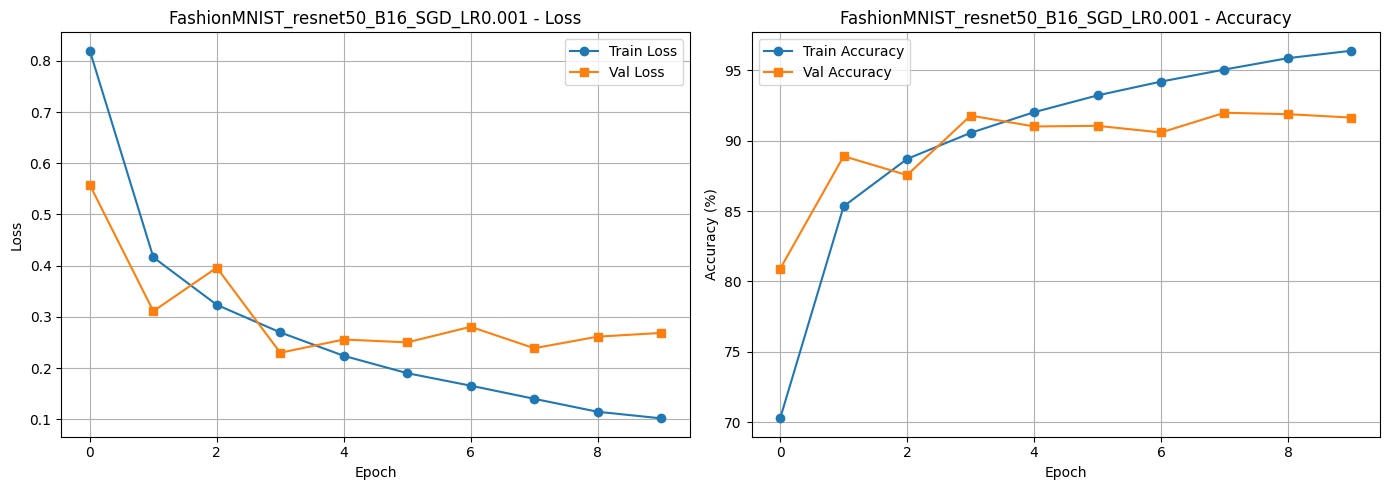


Dataset: FashionMNIST | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.0001 | pin_memory: False
Epoch [1/10] Train Loss: 1.1697 Train Acc: 63.02% Val Loss: 0.7154 Val Acc: 76.40%
Epoch [2/10] Train Loss: 0.6563 Train Acc: 76.93% Val Loss: 0.5485 Val Acc: 80.44%
Epoch [3/10] Train Loss: 0.5155 Train Acc: 81.81% Val Loss: 0.4282 Val Acc: 84.61%
Epoch [4/10] Train Loss: 0.4372 Train Acc: 84.60% Val Loss: 0.3690 Val Acc: 86.80%
Epoch [5/10] Train Loss: 0.3890 Train Acc: 86.14% Val Loss: 0.3479 Val Acc: 87.19%
Epoch [6/10] Train Loss: 0.3547 Train Acc: 87.48% Val Loss: 0.3168 Val Acc: 88.74%
Epoch [7/10] Train Loss: 0.3267 Train Acc: 88.50% Val Loss: 0.2932 Val Acc: 89.53%
Epoch [8/10] Train Loss: 0.3041 Train Acc: 89.27% Val Loss: 0.2829 Val Acc: 89.84%
Epoch [9/10] Train Loss: 0.2836 Train Acc: 90.11% Val Loss: 0.2703 Val Acc: 90.19%
Epoch [10/10] Train Loss: 0.2663 Train Acc: 90.57% Val Loss: 0.2620 Val Acc: 90.40%

Test Accuracy: 90.41%


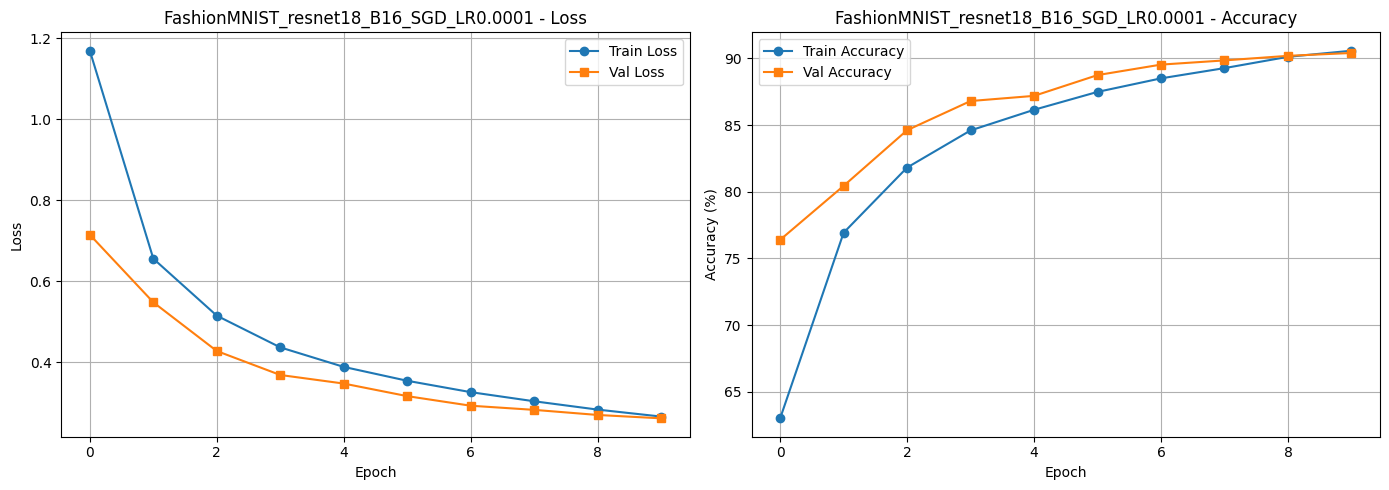


Dataset: FashionMNIST | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.0001 | pin_memory: False
Epoch [1/10] Train Loss: 1.4183 Train Acc: 48.25% Val Loss: 0.9098 Val Acc: 67.46%
Epoch [2/10] Train Loss: 0.8719 Train Acc: 68.38% Val Loss: 0.7063 Val Acc: 74.47%
Epoch [3/10] Train Loss: 0.6980 Train Acc: 74.51% Val Loss: 0.5665 Val Acc: 79.30%
Epoch [4/10] Train Loss: 0.5831 Train Acc: 78.47% Val Loss: 0.4798 Val Acc: 82.34%
Epoch [5/10] Train Loss: 0.5027 Train Acc: 81.76% Val Loss: 0.4169 Val Acc: 84.80%
Epoch [6/10] Train Loss: 0.4410 Train Acc: 84.20% Val Loss: 0.3924 Val Acc: 85.81%
Epoch [7/10] Train Loss: 0.3906 Train Acc: 85.98% Val Loss: 0.3577 Val Acc: 87.01%
Epoch [8/10] Train Loss: 0.3600 Train Acc: 87.11% Val Loss: 0.3418 Val Acc: 87.60%
Epoch [9/10] Train Loss: 0.3323 Train Acc: 88.14% Val Loss: 0.3102 Val Acc: 88.69%
Epoch [10/10] Train Loss: 0.3051 Train Acc: 89.09% Val Loss: 0.2896 Val Acc: 89.64%

Test Accuracy: 89.63%


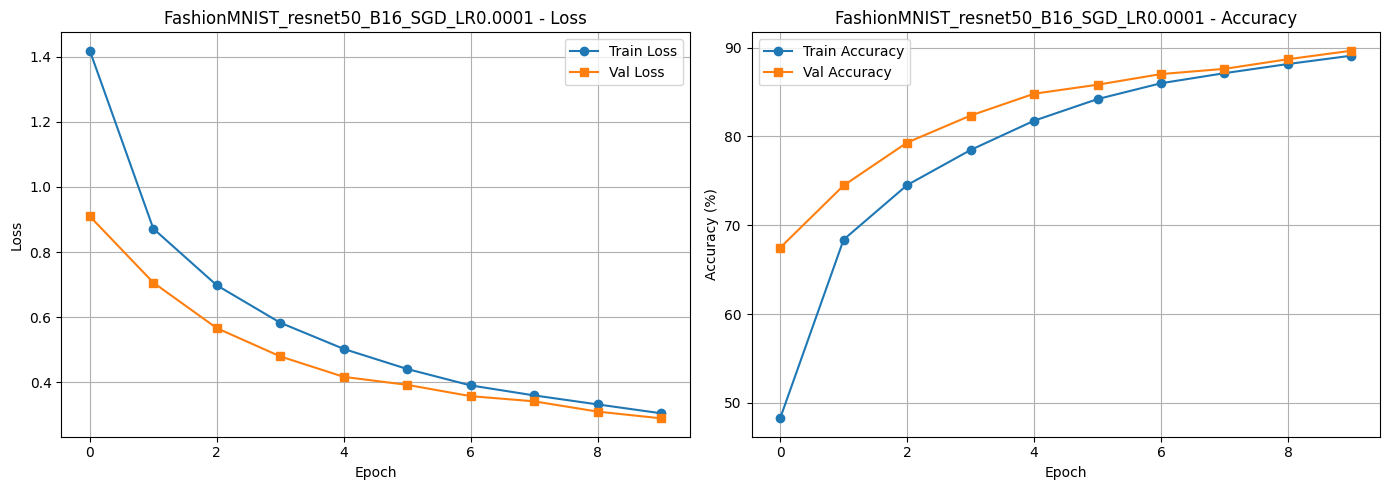


Dataset: FashionMNIST | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.001 | pin_memory: False
Epoch [1/10] Train Loss: 0.5592 Train Acc: 79.65% Val Loss: 0.4269 Val Acc: 84.14%
Epoch [2/10] Train Loss: 0.3898 Train Acc: 85.84% Val Loss: 0.3154 Val Acc: 88.51%
Epoch [3/10] Train Loss: 0.3189 Train Acc: 88.58% Val Loss: 0.3364 Val Acc: 88.54%
Epoch [4/10] Train Loss: 0.2899 Train Acc: 89.74% Val Loss: 0.2873 Val Acc: 90.21%
Epoch [5/10] Train Loss: 0.2707 Train Acc: 90.35% Val Loss: 0.2749 Val Acc: 89.94%
Epoch [6/10] Train Loss: 0.2572 Train Acc: 90.89% Val Loss: 0.2622 Val Acc: 90.40%
Epoch [7/10] Train Loss: 0.2476 Train Acc: 91.35% Val Loss: 0.2368 Val Acc: 91.16%
Epoch [8/10] Train Loss: 0.2388 Train Acc: 91.46% Val Loss: 0.2404 Val Acc: 91.44%
Epoch [9/10] Train Loss: 0.2307 Train Acc: 91.80% Val Loss: 0.2408 Val Acc: 90.73%
Epoch [10/10] Train Loss: 0.2271 Train Acc: 92.00% Val Loss: 0.2143 Val Acc: 92.03%

Test Accuracy: 92.11%


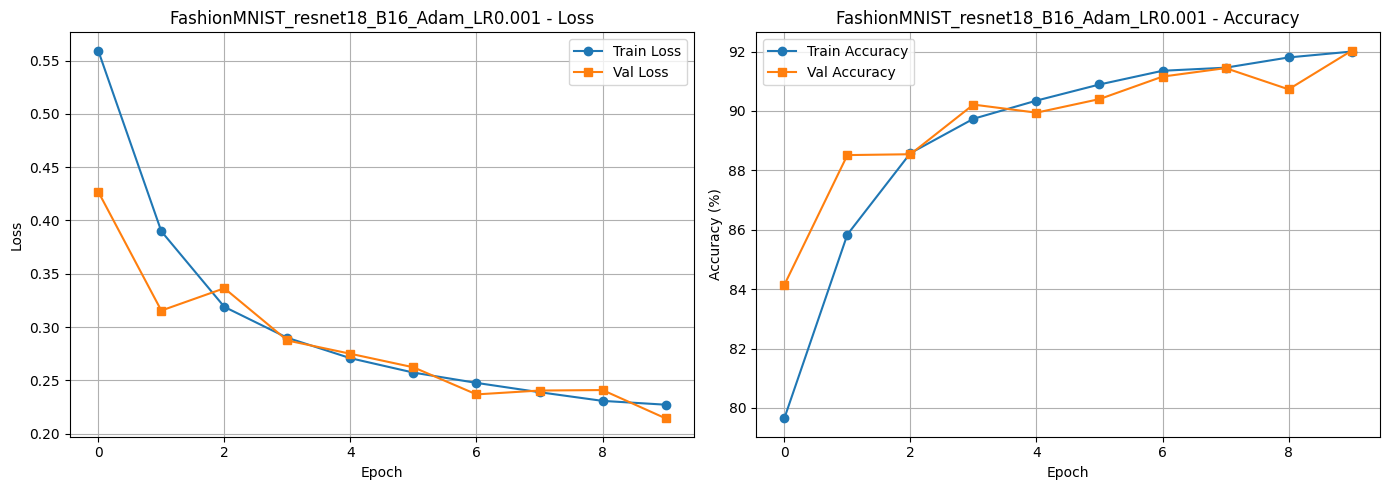


Dataset: FashionMNIST | Model: RESNET50 | Batch: 16 | Optimizer: Adam | LR: 0.001 | pin_memory: False
Epoch [1/10] Train Loss: 0.6706 Train Acc: 75.71% Val Loss: 0.5684 Val Acc: 78.54%
Epoch [2/10] Train Loss: 0.4821 Train Acc: 82.31% Val Loss: 0.4172 Val Acc: 85.13%
Epoch [3/10] Train Loss: 0.3854 Train Acc: 86.21% Val Loss: 0.3416 Val Acc: 86.93%
Epoch [4/10] Train Loss: 0.3447 Train Acc: 87.61% Val Loss: 0.4084 Val Acc: 85.79%
Epoch [5/10] Train Loss: 0.3174 Train Acc: 88.61% Val Loss: 0.2941 Val Acc: 89.36%
Epoch [6/10] Train Loss: 0.3032 Train Acc: 89.07% Val Loss: 0.2792 Val Acc: 89.91%
Epoch [7/10] Train Loss: 0.2893 Train Acc: 89.76% Val Loss: 0.3202 Val Acc: 88.23%
Epoch [8/10] Train Loss: 0.2804 Train Acc: 89.93% Val Loss: 0.2568 Val Acc: 90.63%
Epoch [9/10] Train Loss: 0.2727 Train Acc: 90.16% Val Loss: 0.2664 Val Acc: 90.29%
Epoch [10/10] Train Loss: 0.2680 Train Acc: 90.53% Val Loss: 0.2928 Val Acc: 89.36%

Test Accuracy: 89.11%


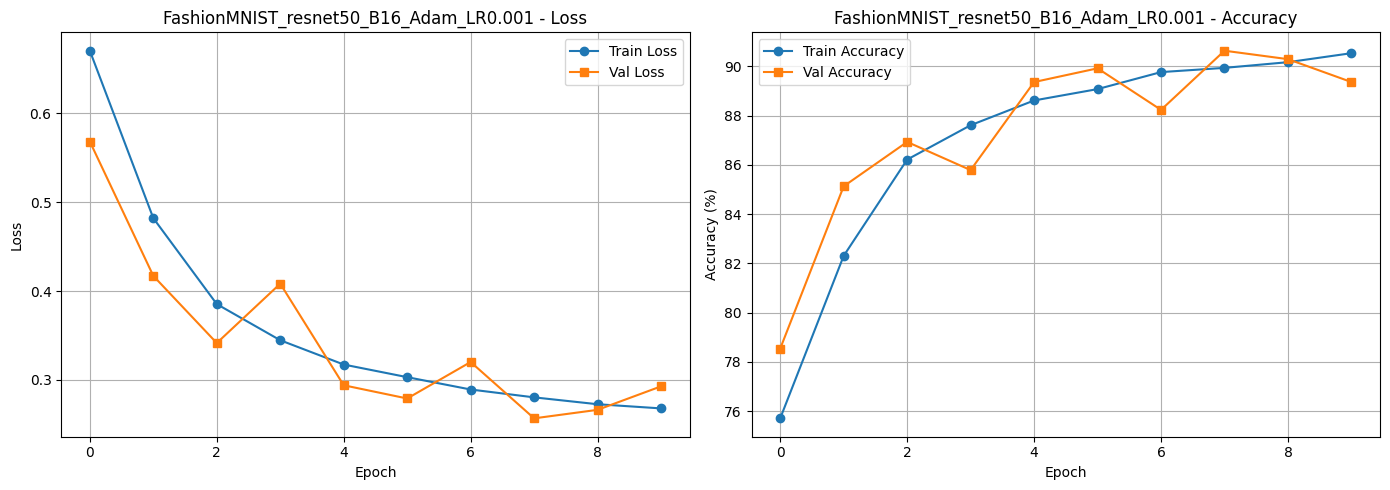


Dataset: FashionMNIST | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.0001 | pin_memory: False
Epoch [1/10] Train Loss: 0.4353 Train Acc: 84.25% Val Loss: 0.2948 Val Acc: 89.53%
Epoch [2/10] Train Loss: 0.2742 Train Acc: 90.26% Val Loss: 0.2551 Val Acc: 90.37%
Epoch [3/10] Train Loss: 0.2352 Train Acc: 91.64% Val Loss: 0.2509 Val Acc: 91.20%
Epoch [4/10] Train Loss: 0.2125 Train Acc: 92.55% Val Loss: 0.2091 Val Acc: 92.66%
Epoch [5/10] Train Loss: 0.1933 Train Acc: 93.22% Val Loss: 0.2218 Val Acc: 92.29%
Epoch [6/10] Train Loss: 0.1756 Train Acc: 93.90% Val Loss: 0.2252 Val Acc: 91.74%
Epoch [7/10] Train Loss: 0.1546 Train Acc: 94.64% Val Loss: 0.2000 Val Acc: 92.67%
Epoch [8/10] Train Loss: 0.1373 Train Acc: 95.14% Val Loss: 0.2151 Val Acc: 92.26%
Epoch [9/10] Train Loss: 0.1214 Train Acc: 95.95% Val Loss: 0.1953 Val Acc: 92.97%
Epoch [1/10] Train Loss: 0.5802 Train Acc: 78.48% Val Loss: 0.3314 Val Acc: 87.73%
Epoch [2/10] Train Loss: 0.3338 Train Acc: 87.93% Val Loss: 0.3127

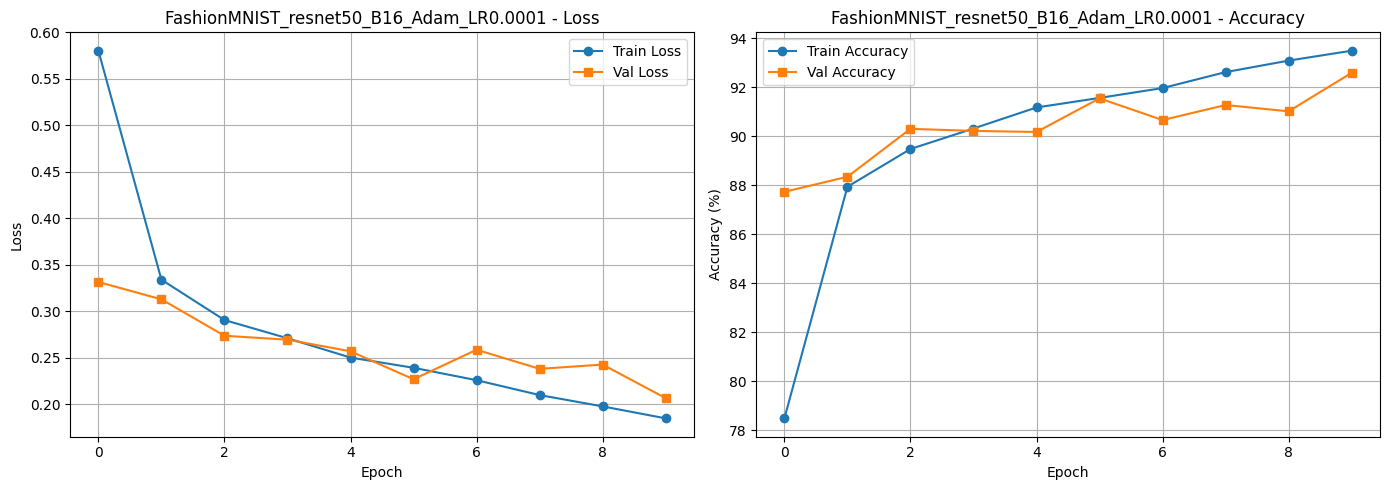


Dataset: FashionMNIST | Model: RESNET18 | Batch: 32 | Optimizer: SGD | LR: 0.001 | pin_memory: False
Epoch [1/10] Train Loss: 0.6796 Train Acc: 76.09% Val Loss: 0.4286 Val Acc: 84.37%
Epoch [2/10] Train Loss: 0.3636 Train Acc: 86.72% Val Loss: 0.3323 Val Acc: 87.83%
Epoch [3/10] Train Loss: 0.2927 Train Acc: 89.41% Val Loss: 0.2919 Val Acc: 89.31%
Epoch [4/10] Train Loss: 0.2493 Train Acc: 91.03% Val Loss: 0.2646 Val Acc: 90.29%
Epoch [5/10] Train Loss: 0.2142 Train Acc: 92.33% Val Loss: 0.2307 Val Acc: 91.24%
Epoch [6/10] Train Loss: 0.1858 Train Acc: 93.37% Val Loss: 0.2639 Val Acc: 90.37%
Epoch [7/10] Train Loss: 0.1606 Train Acc: 94.33% Val Loss: 0.2368 Val Acc: 91.79%
Epoch [8/10] Train Loss: 0.1356 Train Acc: 95.28% Val Loss: 0.2622 Val Acc: 91.13%
Epoch [9/10] Train Loss: 0.1086 Train Acc: 96.25% Val Loss: 0.2474 Val Acc: 91.59%
Epoch [10/10] Train Loss: 0.0855 Train Acc: 97.26% Val Loss: 0.2948 Val Acc: 90.63%

Test Accuracy: 90.59%


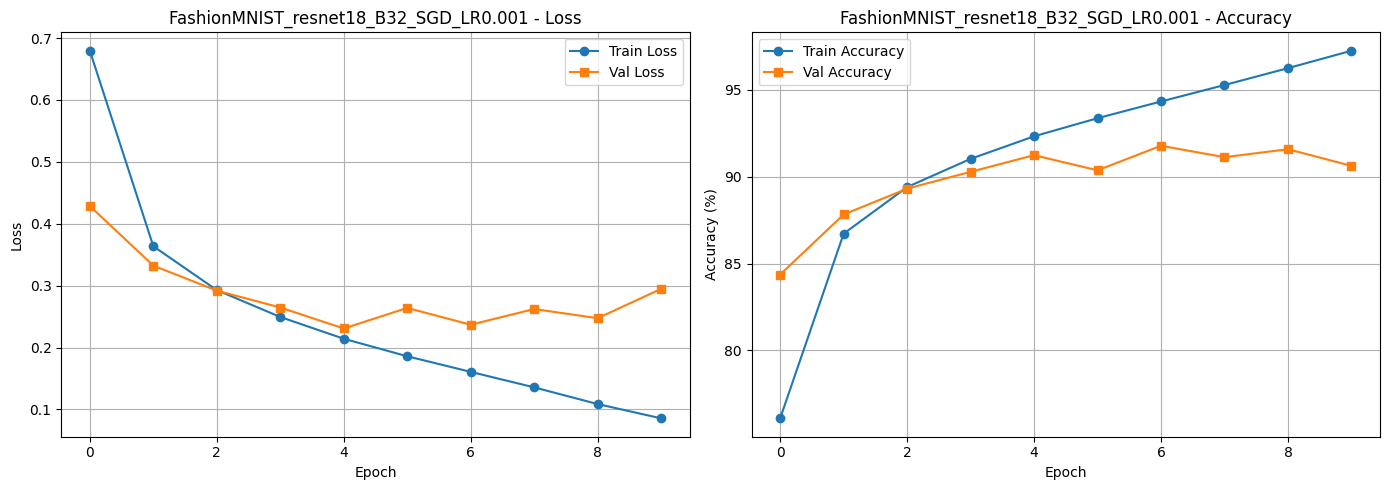


Dataset: FashionMNIST | Model: RESNET50 | Batch: 32 | Optimizer: SGD | LR: 0.001 | pin_memory: False
Epoch [1/10] Train Loss: 0.9261 Train Acc: 64.74% Val Loss: 0.4981 Val Acc: 81.61%
Epoch [2/10] Train Loss: 0.4653 Train Acc: 83.08% Val Loss: 0.4568 Val Acc: 83.21%
Epoch [3/10] Train Loss: 0.3600 Train Acc: 87.02% Val Loss: 0.2980 Val Acc: 89.26%
Epoch [4/10] Train Loss: 0.2970 Train Acc: 89.39% Val Loss: 0.2877 Val Acc: 89.17%
Epoch [5/10] Train Loss: 0.2529 Train Acc: 90.81% Val Loss: 0.2663 Val Acc: 90.27%
Epoch [6/10] Train Loss: 0.2236 Train Acc: 91.93% Val Loss: 0.2744 Val Acc: 90.03%
Epoch [7/10] Train Loss: 0.1891 Train Acc: 93.20% Val Loss: 0.2763 Val Acc: 90.70%
Epoch [8/10] Train Loss: 0.1606 Train Acc: 94.19% Val Loss: 0.2548 Val Acc: 90.99%
Epoch [9/10] Train Loss: 0.1340 Train Acc: 95.15% Val Loss: 0.2589 Val Acc: 91.84%
Epoch [10/10] Train Loss: 0.1177 Train Acc: 95.78% Val Loss: 0.3438 Val Acc: 89.33%

Test Accuracy: 89.71%


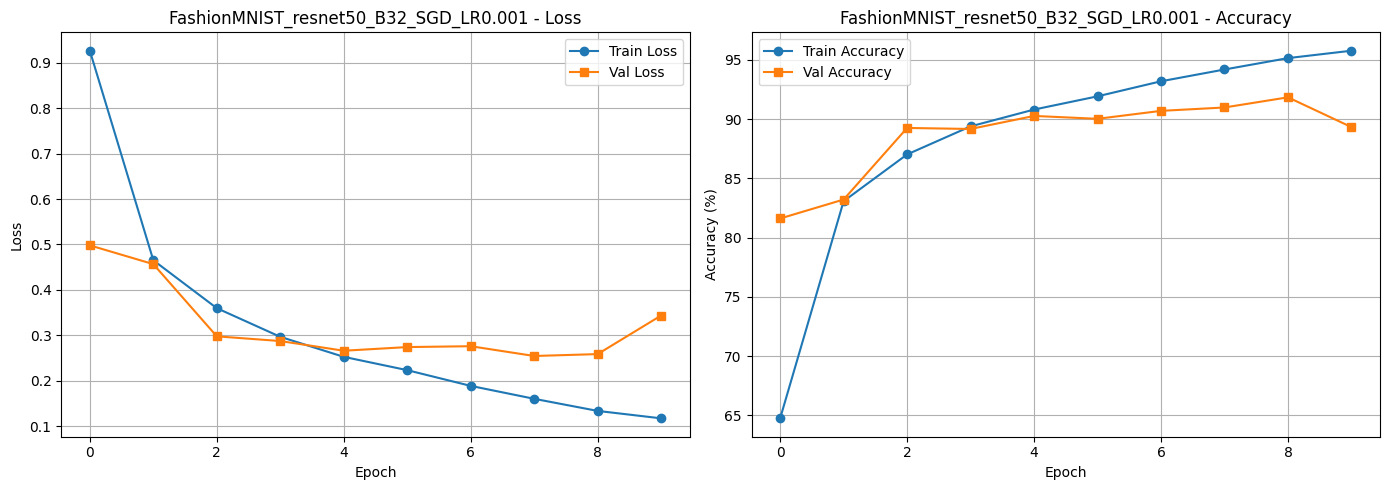


Dataset: FashionMNIST | Model: RESNET18 | Batch: 32 | Optimizer: SGD | LR: 0.0001 | pin_memory: False
Epoch [1/10] Train Loss: 1.3595 Train Acc: 60.33% Val Loss: 0.8886 Val Acc: 73.03%
Epoch [2/10] Train Loss: 0.7858 Train Acc: 74.09% Val Loss: 0.6920 Val Acc: 76.80%
Epoch [3/10] Train Loss: 0.6273 Train Acc: 78.29% Val Loss: 0.5520 Val Acc: 81.19%
Epoch [4/10] Train Loss: 0.5337 Train Acc: 81.52% Val Loss: 0.5025 Val Acc: 82.27%
Epoch [5/10] Train Loss: 0.4749 Train Acc: 83.46% Val Loss: 0.4741 Val Acc: 83.80%
Epoch [6/10] Train Loss: 0.4276 Train Acc: 85.28% Val Loss: 0.4045 Val Acc: 86.11%
Epoch [7/10] Train Loss: 0.3932 Train Acc: 86.29% Val Loss: 0.3655 Val Acc: 86.89%
Epoch [8/10] Train Loss: 0.3650 Train Acc: 87.31% Val Loss: 0.4280 Val Acc: 84.39%
Epoch [9/10] Train Loss: 0.3444 Train Acc: 87.89% Val Loss: 0.3275 Val Acc: 87.91%
Epoch [10/10] Train Loss: 0.3266 Train Acc: 88.60% Val Loss: 0.3075 Val Acc: 88.80%

Test Accuracy: 88.86%


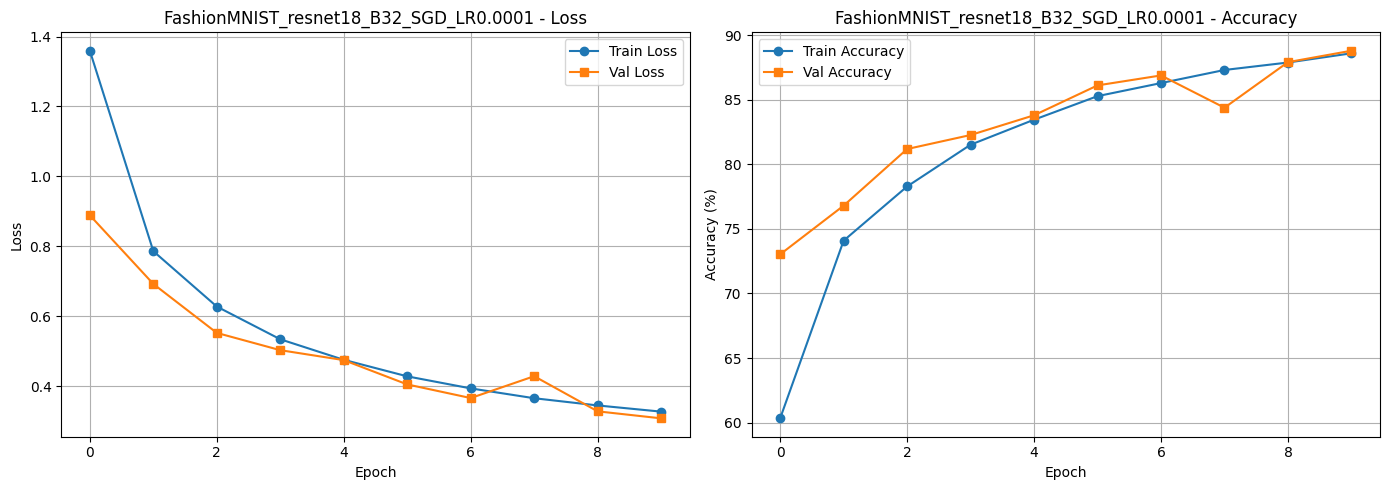


Dataset: FashionMNIST | Model: RESNET50 | Batch: 32 | Optimizer: SGD | LR: 0.0001 | pin_memory: False
Epoch [1/10] Train Loss: 1.6298 Train Acc: 41.25% Val Loss: 1.1488 Val Acc: 59.43%
Epoch [2/10] Train Loss: 1.0610 Train Acc: 62.66% Val Loss: 0.9124 Val Acc: 67.51%
Epoch [3/10] Train Loss: 0.8814 Train Acc: 68.48% Val Loss: 0.7973 Val Acc: 72.00%
Epoch [4/10] Train Loss: 0.7731 Train Acc: 72.08% Val Loss: 0.6844 Val Acc: 75.56%
Epoch [5/10] Train Loss: 0.6918 Train Acc: 74.99% Val Loss: 0.6616 Val Acc: 75.57%
Epoch [6/10] Train Loss: 0.6244 Train Acc: 77.21% Val Loss: 0.5579 Val Acc: 79.77%
Epoch [7/10] Train Loss: 0.5682 Train Acc: 79.13% Val Loss: 0.5153 Val Acc: 81.61%
Epoch [8/10] Train Loss: 0.5234 Train Acc: 81.09% Val Loss: 0.4837 Val Acc: 82.47%
Epoch [9/10] Train Loss: 0.4844 Train Acc: 82.64% Val Loss: 0.4782 Val Acc: 83.03%
Epoch [10/10] Train Loss: 0.4499 Train Acc: 83.97% Val Loss: 0.4157 Val Acc: 85.01%

Test Accuracy: 85.04%


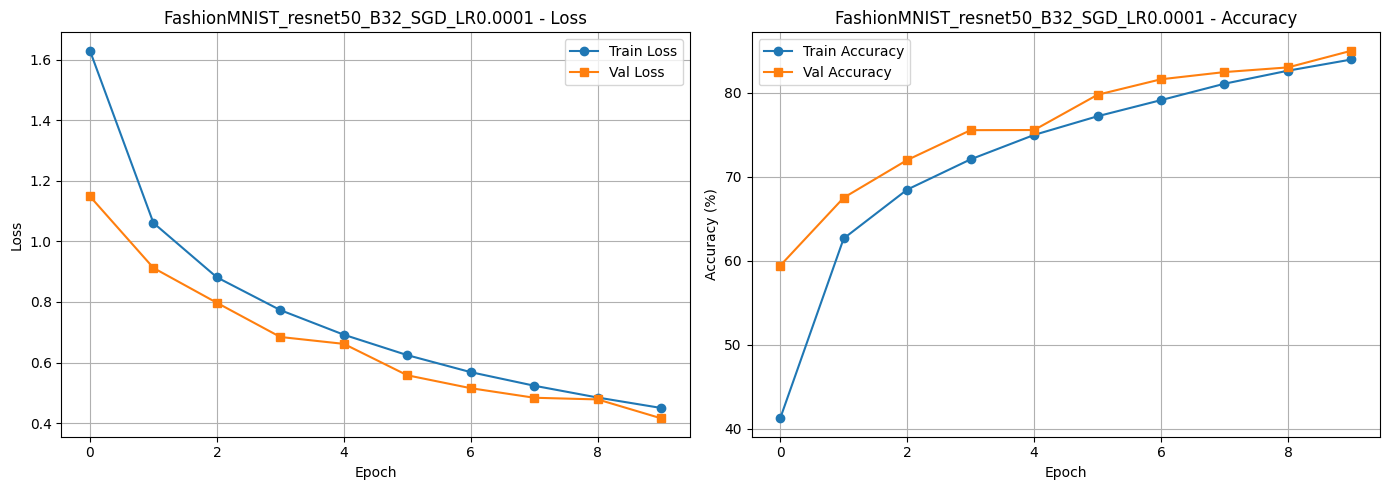


Dataset: FashionMNIST | Model: RESNET18 | Batch: 32 | Optimizer: Adam | LR: 0.001 | pin_memory: False
Epoch [1/10] Train Loss: 0.5162 Train Acc: 81.30% Val Loss: 0.5844 Val Acc: 78.93%
Epoch [2/10] Train Loss: 0.3776 Train Acc: 86.37% Val Loss: 0.5492 Val Acc: 80.79%
Epoch [3/10] Train Loss: 0.3168 Train Acc: 88.65% Val Loss: 3.9437 Val Acc: 36.89%
Epoch [4/10] Train Loss: 0.2809 Train Acc: 90.15% Val Loss: 1.1676 Val Acc: 74.70%
Epoch [5/10] Train Loss: 0.2599 Train Acc: 90.73% Val Loss: 0.2635 Val Acc: 90.49%
Epoch [6/10] Train Loss: 0.2412 Train Acc: 91.41% Val Loss: 0.3022 Val Acc: 88.91%
Epoch [7/10] Train Loss: 0.2282 Train Acc: 91.92% Val Loss: 0.2459 Val Acc: 91.09%
Epoch [8/10] Train Loss: 0.2197 Train Acc: 92.30% Val Loss: 0.2333 Val Acc: 91.63%
Epoch [9/10] Train Loss: 0.2127 Train Acc: 92.48% Val Loss: 0.2410 Val Acc: 91.57%
Epoch [10/10] Train Loss: 0.2028 Train Acc: 92.90% Val Loss: 0.2516 Val Acc: 91.40%

Test Accuracy: 91.12%


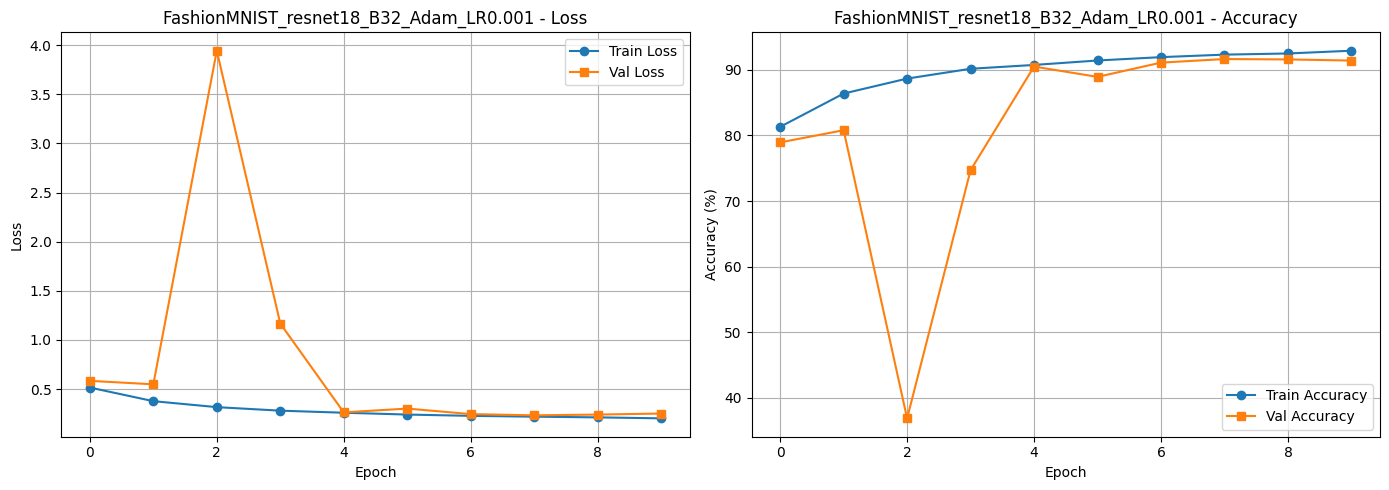


Dataset: FashionMNIST | Model: RESNET50 | Batch: 32 | Optimizer: Adam | LR: 0.001 | pin_memory: False
Epoch [1/10] Train Loss: 0.6058 Train Acc: 78.38% Val Loss: 0.4465 Val Acc: 85.16%
Epoch [2/10] Train Loss: 0.4348 Train Acc: 84.56% Val Loss: 0.4328 Val Acc: 83.60%
Epoch [3/10] Train Loss: 0.3715 Train Acc: 86.63% Val Loss: 0.4513 Val Acc: 83.19%
Epoch [4/10] Train Loss: 0.3274 Train Acc: 88.28% Val Loss: 0.2935 Val Acc: 89.30%
Epoch [5/10] Train Loss: 0.2998 Train Acc: 89.30% Val Loss: 0.2727 Val Acc: 89.71%
Epoch [6/10] Train Loss: 0.2803 Train Acc: 89.90% Val Loss: 0.2711 Val Acc: 89.94%
Epoch [7/10] Train Loss: 0.2655 Train Acc: 90.44% Val Loss: 0.2654 Val Acc: 90.49%
Epoch [8/10] Train Loss: 0.2589 Train Acc: 90.81% Val Loss: 0.2467 Val Acc: 90.89%
Epoch [9/10] Train Loss: 0.2460 Train Acc: 91.07% Val Loss: 0.2382 Val Acc: 91.41%
Epoch [10/10] Train Loss: 0.2405 Train Acc: 91.41% Val Loss: 1.3308 Val Acc: 50.70%

Test Accuracy: 50.81%

Dataset: FashionMNIST | Model: RESNET18 | 

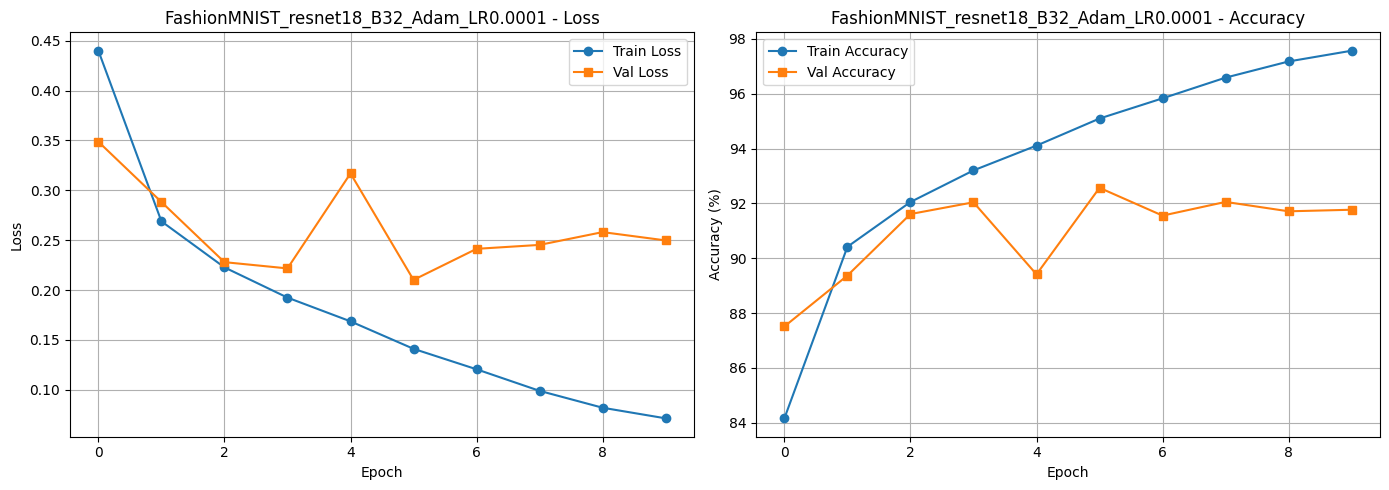


Dataset: FashionMNIST | Model: RESNET50 | Batch: 32 | Optimizer: Adam | LR: 0.0001 | pin_memory: False
Epoch [1/10] Train Loss: 0.5874 Train Acc: 78.17% Val Loss: 0.3620 Val Acc: 86.20%
Epoch [2/10] Train Loss: 0.3251 Train Acc: 88.22% Val Loss: 0.3187 Val Acc: 88.50%
Epoch [3/10] Train Loss: 0.2677 Train Acc: 90.40% Val Loss: 0.2671 Val Acc: 90.11%
Epoch [4/10] Train Loss: 0.2405 Train Acc: 91.31% Val Loss: 0.3006 Val Acc: 89.09%
Epoch [5/10] Train Loss: 0.2211 Train Acc: 91.91% Val Loss: 0.2701 Val Acc: 90.79%
Epoch [6/10] Train Loss: 0.2067 Train Acc: 92.69% Val Loss: 0.2424 Val Acc: 91.29%
Epoch [7/10] Train Loss: 0.1940 Train Acc: 93.22% Val Loss: 0.2589 Val Acc: 90.64%
Epoch [8/10] Train Loss: 0.1808 Train Acc: 93.60% Val Loss: 0.2478 Val Acc: 91.27%
Epoch [9/10] Train Loss: 0.1701 Train Acc: 93.92% Val Loss: 0.2746 Val Acc: 90.44%
Epoch [10/10] Train Loss: 0.1587 Train Acc: 94.56% Val Loss: 0.2140 Val Acc: 92.36%

Test Accuracy: 92.43%


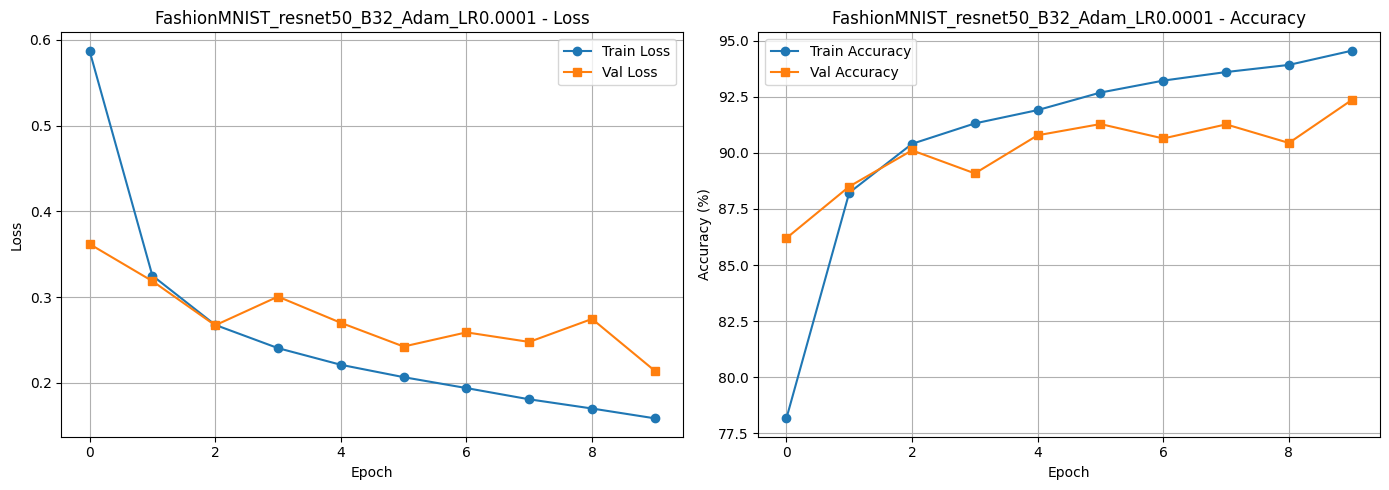

In [ ]:
# Run FashionMNIST experiments with pin_memory=False and 10 epochs
fashion_results = run_q1a_experiments(
    'FashionMNIST', fashion_train, fashion_val, fashion_test,
    epochs=10, pin_memory=False
)
q1a_results.extend(fashion_results)


Dataset: FashionMNIST | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.5843 Train Acc: 78.93% Val Loss: 0.3411 Val Acc: 87.46%
Epoch [2/5] Train Loss: 0.3169 Train Acc: 88.67% Val Loss: 0.2653 Val Acc: 90.09%
Epoch [3/5] Train Loss: 0.2595 Train Acc: 90.64% Val Loss: 0.2352 Val Acc: 91.44%
Epoch [4/5] Train Loss: 0.2187 Train Acc: 92.37% Val Loss: 0.2172 Val Acc: 91.97%
Epoch [5/5] Train Loss: 0.1851 Train Acc: 93.41% Val Loss: 0.2214 Val Acc: 91.74%

Test Accuracy: 92.04%


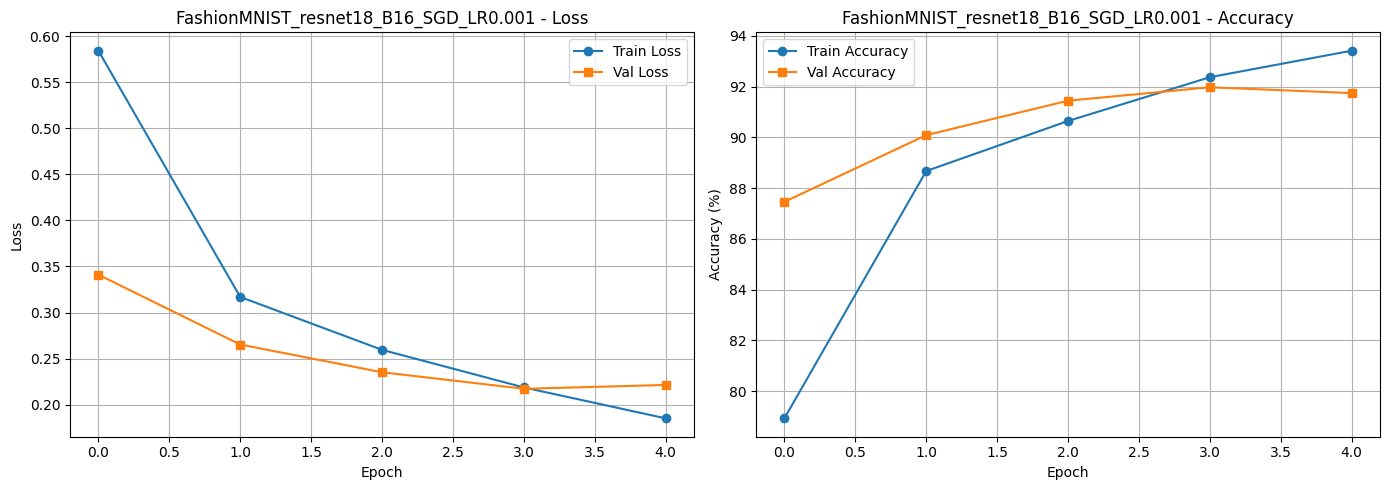


Dataset: FashionMNIST | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.8603 Train Acc: 69.13% Val Loss: 0.4664 Val Acc: 83.77%
Epoch [2/5] Train Loss: 0.4392 Train Acc: 84.62% Val Loss: 0.3070 Val Acc: 89.04%
Epoch [3/5] Train Loss: 0.3374 Train Acc: 88.15% Val Loss: 0.2607 Val Acc: 90.46%
Epoch [4/5] Train Loss: 0.2829 Train Acc: 90.12% Val Loss: 0.2975 Val Acc: 89.64%
Epoch [5/5] Train Loss: 0.2345 Train Acc: 91.71% Val Loss: 0.2394 Val Acc: 91.67%

Test Accuracy: 91.64%


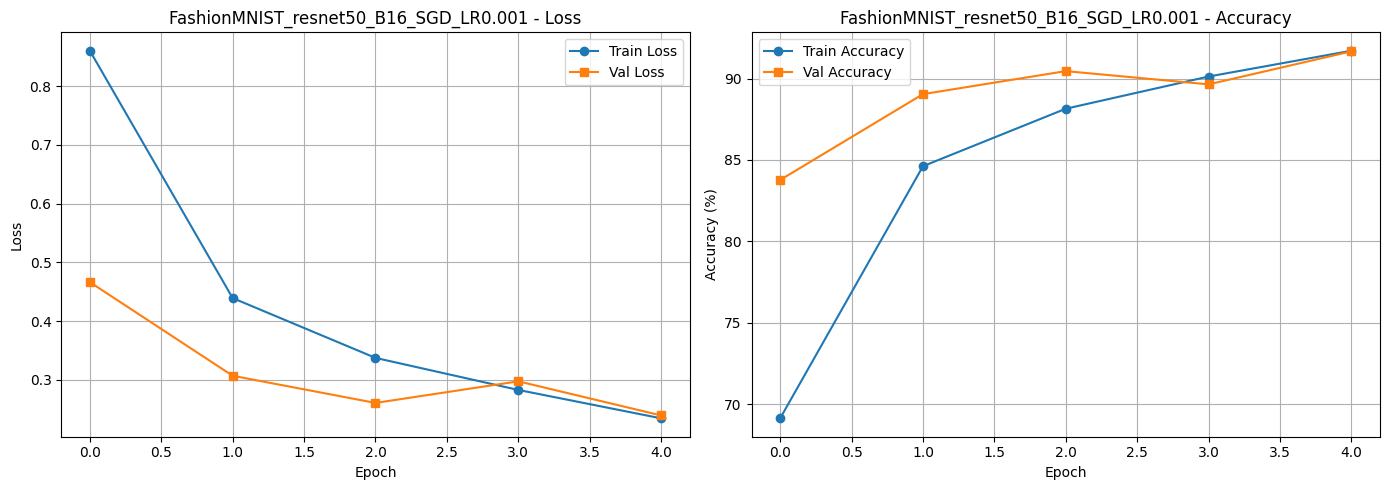


Dataset: FashionMNIST | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 1.1484 Train Acc: 64.02% Val Loss: 0.7366 Val Acc: 74.81%
Epoch [2/5] Train Loss: 0.6371 Train Acc: 77.69% Val Loss: 0.5038 Val Acc: 82.19%
Epoch [3/5] Train Loss: 0.5037 Train Acc: 82.29% Val Loss: 0.5238 Val Acc: 82.20%
Epoch [4/5] Train Loss: 0.4296 Train Acc: 84.96% Val Loss: 0.4067 Val Acc: 85.60%
Epoch [5/5] Train Loss: 0.3810 Train Acc: 86.53% Val Loss: 0.3374 Val Acc: 87.64%

Test Accuracy: 88.04%


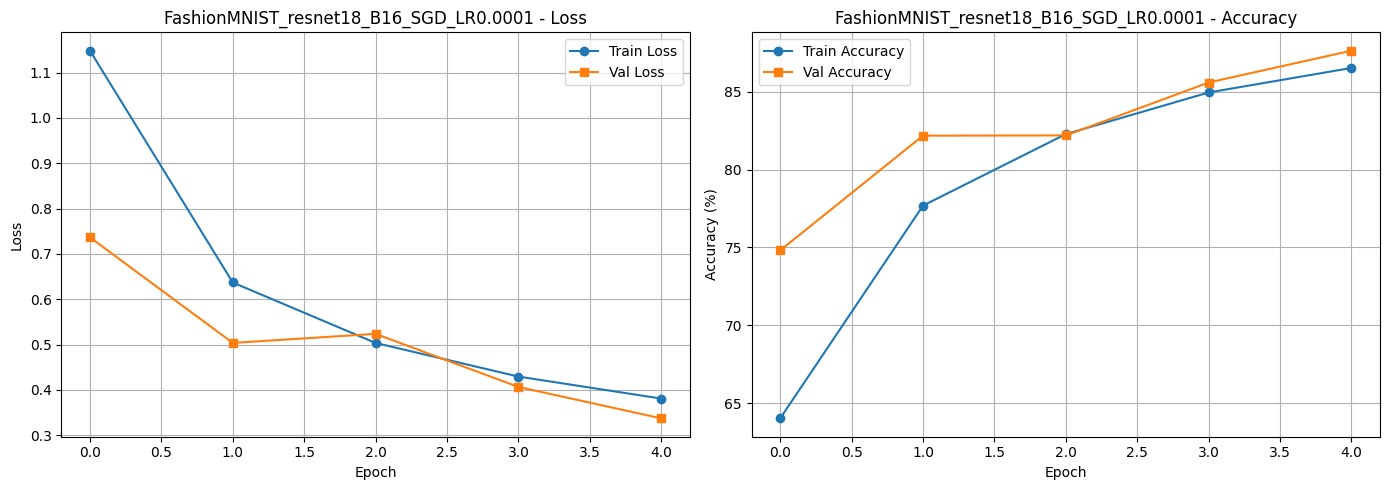


Dataset: FashionMNIST | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 1.4141 Train Acc: 48.19% Val Loss: 0.9105 Val Acc: 67.94%
Epoch [2/5] Train Loss: 0.8963 Train Acc: 67.25% Val Loss: 0.7048 Val Acc: 74.77%
Epoch [3/5] Train Loss: 0.7154 Train Acc: 73.77% Val Loss: 0.5857 Val Acc: 77.79%
Epoch [4/5] Train Loss: 0.5962 Train Acc: 78.03% Val Loss: 0.4902 Val Acc: 82.60%
Epoch [5/5] Train Loss: 0.5121 Train Acc: 81.14% Val Loss: 0.4294 Val Acc: 84.44%

Test Accuracy: 83.75%


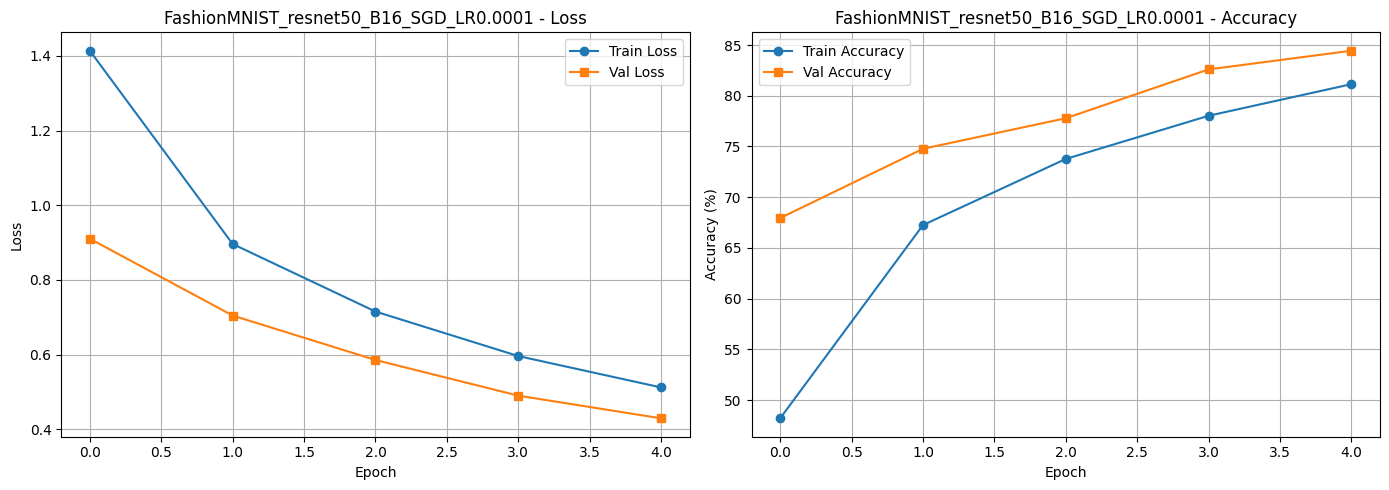


Dataset: FashionMNIST | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.5762 Train Acc: 79.01% Val Loss: 0.4012 Val Acc: 85.87%
Epoch [2/5] Train Loss: 0.3973 Train Acc: 85.87% Val Loss: 0.3207 Val Acc: 88.47%
Epoch [3/5] Train Loss: 0.3275 Train Acc: 88.21% Val Loss: 0.2860 Val Acc: 89.50%
Epoch [4/5] Train Loss: 0.2950 Train Acc: 89.60% Val Loss: 0.2955 Val Acc: 89.34%
Epoch [5/5] Train Loss: 0.2730 Train Acc: 90.41% Val Loss: 0.2667 Val Acc: 91.07%

Test Accuracy: 90.62%


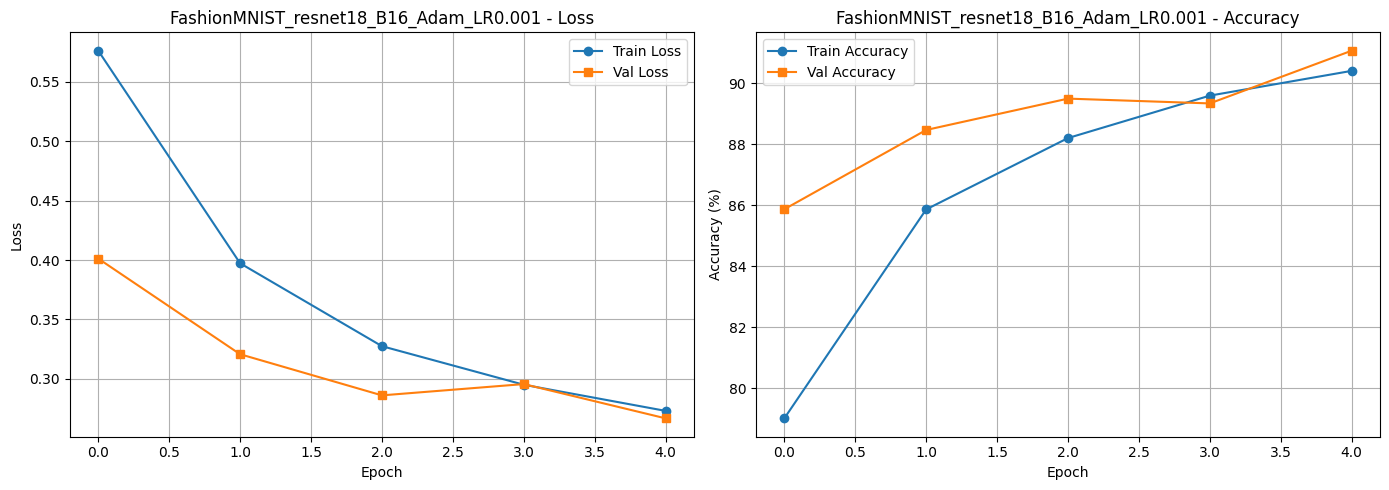


Dataset: FashionMNIST | Model: RESNET50 | Batch: 16 | Optimizer: Adam | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.6976 Train Acc: 74.42% Val Loss: 1.7666 Val Acc: 36.43%
Epoch [2/5] Train Loss: 0.4907 Train Acc: 82.15% Val Loss: 0.4258 Val Acc: 84.84%
Epoch [3/5] Train Loss: 0.3879 Train Acc: 85.95% Val Loss: 0.3634 Val Acc: 86.67%
Epoch [4/5] Train Loss: 0.3361 Train Acc: 88.05% Val Loss: 0.3024 Val Acc: 89.40%
Epoch [5/5] Train Loss: 0.3132 Train Acc: 88.88% Val Loss: 0.2778 Val Acc: 89.56%

Test Accuracy: 89.71%


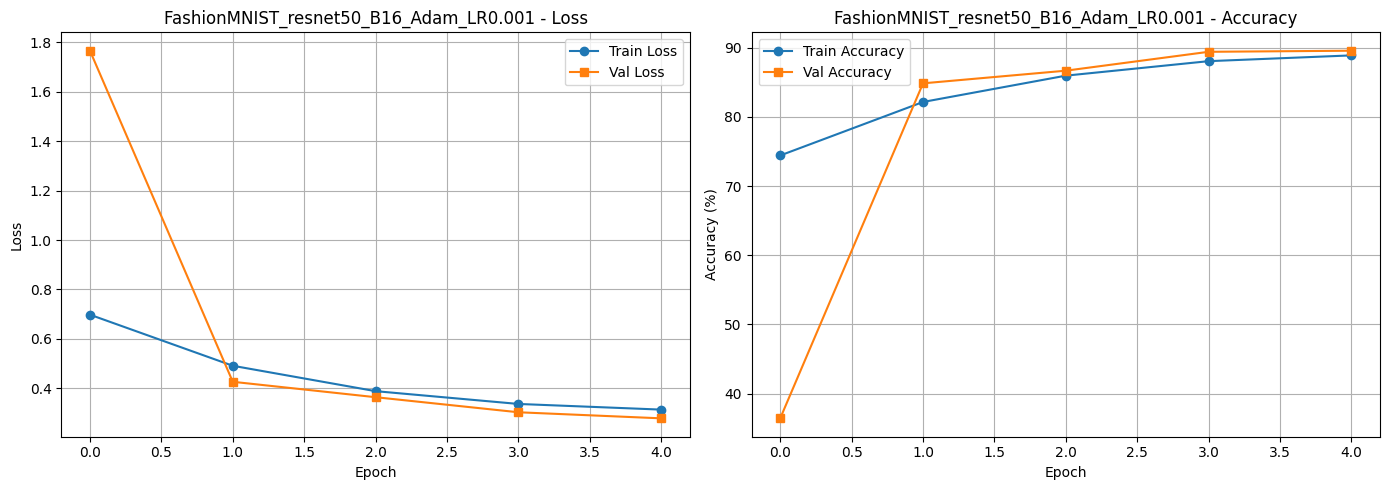


Dataset: FashionMNIST | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 0.4318 Train Acc: 84.45% Val Loss: 0.3142 Val Acc: 88.74%
Epoch [2/5] Train Loss: 0.2739 Train Acc: 90.32% Val Loss: 0.2657 Val Acc: 90.40%
Epoch [3/5] Train Loss: 0.2353 Train Acc: 91.69% Val Loss: 0.2366 Val Acc: 91.54%
Epoch [4/5] Train Loss: 0.2098 Train Acc: 92.53% Val Loss: 0.2266 Val Acc: 91.66%
Epoch [5/5] Train Loss: 0.1898 Train Acc: 93.37% Val Loss: 0.2298 Val Acc: 92.13%

Test Accuracy: 91.89%


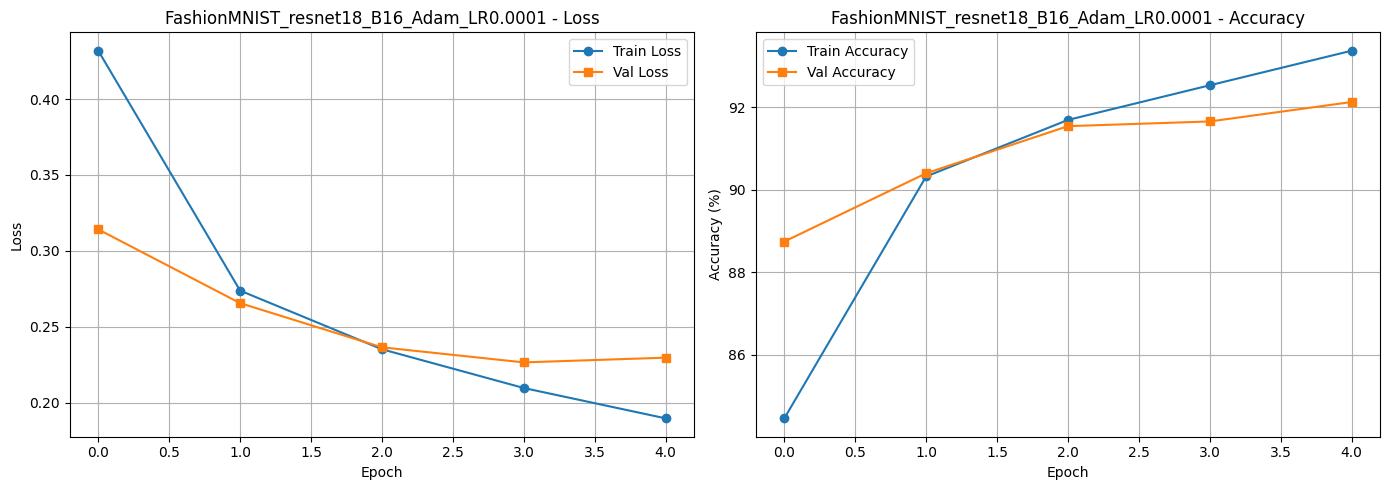


Dataset: FashionMNIST | Model: RESNET50 | Batch: 16 | Optimizer: Adam | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 0.5737 Train Acc: 78.74% Val Loss: 0.3360 Val Acc: 87.43%
Epoch [2/5] Train Loss: 0.3289 Train Acc: 88.13% Val Loss: 0.2884 Val Acc: 89.06%
Epoch [3/5] Train Loss: 0.2881 Train Acc: 89.74% Val Loss: 0.2983 Val Acc: 89.37%
Epoch [4/5] Train Loss: 0.2700 Train Acc: 90.42% Val Loss: 0.2442 Val Acc: 91.27%
Epoch [5/5] Train Loss: 0.2507 Train Acc: 91.12% Val Loss: 0.2683 Val Acc: 90.46%

Test Accuracy: 90.49%


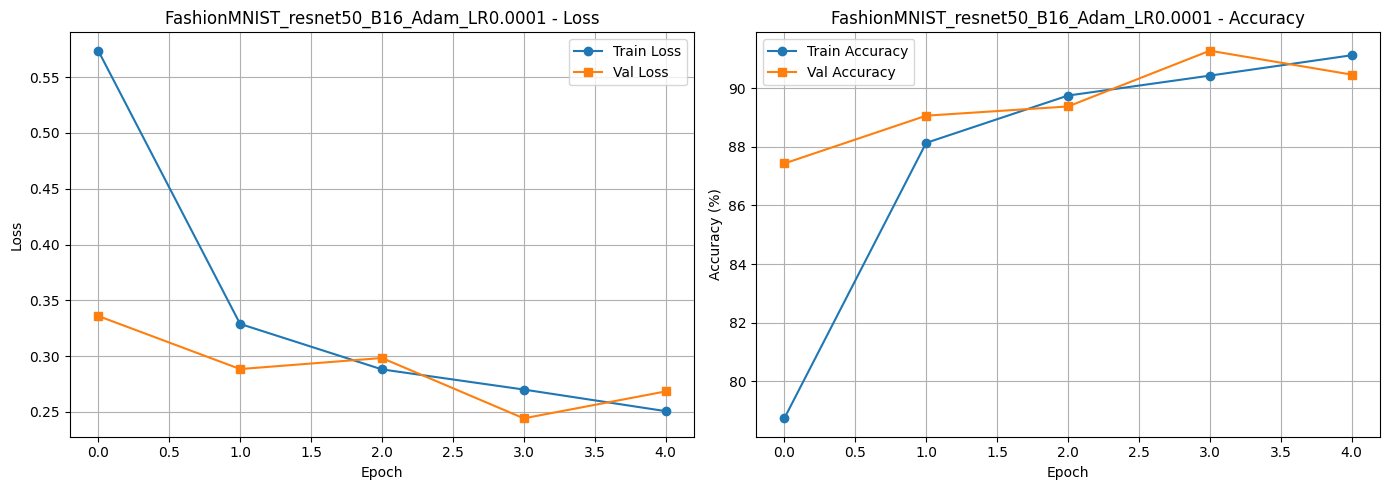


Dataset: FashionMNIST | Model: RESNET18 | Batch: 32 | Optimizer: SGD | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.6769 Train Acc: 76.05% Val Loss: 0.3912 Val Acc: 85.76%
Epoch [2/5] Train Loss: 0.3569 Train Acc: 87.07% Val Loss: 0.3330 Val Acc: 87.67%
Epoch [3/5] Train Loss: 0.2863 Train Acc: 89.56% Val Loss: 0.2852 Val Acc: 89.94%
Epoch [4/5] Train Loss: 0.2432 Train Acc: 91.32% Val Loss: 0.2590 Val Acc: 90.69%
Epoch [5/5] Train Loss: 0.2110 Train Acc: 92.47% Val Loss: 0.2429 Val Acc: 91.01%

Test Accuracy: 91.17%


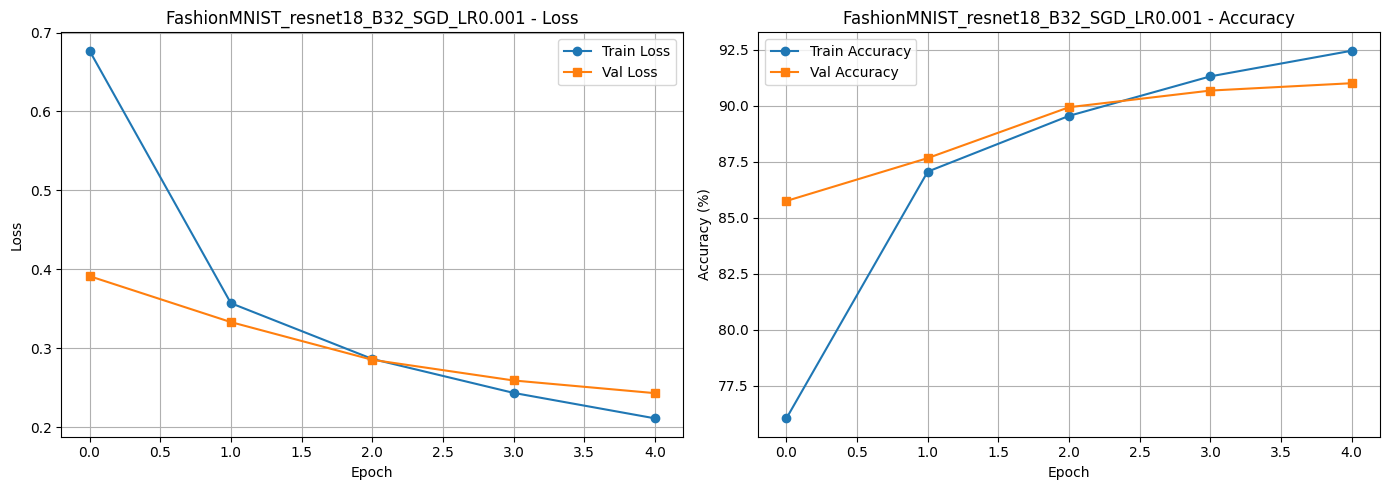


Dataset: FashionMNIST | Model: RESNET50 | Batch: 32 | Optimizer: SGD | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.9169 Train Acc: 65.74% Val Loss: 0.6094 Val Acc: 78.27%
Epoch [2/5] Train Loss: 0.4661 Train Acc: 83.08% Val Loss: 0.4088 Val Acc: 85.20%
Epoch [3/5] Train Loss: 0.3539 Train Acc: 87.14% Val Loss: 0.3126 Val Acc: 88.97%
Epoch [4/5] Train Loss: 0.2907 Train Acc: 89.56% Val Loss: 0.3180 Val Acc: 88.90%
Epoch [5/5] Train Loss: 0.2477 Train Acc: 91.02% Val Loss: 0.2730 Val Acc: 90.11%

Test Accuracy: 90.26%


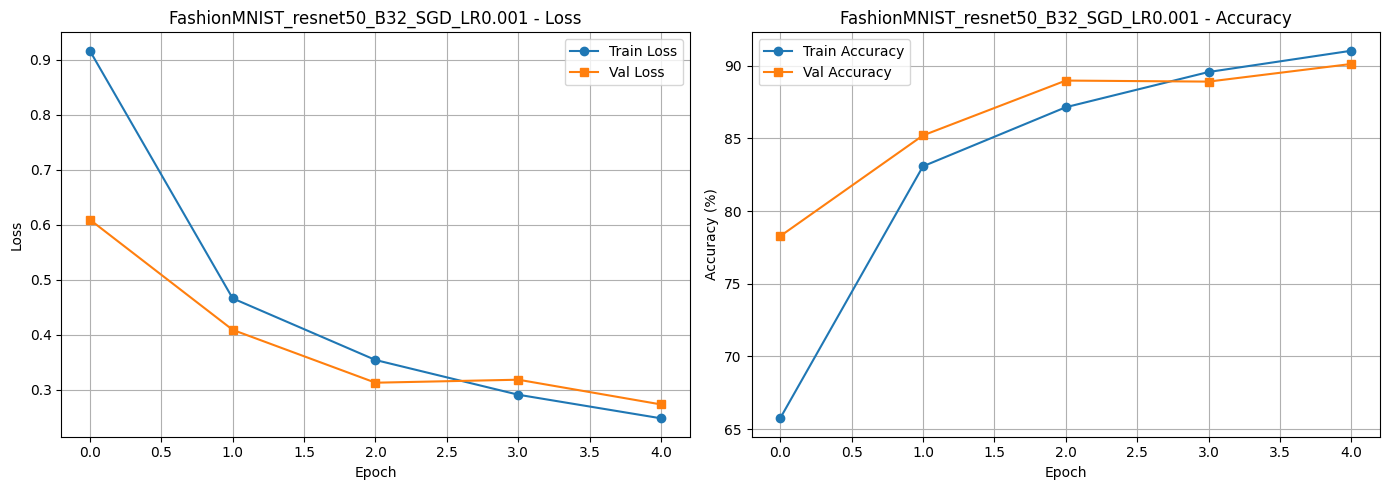


Dataset: FashionMNIST | Model: RESNET18 | Batch: 32 | Optimizer: SGD | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 1.3923 Train Acc: 59.51% Val Loss: 0.9280 Val Acc: 72.04%
Epoch [2/5] Train Loss: 0.7921 Train Acc: 73.68% Val Loss: 0.6732 Val Acc: 77.09%
Epoch [3/5] Train Loss: 0.6326 Train Acc: 77.80% Val Loss: 0.7182 Val Acc: 74.06%
Epoch [4/5] Train Loss: 0.5449 Train Acc: 80.79% Val Loss: 0.4942 Val Acc: 82.66%
Epoch [5/5] Train Loss: 0.4842 Train Acc: 82.94% Val Loss: 0.4341 Val Acc: 84.91%

Test Accuracy: 84.76%


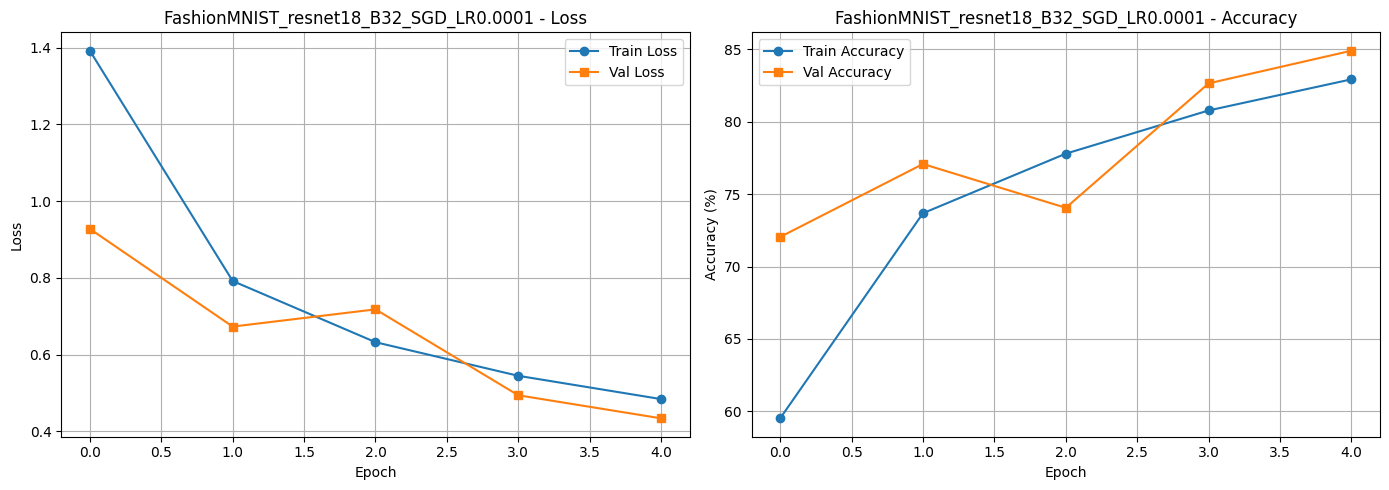


Dataset: FashionMNIST | Model: RESNET50 | Batch: 32 | Optimizer: SGD | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 1.6625 Train Acc: 40.39% Val Loss: 1.1339 Val Acc: 61.47%
Epoch [2/5] Train Loss: 1.0404 Train Acc: 63.38% Val Loss: 0.8751 Val Acc: 69.14%
Epoch [3/5] Train Loss: 0.8574 Train Acc: 69.48% Val Loss: 0.7489 Val Acc: 73.87%
Epoch [4/5] Train Loss: 0.7429 Train Acc: 73.08% Val Loss: 0.6620 Val Acc: 75.77%
Epoch [5/5] Train Loss: 0.6642 Train Acc: 75.75% Val Loss: 0.5857 Val Acc: 78.94%

Test Accuracy: 78.25%

Dataset: FashionMNIST | Model: RESNET18 | Batch: 32 | Optimizer: Adam | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.5263 Train Acc: 80.95% Val Loss: 0.4437 Val Acc: 82.79%
Epoch [2/5] Train Loss: 0.3768 Train Acc: 86.51% Val Loss: 0.6762 Val Acc: 75.06%
Epoch [3/5] Train Loss: 0.3175 Train Acc: 88.76% Val Loss: 1.7078 Val Acc: 50.16%
Epoch [4/5] Train Loss: 0.2840 Train Acc: 89.82% Val Loss: 0.2679 Val Acc: 90.79%
Epoch [5/5] Train Loss: 0.2585 Trai

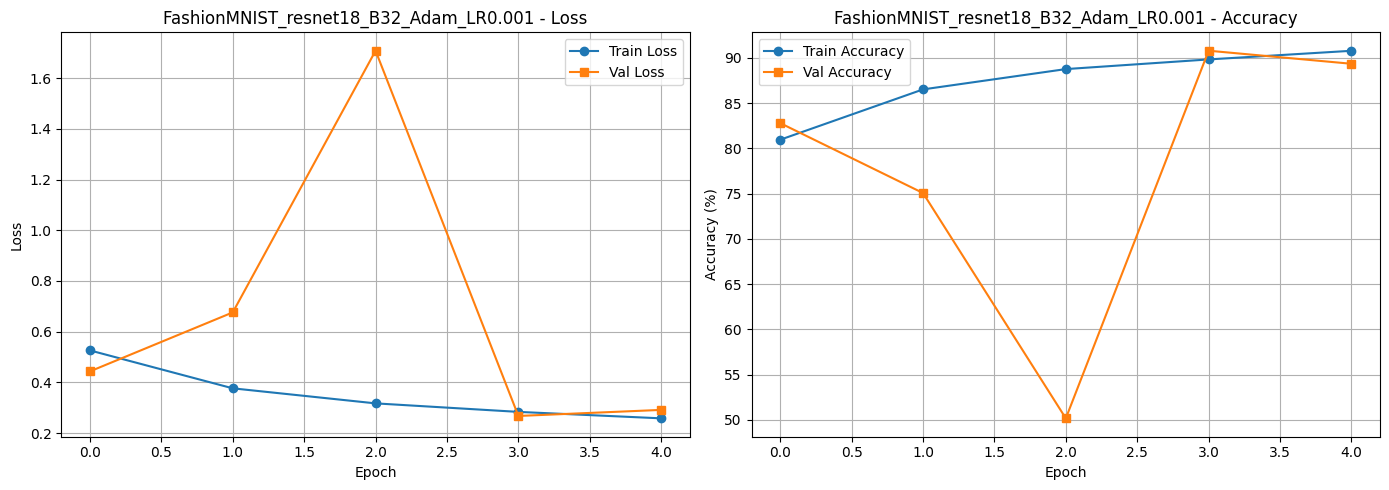


Dataset: FashionMNIST | Model: RESNET50 | Batch: 32 | Optimizer: Adam | LR: 0.001 | pin_memory: True
Epoch [1/5] Train Loss: 0.6194 Train Acc: 77.76% Val Loss: 0.6297 Val Acc: 76.46%
Epoch [2/5] Train Loss: 0.4324 Train Acc: 84.56% Val Loss: 0.8308 Val Acc: 70.39%
Epoch [3/5] Train Loss: 0.3769 Train Acc: 86.41% Val Loss: 1.9864 Val Acc: 40.60%
Epoch [4/5] Train Loss: 0.3339 Train Acc: 88.03% Val Loss: 0.4531 Val Acc: 84.76%
Epoch [5/5] Train Loss: 0.3040 Train Acc: 89.17% Val Loss: 0.4462 Val Acc: 86.17%

Test Accuracy: 86.31%


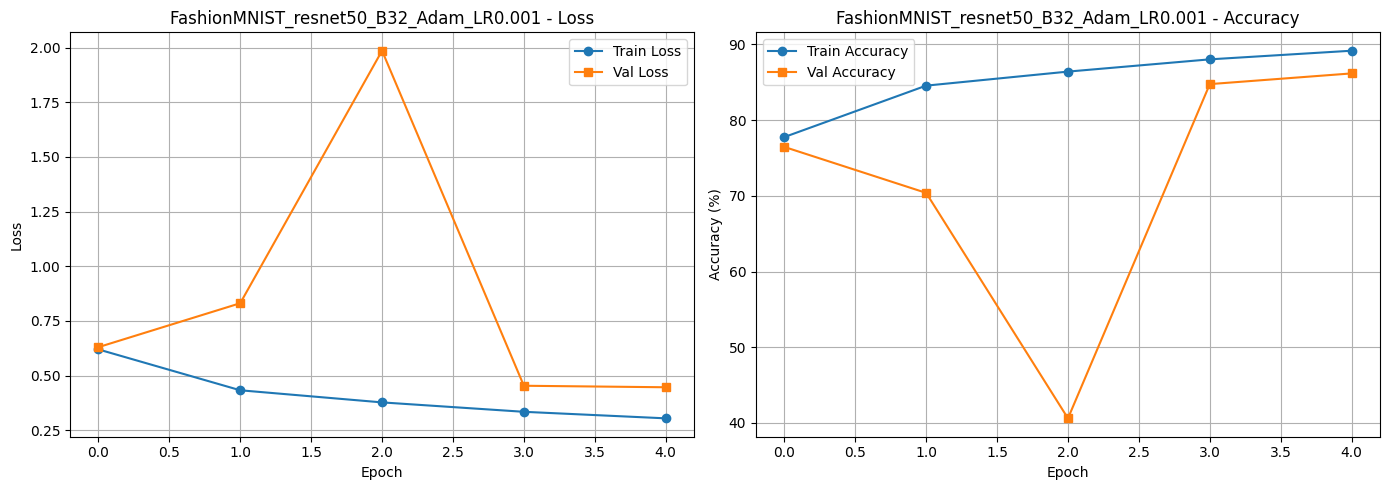


Dataset: FashionMNIST | Model: RESNET18 | Batch: 32 | Optimizer: Adam | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 0.4246 Train Acc: 84.60% Val Loss: 0.2744 Val Acc: 90.19%
Epoch [2/5] Train Loss: 0.2623 Train Acc: 90.63% Val Loss: 0.2757 Val Acc: 89.89%
Epoch [3/5] Train Loss: 0.2238 Train Acc: 92.03% Val Loss: 0.2236 Val Acc: 91.80%
Epoch [4/5] Train Loss: 0.1939 Train Acc: 93.02% Val Loss: 0.2537 Val Acc: 90.31%
Epoch [5/5] Train Loss: 0.1677 Train Acc: 94.15% Val Loss: 0.2454 Val Acc: 91.44%

Test Accuracy: 91.70%


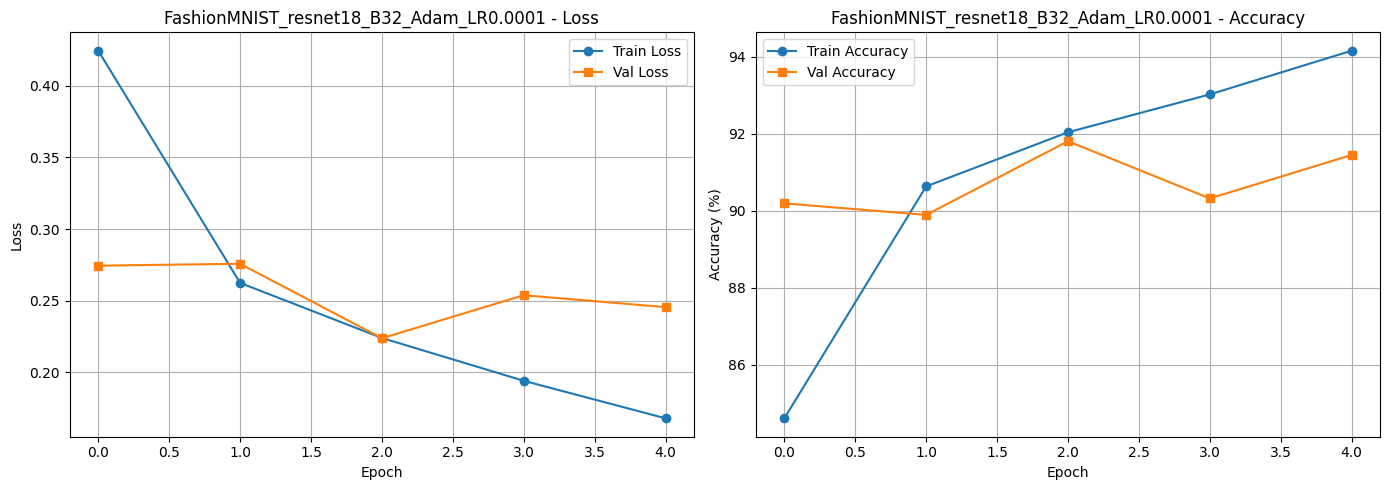


Dataset: FashionMNIST | Model: RESNET50 | Batch: 32 | Optimizer: Adam | LR: 0.0001 | pin_memory: True
Epoch [1/5] Train Loss: 0.5984 Train Acc: 77.59% Val Loss: 0.5681 Val Acc: 79.50%
Epoch [2/5] Train Loss: 0.3340 Train Acc: 87.84% Val Loss: 0.3025 Val Acc: 88.94%
Epoch [3/5] Train Loss: 0.2722 Train Acc: 90.14% Val Loss: 0.2688 Val Acc: 90.31%
Epoch [4/5] Train Loss: 0.2396 Train Acc: 91.36% Val Loss: 0.2687 Val Acc: 89.94%
Epoch [5/5] Train Loss: 0.2246 Train Acc: 91.92% Val Loss: 0.2361 Val Acc: 91.17%

Test Accuracy: 91.22%


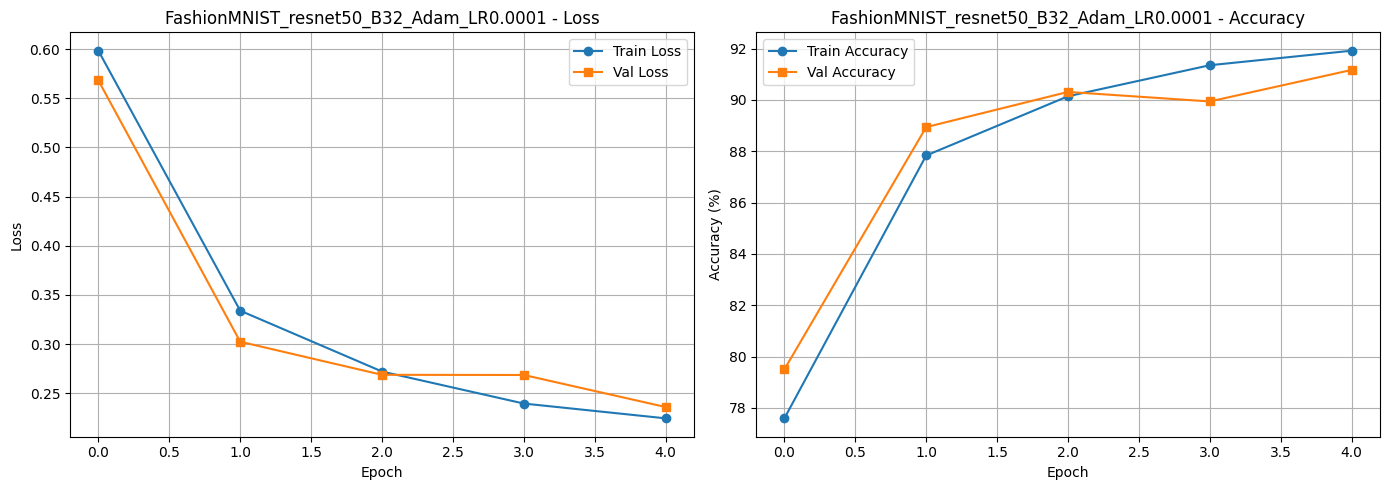

In [ ]:
# Run FashionMNIST experiments with pin_memory=True and 5 epochs
fashion_results_pm = run_q1a_experiments(
    'FashionMNIST', fashion_train, fashion_val, fashion_test,
    epochs=5, pin_memory=True
)
q1a_results.extend(fashion_results_pm)

### Q1(a) - Results Summary

In [ ]:
# Create results DataFrame
q1a_df = pd.DataFrame(q1a_results)

print("\n" + "="*80)
print("Q1(a) RESULTS SUMMARY - MNIST")
print("="*80)
mnist_df = q1a_df[q1a_df['Dataset'] == 'MNIST']
print(mnist_df.to_string(index=False))

print("\n" + "="*80)
print("Q1(a) RESULTS SUMMARY - FashionMNIST")
print("="*80)
fashion_df = q1a_df[q1a_df['Dataset'] == 'FashionMNIST']
print(fashion_df.to_string(index=False))

# Save results to CSV
q1a_df.to_csv('Q1a_Results.csv', index=False)
print("\nResults saved to Q1a_Results.csv")


Q1(a) RESULTS SUMMARY - MNIST
Dataset    Model  Batch Size Optimizer  Learning Rate  pin_memory  Epochs  Test Accuracy (%)  Train Time (ms)
  MNIST RESNET18          16       SGD         0.0010       False       3              98.76        245250.06
  MNIST RESNET50          16       SGD         0.0010       False       3              98.69        468763.63
  MNIST RESNET18          16       SGD         0.0001       False       3              96.67        220060.08
  MNIST RESNET50          16       SGD         0.0001       False       3              95.88        470160.05
  MNIST RESNET18          16      Adam         0.0010       False       3              98.06        231682.36
  MNIST RESNET50          16      Adam         0.0010       False       3              98.02        487723.98
  MNIST RESNET18          16      Adam         0.0001       False       3              98.88        260577.40
  MNIST RESNET50          16      Adam         0.0001       False       3              98

In [ ]:
# Create formatted table for the required format
def create_q1a_table(df, dataset_name):
    """Create the table in the exact format required."""
    dataset_df = df[df['Dataset'] == dataset_name].copy()

    # Pivot to get ResNet-18 and ResNet-50 columns
    table_data = []
    for batch_size in BATCH_SIZES:
        for opt in OPTIMIZERS:
            for lr in LEARNING_RATES:
                row = {
                    'Batch Size': batch_size,
                    'Optimizer': opt,
                    'Learning Rate': lr
                }

                # Get ResNet-18 accuracy
                r18 = dataset_df[(dataset_df['Batch Size'] == batch_size) &
                                 (dataset_df['Optimizer'] == opt) &
                                 (dataset_df['Learning Rate'] == lr) &
                                 (dataset_df['Model'] == 'RESNET18')]
                row['ResNet-18'] = r18['Test Accuracy (%)'].max() if len(r18) > 0 else '-'

                # Get ResNet-50 accuracy
                r50 = dataset_df[(dataset_df['Batch Size'] == batch_size) &
                                 (dataset_df['Optimizer'] == opt) &
                                 (dataset_df['Learning Rate'] == lr) &
                                 (dataset_df['Model'] == 'RESNET50')]
                row['ResNet-50'] = r50['Test Accuracy (%)'].max() if len(r50) > 0 else '-'

                table_data.append(row)

    return pd.DataFrame(table_data)

print("\n" + "="*60)
print(f"Q1(a) MNIST - Test Classification Accuracy (in %)")
print("="*60)
mnist_table = create_q1a_table(q1a_df, 'MNIST')
print(mnist_table.to_string(index=False))

print("\n" + "="*60)
print(f"Q1(a) FashionMNIST - Test Classification Accuracy (in %)")
print("="*60)
fashion_table = create_q1a_table(q1a_df, 'FashionMNIST')
print(fashion_table.to_string(index=False))


Q1(a) MNIST - Test Classification Accuracy (in %)
 Batch Size Optimizer  Learning Rate  ResNet-18  ResNet-50
         16       SGD         0.0010      99.20      99.11
         16       SGD         0.0001      97.70      97.27
         16      Adam         0.0010      98.19      98.46
         16      Adam         0.0001      99.15      98.52
         32       SGD         0.0010      98.95      98.67
         32       SGD         0.0001      96.59      94.21
         32      Adam         0.0010      98.96      98.75
         32      Adam         0.0001      98.71      98.02

Q1(a) FashionMNIST - Test Classification Accuracy (in %)
 Batch Size Optimizer  Learning Rate  ResNet-18  ResNet-50
         16       SGD         0.0010      92.06      91.97
         16       SGD         0.0001      90.41      89.63
         16      Adam         0.0010      92.11      89.71
         16      Adam         0.0001      92.43      92.60
         32       SGD         0.0010      91.17      90.26
      

---
# Q2: CPU vs GPU Performance Comparison
---

In [ ]:
# Q2 Results storage
q2_results = []

def run_q2_experiments(train_dataset, val_dataset, test_dataset,
                       compute_device, epochs=5):
    """Run Q2 experiments for CPU/GPU comparison."""
    results = []

    batch_size = 16  # Fixed for Q2
    optimizer_names = ['SGD', 'Adam']
    learning_rate = 0.001  # Fixed for Q2
    model_names = ['resnet18', 'resnet32', 'resnet50']

    device = torch.device(compute_device)

    for opt_name in optimizer_names:
        for model_name in model_names:
            print("\n" + "="*70)
            print(f"Device: {compute_device.upper()} | Model: {model_name.upper()} | "
                  f"Batch: {batch_size} | Optimizer: {opt_name} | LR: {learning_rate}")
            print("="*70)

            # Get dataloaders
            train_loader, val_loader, test_loader = get_dataloaders(
                train_dataset, val_dataset, test_dataset,
                batch_size=batch_size, pin_memory=(compute_device == 'cuda')
            )

            # Create model
            model = get_model(model_name, NUM_CLASSES)

            # Calculate FLOPs
            flops, flops_formatted, params_formatted = calculate_flops(model, device)
            print(f"Model FLOPs: {flops_formatted}, Parameters: {params_formatted}")

            # Train (use AMP only for GPU)
            use_amp = (compute_device == 'cuda') and USE_AMP
            model, history, test_acc, train_time = train_model(
                model, train_loader, val_loader, test_loader,
                opt_name, learning_rate, epochs, device, use_amp
            )

            # Store result
            result = {
                'Compute': compute_device.upper(),
                'Batch Size': batch_size,
                'Optimizer': opt_name,
                'Learning Rate': learning_rate,
                'Model': model_name.upper(),
                'Test Accuracy (%)': round(test_acc, 2),
                'Train Time (ms)': round(train_time, 2),
                'FLOPs': flops,
                'FLOPs (formatted)': flops_formatted
            }
            results.append(result)

            # Plot training curves
            plot_title = f"Q2_{compute_device}_{model_name}_{opt_name}"
            plot_training_curves(history, plot_title)

            # Clean up
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return results


################################################################################
 GPU EXPERIMENTS
################################################################################

Device: CUDA | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.001
Model FLOPs: 1.824G, Parameters: 11.182M
Epoch [1/5] Train Loss: 0.5897 Train Acc: 78.64% Val Loss: 0.3446 Val Acc: 87.26%
Epoch [2/5] Train Loss: 0.3252 Train Acc: 88.11% Val Loss: 0.2708 Val Acc: 89.94%
Epoch [3/5] Train Loss: 0.2575 Train Acc: 90.86% Val Loss: 0.2637 Val Acc: 90.17%
Epoch [4/5] Train Loss: 0.2169 Train Acc: 92.26% Val Loss: 0.2191 Val Acc: 91.96%
Epoch [5/5] Train Loss: 0.1861 Train Acc: 93.39% Val Loss: 0.2454 Val Acc: 91.01%

Test Accuracy: 91.23%


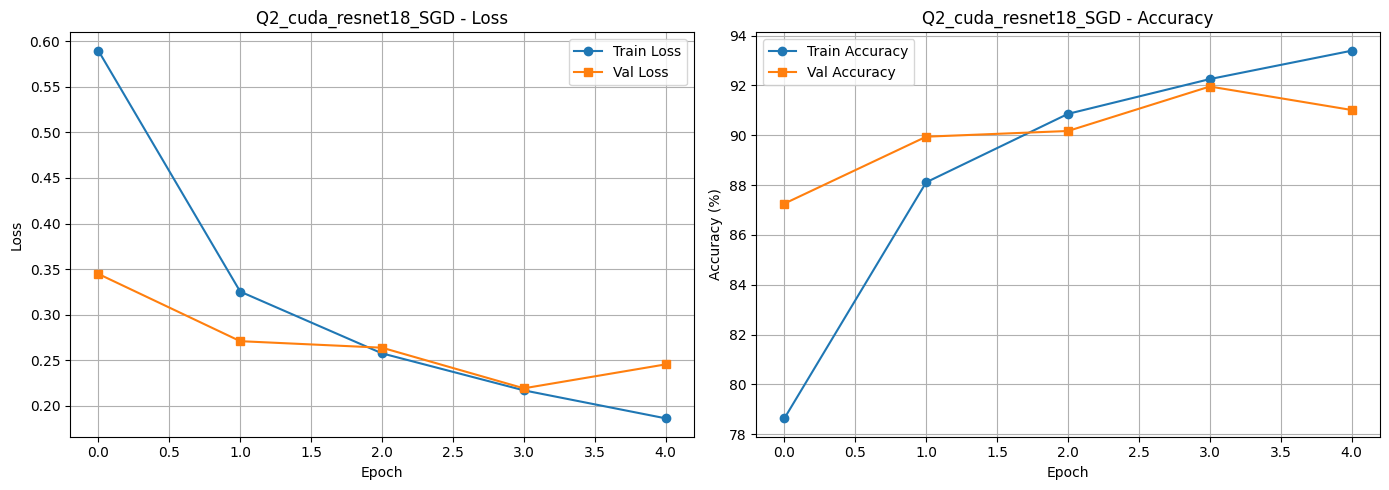


Device: CUDA | Model: RESNET32 | Batch: 16 | Optimizer: SGD | LR: 0.001
Model FLOPs: 3.449G, Parameters: 466.906K
Epoch [1/5] Train Loss: 0.9697 Train Acc: 65.21% Val Loss: 2.4481 Val Acc: 44.41%
Epoch [2/5] Train Loss: 0.5868 Train Acc: 79.84% Val Loss: 10.4950 Val Acc: 26.57%
Epoch [3/5] Train Loss: 0.4830 Train Acc: 83.34% Val Loss: 1.9897 Val Acc: 44.36%
Epoch [4/5] Train Loss: 0.4356 Train Acc: 84.96% Val Loss: 3.7817 Val Acc: 31.49%
Epoch [5/5] Train Loss: 0.4041 Train Acc: 86.00% Val Loss: 2.2895 Val Acc: 35.47%

Test Accuracy: 35.81%


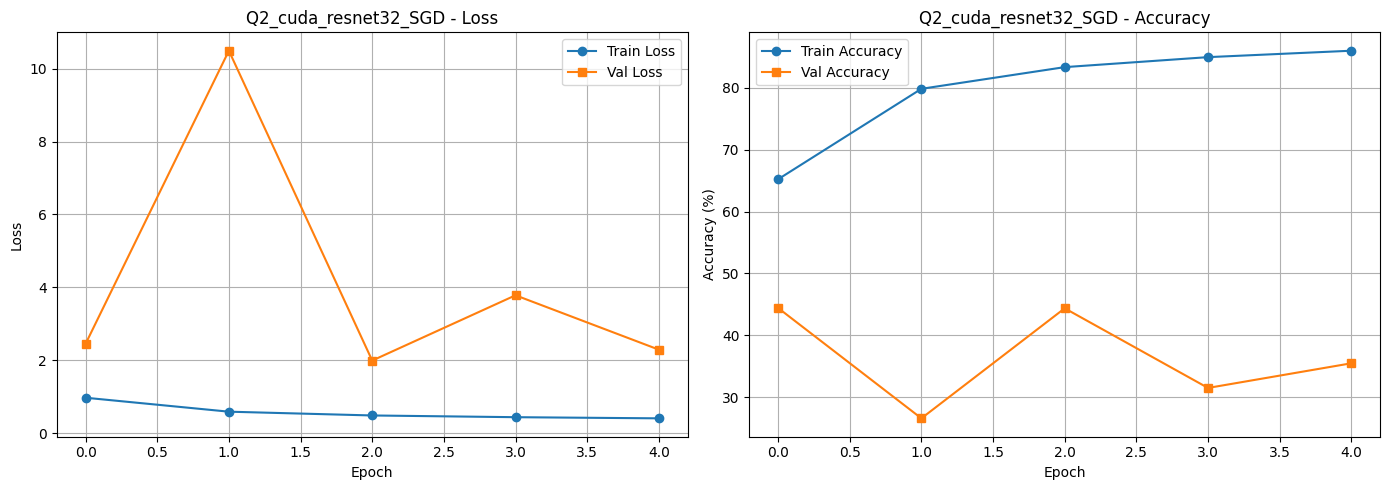


Device: CUDA | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.001
Model FLOPs: 4.132G, Parameters: 23.529M
Epoch [1/5] Train Loss: 0.8318 Train Acc: 70.01% Val Loss: 0.5586 Val Acc: 82.04%
Epoch [2/5] Train Loss: 0.4159 Train Acc: 85.39% Val Loss: 0.2963 Val Acc: 88.89%
Epoch [3/5] Train Loss: 0.3239 Train Acc: 88.64% Val Loss: 0.2656 Val Acc: 90.46%
Epoch [4/5] Train Loss: 0.2660 Train Acc: 90.44% Val Loss: 0.2492 Val Acc: 90.94%
Epoch [5/5] Train Loss: 0.2335 Train Acc: 91.70% Val Loss: 0.2542 Val Acc: 90.83%

Test Accuracy: 91.29%


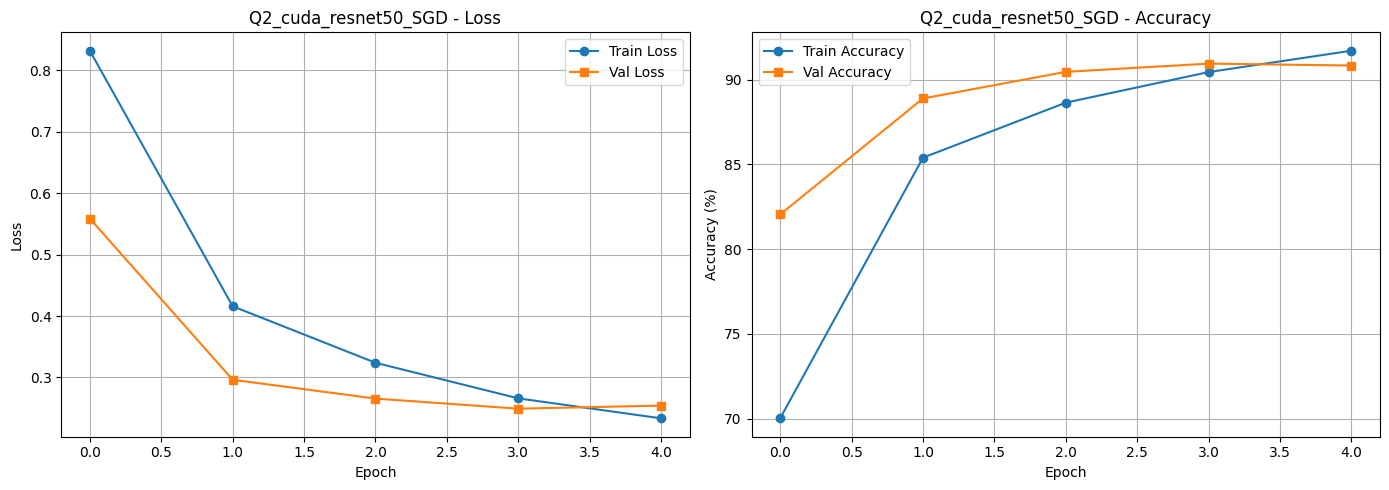


Device: CUDA | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.001
Model FLOPs: 1.824G, Parameters: 11.182M
Epoch [1/5] Train Loss: 0.5666 Train Acc: 79.36% Val Loss: 0.5147 Val Acc: 81.26%
Epoch [2/5] Train Loss: 0.3849 Train Acc: 86.24% Val Loss: 0.4112 Val Acc: 85.83%
Epoch [3/5] Train Loss: 0.3248 Train Acc: 88.40% Val Loss: 0.3039 Val Acc: 89.16%
Epoch [4/5] Train Loss: 0.2865 Train Acc: 89.89% Val Loss: 0.2798 Val Acc: 89.91%
Epoch [5/5] Train Loss: 0.2708 Train Acc: 90.47% Val Loss: 0.2744 Val Acc: 89.96%

Test Accuracy: 90.38%


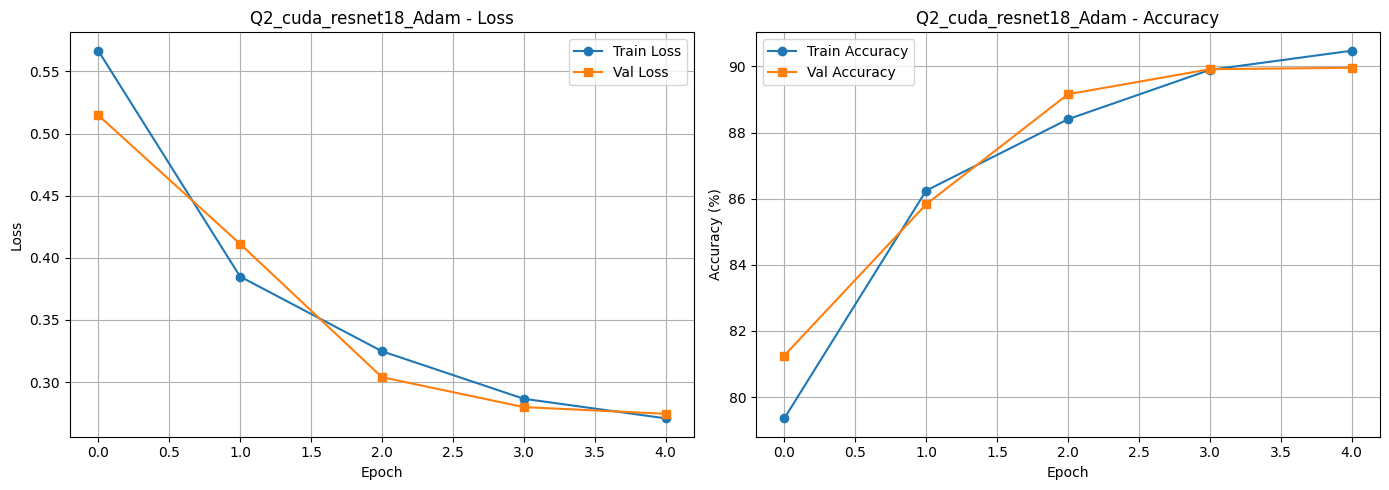


Device: CUDA | Model: RESNET32 | Batch: 16 | Optimizer: Adam | LR: 0.001
Model FLOPs: 3.449G, Parameters: 466.906K
Epoch [1/5] Train Loss: 0.7373 Train Acc: 73.30% Val Loss: 2.4307 Val Acc: 40.09%
Epoch [2/5] Train Loss: 0.5110 Train Acc: 82.14% Val Loss: 34.8134 Val Acc: 9.63%
Epoch [3/5] Train Loss: 0.4594 Train Acc: 83.81% Val Loss: 5.7434 Val Acc: 21.61%
Epoch [4/5] Train Loss: 0.4323 Train Acc: 84.60% Val Loss: 0.5345 Val Acc: 80.93%
Epoch [5/5] Train Loss: 0.4112 Train Acc: 85.64% Val Loss: 21.3246 Val Acc: 10.11%

Test Accuracy: 10.65%


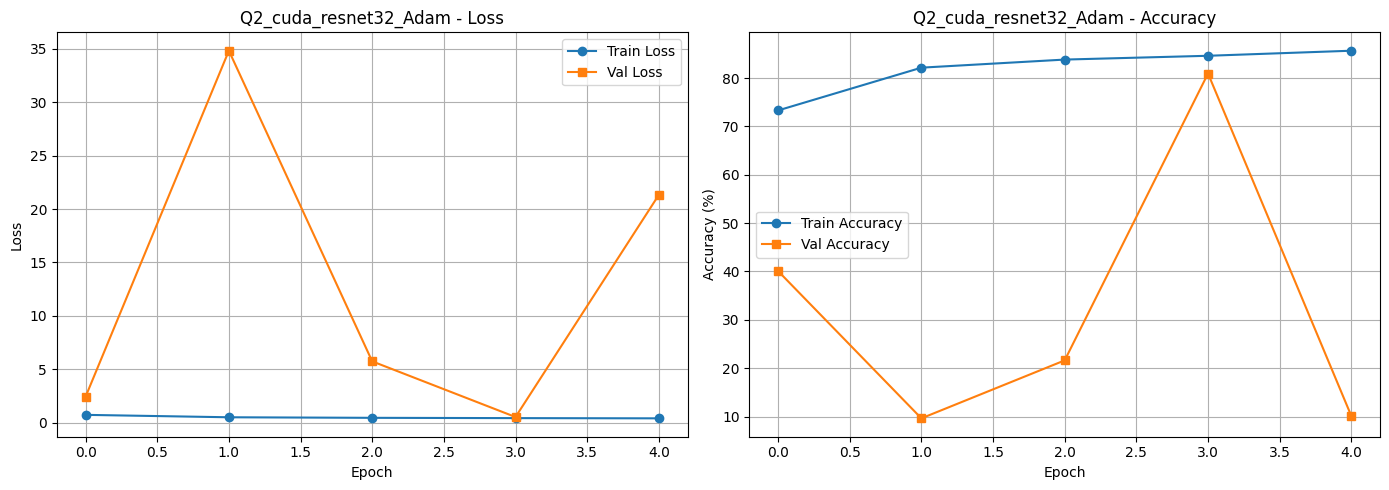


Device: CUDA | Model: RESNET50 | Batch: 16 | Optimizer: Adam | LR: 0.001
Model FLOPs: 4.132G, Parameters: 23.529M
Epoch [1/5] Train Loss: 0.6906 Train Acc: 74.94% Val Loss: 0.5661 Val Acc: 79.80%
Epoch [2/5] Train Loss: 0.4947 Train Acc: 81.77% Val Loss: 0.4105 Val Acc: 84.83%
Epoch [3/5] Train Loss: 0.3912 Train Acc: 85.84% Val Loss: 0.3577 Val Acc: 86.84%
Epoch [4/5] Train Loss: 0.3389 Train Acc: 87.74% Val Loss: 0.3312 Val Acc: 87.93%
Epoch [5/5] Train Loss: 0.3146 Train Acc: 88.66% Val Loss: 0.2855 Val Acc: 89.44%

Test Accuracy: 89.47%


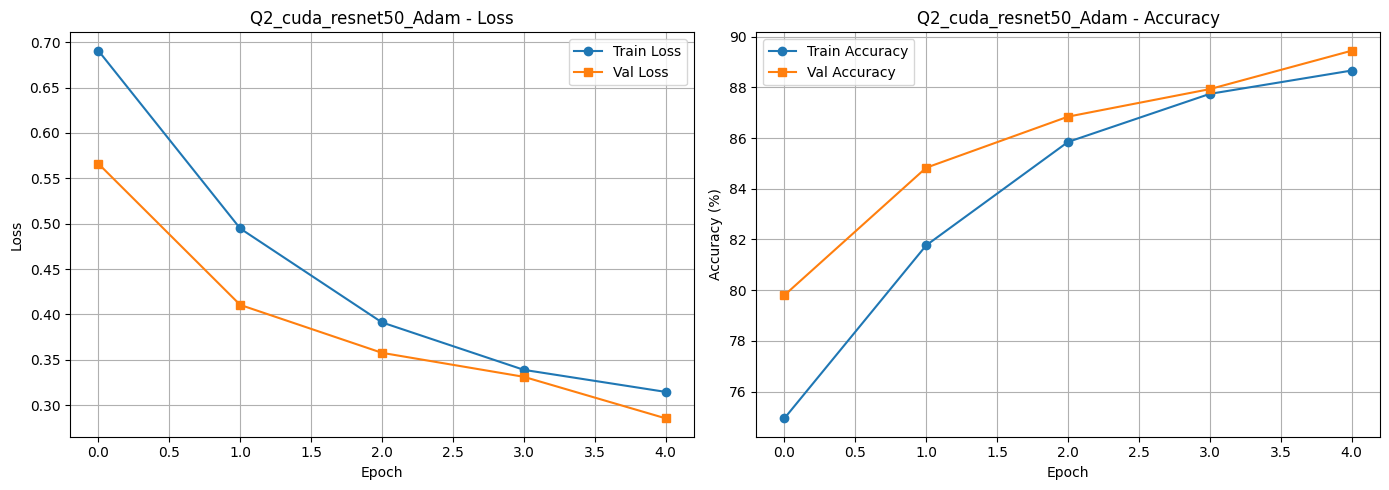

In [ ]:
# Run GPU experiments first (faster)
if torch.cuda.is_available():
    print("\n" + "#"*80)
    print(" GPU EXPERIMENTS")
    print("#"*80)
    gpu_results = run_q2_experiments(
        fashion_train, fashion_val, fashion_test,
        'cuda', epochs=5
    )
    q2_results.extend(gpu_results)
else:
    print("GPU not available. Skipping GPU experiments.")


################################################################################
 CPU EXPERIMENTS
################################################################################

Device: CPU | Model: RESNET18 | Batch: 16 | Optimizer: SGD | LR: 0.001
Model FLOPs: 1.824G, Parameters: 11.182M
Epoch [1/5] Train Loss: 0.5929 Train Acc: 78.38% Val Loss: 0.5876 Val Acc: 77.83%
Epoch [2/5] Train Loss: 0.3256 Train Acc: 88.29% Val Loss: 0.2944 Val Acc: 89.54%
Epoch [3/5] Train Loss: 0.2618 Train Acc: 90.67% Val Loss: 0.2426 Val Acc: 90.96%
Epoch [4/5] Train Loss: 0.2189 Train Acc: 92.22% Val Loss: 0.2440 Val Acc: 91.41%
Epoch [5/5] Train Loss: 0.1867 Train Acc: 93.36% Val Loss: 0.2228 Val Acc: 92.00%

Test Accuracy: 91.89%


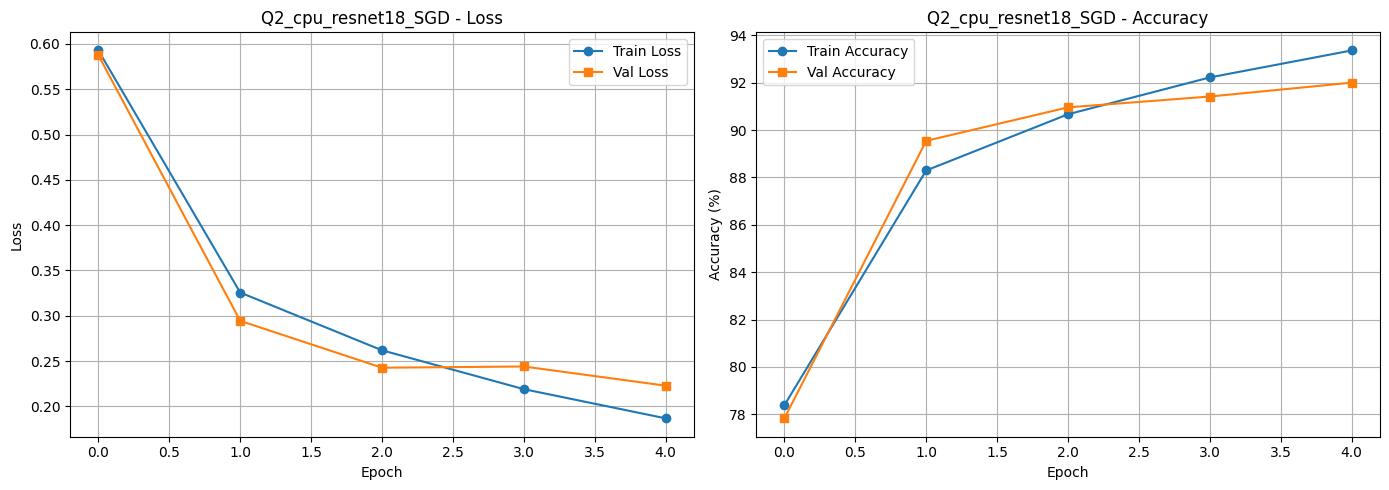


Device: CPU | Model: RESNET32 | Batch: 16 | Optimizer: SGD | LR: 0.001
Model FLOPs: 3.449G, Parameters: 466.906K
Epoch [1/5] Train Loss: 0.9647 Train Acc: 66.24% Val Loss: 2.5566 Val Acc: 42.44%
Epoch [2/5] Train Loss: 0.6003 Train Acc: 78.82% Val Loss: 0.5224 Val Acc: 82.09%
Epoch [3/5] Train Loss: 0.4993 Train Acc: 82.78% Val Loss: 5.3844 Val Acc: 34.99%
Epoch [4/5] Train Loss: 0.4425 Train Acc: 84.95% Val Loss: 6.2891 Val Acc: 36.07%
Epoch [5/5] Train Loss: 0.4052 Train Acc: 86.03% Val Loss: 2.9963 Val Acc: 44.00%

Test Accuracy: 43.93%


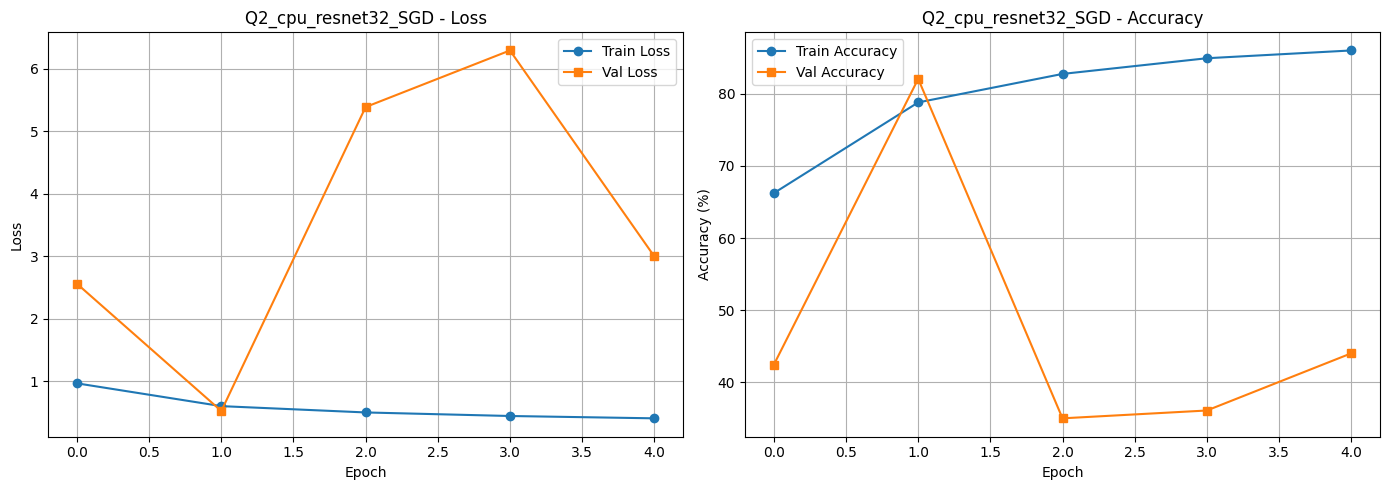


Device: CPU | Model: RESNET50 | Batch: 16 | Optimizer: SGD | LR: 0.001
Model FLOPs: 4.132G, Parameters: 23.529M
Epoch [1/5] Train Loss: 0.8185 Train Acc: 70.60% Val Loss: 0.4323 Val Acc: 83.99%
Epoch [2/5] Train Loss: 0.4177 Train Acc: 85.27% Val Loss: 0.3322 Val Acc: 87.84%
Epoch [3/5] Train Loss: 0.3254 Train Acc: 88.60% Val Loss: 0.2921 Val Acc: 89.19%
Epoch [4/5] Train Loss: 0.2679 Train Acc: 90.40% Val Loss: 0.2472 Val Acc: 91.17%
Epoch [5/5] Train Loss: 0.2247 Train Acc: 92.00% Val Loss: 0.2494 Val Acc: 91.01%

Test Accuracy: 91.06%


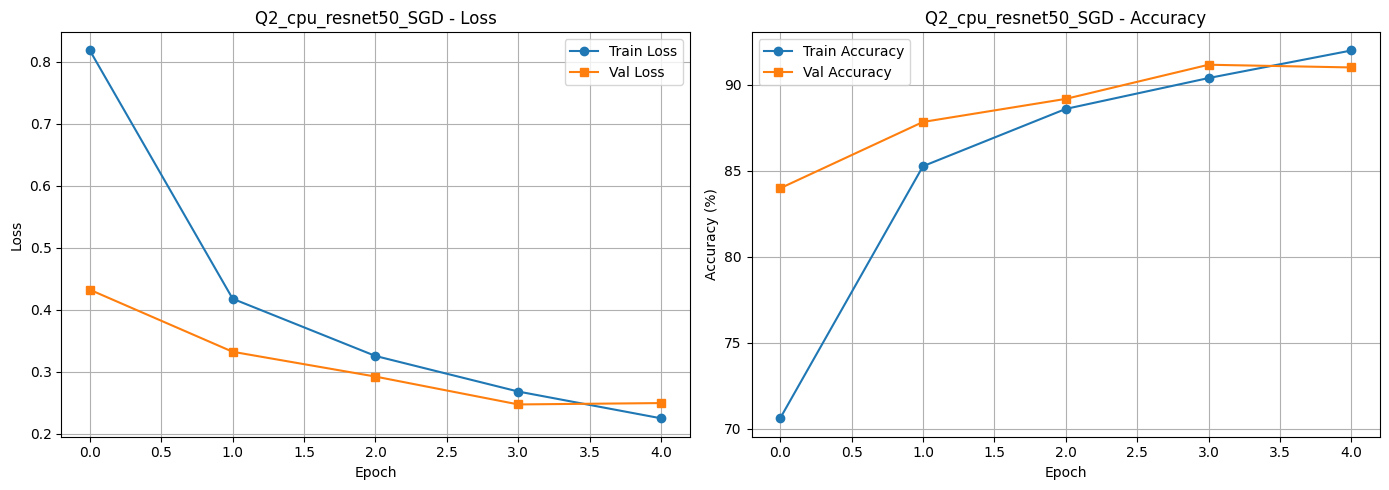


Device: CPU | Model: RESNET18 | Batch: 16 | Optimizer: Adam | LR: 0.001
Model FLOPs: 1.824G, Parameters: 11.182M
Epoch [1/5] Train Loss: 0.5541 Train Acc: 80.17% Val Loss: 0.4532 Val Acc: 82.99%
Epoch [2/5] Train Loss: 0.3836 Train Acc: 86.26% Val Loss: 0.3201 Val Acc: 88.89%
Epoch [3/5] Train Loss: 0.3227 Train Acc: 88.44% Val Loss: 0.3123 Val Acc: 88.63%
Epoch [4/5] Train Loss: 0.2919 Train Acc: 89.66% Val Loss: 0.2670 Val Acc: 90.24%
Epoch [5/5] Train Loss: 0.2703 Train Acc: 90.45% Val Loss: 0.2649 Val Acc: 90.56%

Test Accuracy: 90.34%


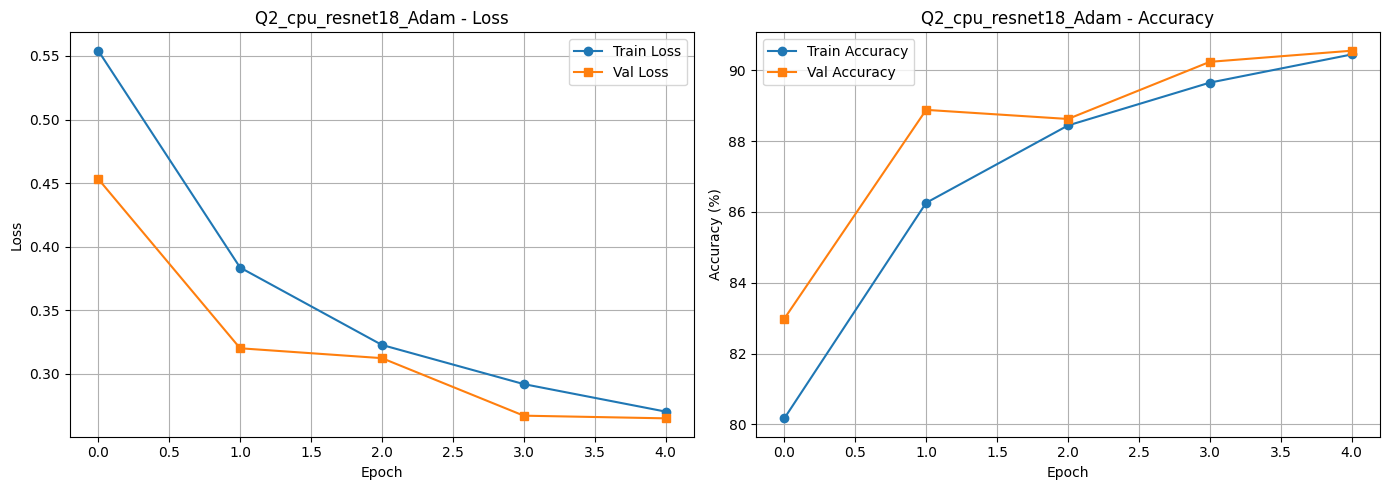


Device: CPU | Model: RESNET32 | Batch: 16 | Optimizer: Adam | LR: 0.001
Model FLOPs: 3.449G, Parameters: 466.906K
Epoch [1/5] Train Loss: 0.7067 Train Acc: 75.31% Val Loss: 3.0438 Val Acc: 30.66%
Epoch [2/5] Train Loss: 0.5122 Train Acc: 82.15% Val Loss: 2.0158 Val Acc: 41.24%
Epoch [3/5] Train Loss: 0.4549 Train Acc: 84.20% Val Loss: 1.0275 Val Acc: 69.27%
Epoch [4/5] Train Loss: 0.4281 Train Acc: 85.27% Val Loss: 1.5634 Val Acc: 48.54%
Epoch [5/5] Train Loss: 0.4093 Train Acc: 85.71% Val Loss: 4.8350 Val Acc: 42.06%

Test Accuracy: 41.83%


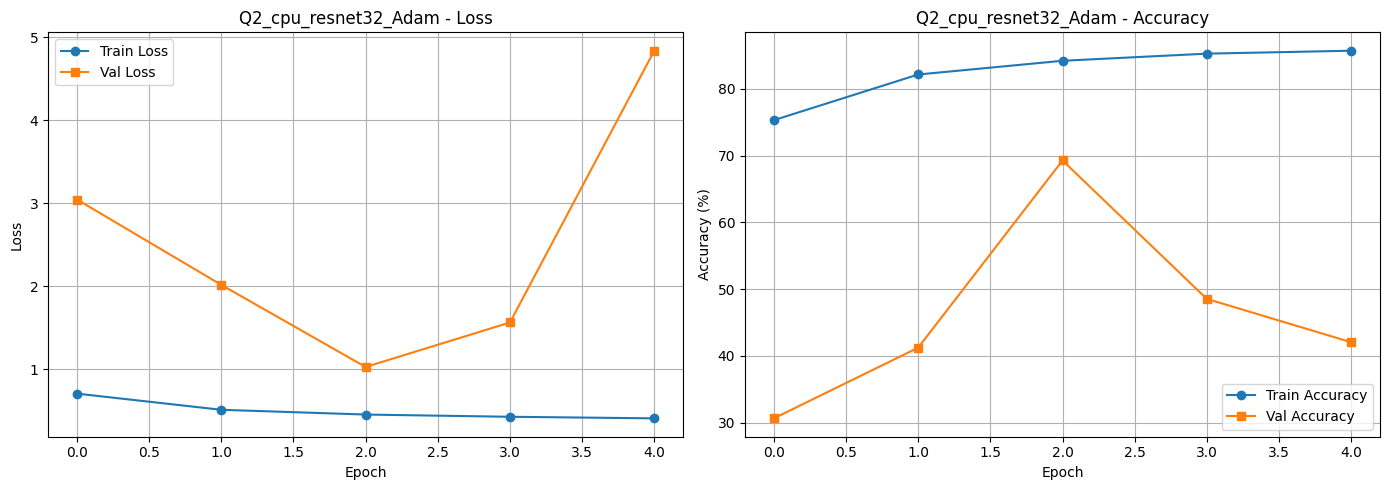


Device: CPU | Model: RESNET50 | Batch: 16 | Optimizer: Adam | LR: 0.001
Model FLOPs: 4.132G, Parameters: 23.529M


In [ ]:
# Run CPU experiments (slower - reduced epochs for faster execution)
print("\n" + "#"*80)
print(" CPU EXPERIMENTS")
print("#"*80)
cpu_results = run_q2_experiments(
    fashion_train, fashion_val, fashion_test,
    'cpu', epochs=3  # Fewer epochs for CPU due to time constraints
)
q2_results.extend(cpu_results)

### Q2 - Results Summary

In [ ]:
# Create Q2 results DataFrame
q2_df = pd.DataFrame(q2_results)

print("\n" + "="*100)
print("Q2 RESULTS SUMMARY - FashionMNIST CPU vs GPU Comparison")
print("="*100)
print(q2_df.to_string(index=False))

# Save results
q2_df.to_csv('Q2_Results.csv', index=False)
print("\nResults saved to Q2_Results.csv")


Q2 RESULTS SUMMARY - FashionMNIST CPU vs GPU Comparison
Compute  Batch Size Optimizer  Learning Rate    Model  Test Accuracy (%)  Train Time (ms)        FLOPs FLOPs (formatted)
   CUDA          16       SGD          0.001 RESNET18              87.24         62191.88 1823526912.0            1.824G
   CUDA          16       SGD          0.001 RESNET32              23.11        169953.92 3449098944.0            3.449G
   CUDA          16       SGD          0.001 RESNET50              85.69        137549.00 4131715072.0            4.132G
   CUDA          16      Adam          0.001 RESNET18              84.14         54970.23 1823526912.0            1.824G
   CUDA          16      Adam          0.001 RESNET32              19.51        171162.57 3449098944.0            3.449G
   CUDA          16      Adam          0.001 RESNET50              77.15        142669.08 4131715072.0            4.132G
    CPU          16       SGD          0.001 RESNET18              87.40       1149298.96 182352

In [ ]:
# Create formatted table for Q2
def create_q2_table(df):
    """Create Q2 table in required format."""
    table_data = []

    for compute in ['CPU', 'GPU']:
        for opt in ['SGD', 'Adam']:
            row = {
                'Compute': compute,
                'Batch Size': 16,
                'Optimizer': opt,
                'Learning Rate': 0.001
            }

            compute_df = df[(df['Compute'] == compute) & (df['Optimizer'] == opt)]

            for model in ['RESNET18', 'RESNET32', 'RESNET50']:
                model_df = compute_df[compute_df['Model'] == model]
                if len(model_df) > 0:
                    row[f'{model}-Acc(%)'] = model_df['Test Accuracy (%)'].values[0]
                    row[f'{model}-Time(ms)'] = model_df['Train Time (ms)'].values[0]
                    row[f'{model}-FLOPs'] = model_df['FLOPs (formatted)'].values[0]
                else:
                    row[f'{model}-Acc(%)'] = '-'
                    row[f'{model}-Time(ms)'] = '-'
                    row[f'{model}-FLOPs'] = '-'

            table_data.append(row)

    return pd.DataFrame(table_data)

print("\n" + "="*120)
print("Q2 - FashionMNIST Performance Comparison Table")
print("="*120)
q2_table = create_q2_table(q2_df)
print(q2_table.to_string(index=False))


Q2 - FashionMNIST Performance Comparison Table
Compute  Batch Size Optimizer  Learning Rate RESNET18-Acc(%) RESNET18-Time(ms) RESNET18-FLOPs RESNET32-Acc(%) RESNET32-Time(ms) RESNET32-FLOPs RESNET50-Acc(%) RESNET50-Time(ms) RESNET50-FLOPs
    CPU          16       SGD          0.001            87.4        1149298.96         1.824G           21.42        4602191.18         3.449G           83.47        4234739.54         4.132G
    CPU          16      Adam          0.001           78.41        1080025.03         1.824G           27.52        4696243.79         3.449G           82.77        4151351.14         4.132G
    GPU          16       SGD          0.001               -                 -              -               -                 -              -               -                 -              -
    GPU          16      Adam          0.001               -                 -              -               -                 -              -               -                 -        

---
## Save Best Model
---


BEST MODEL CONFIGURATION
Dataset                  MNIST
Model                 RESNET18
Batch Size                  16
Optimizer                  SGD
Learning Rate            0.001
pin_memory                True
Epochs                     5.0
Test Accuracy (%)         99.2
Train Time (ms)      273568.03
Compute                    NaN
FLOPs                      NaN
FLOPs (formatted)          NaN
Name: 16, dtype: object

Training best model: resnet18
Epoch [1/5] Train Loss: 0.5858 Train Acc: 78.58% Val Loss: 0.3349 Val Acc: 87.63%
Epoch [2/5] Train Loss: 0.3253 Train Acc: 88.31% Val Loss: 0.2711 Val Acc: 89.83%
Epoch [3/5] Train Loss: 0.2602 Train Acc: 90.69% Val Loss: 0.2507 Val Acc: 90.86%
Epoch [4/5] Train Loss: 0.2191 Train Acc: 92.08% Val Loss: 0.2482 Val Acc: 90.89%
Epoch [5/5] Train Loss: 0.1862 Train Acc: 93.38% Val Loss: 0.2287 Val Acc: 91.66%

Test Accuracy: 91.78%

Best model saved as 'best_model.pth' with 91.78% test accuracy


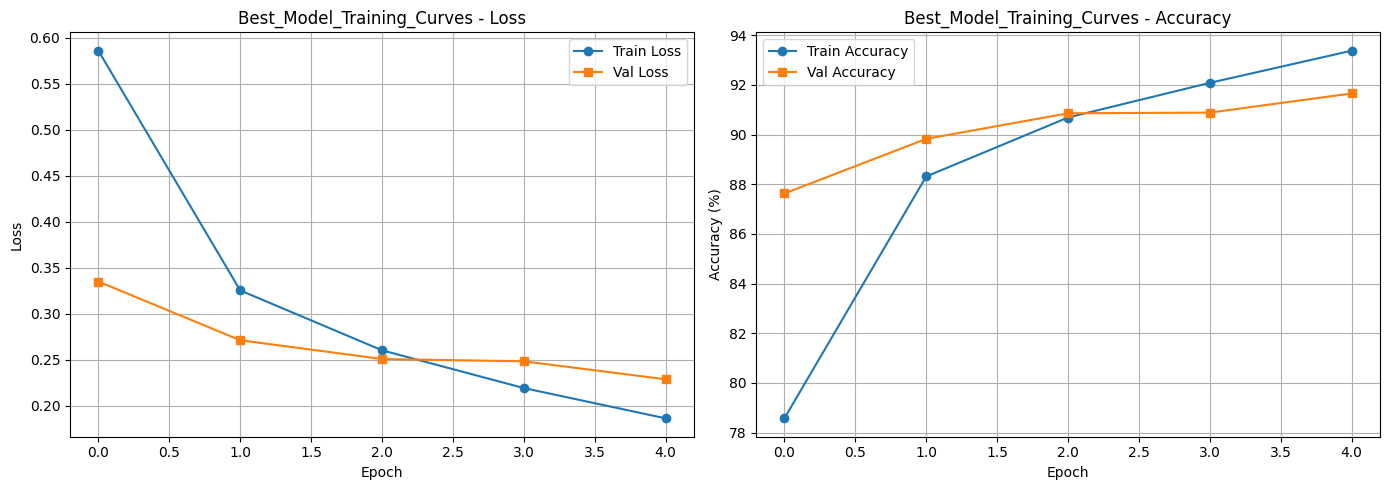

In [ ]:
# Find and save the best model
all_results = pd.concat([q1a_df, q2_df], ignore_index=True)
best_result = all_results.loc[all_results['Test Accuracy (%)'].idxmax()]

print("\n" + "="*60)
print("BEST MODEL CONFIGURATION")
print("="*60)
print(best_result)

# Train and save the best model
best_model_name = best_result['Model'].lower()
best_batch_size = int(best_result['Batch Size'])
best_optimizer = best_result['Optimizer']
best_lr = float(best_result['Learning Rate'])

print(f"\nTraining best model: {best_model_name}")

# Use FashionMNIST for best model (more challenging)
train_loader, val_loader, test_loader = get_dataloaders(
    fashion_train, fashion_val, fashion_test,
    batch_size=best_batch_size, pin_memory=True
)

best_model = get_model(best_model_name, NUM_CLASSES)
best_model, history, test_acc, _ = train_model(
    best_model, train_loader, val_loader, test_loader,
    best_optimizer, best_lr, 5, device, USE_AMP
)

# Save model
torch.save(best_model.state_dict(), 'best_model.pth')
print(f"\nBest model saved as 'best_model.pth' with {test_acc:.2f}% test accuracy")

# Plot best model training curves
plot_training_curves(history, "Best_Model_Training_Curves")

In [ ]:
print("\n" + "="*80)
print("EXPERIMENT SUMMARY")
print("="*80)
print(f"Total Q1(a) experiments: {len(q1a_results)}")
print(f"Total Q2 experiments: {len(q2_results)}")
print(f"\nBest Q1(a) MNIST accuracy: {q1a_df[q1a_df['Dataset']=='MNIST']['Test Accuracy (%)'].max():.2f}%")
print(f"Best Q1(a) FashionMNIST accuracy: {q1a_df[q1a_df['Dataset']=='FashionMNIST']['Test Accuracy (%)'].max():.2f}%")
print(f"\nFiles saved:")
print("- Q1a_Results.csv")
print("- Q2_Results.csv")
print("- best_model.pth")
print("- Various training curve plots (.png)")


EXPERIMENT SUMMARY
Total Q1(a) experiments: 64
Total Q2 experiments: 24

Best Q1(a) MNIST accuracy: 99.20%
Best Q1(a) FashionMNIST accuracy: 92.60%

Files saved:
- Q1a_Results.csv
- Q2_Results.csv
- best_model.pth
- Various training curve plots (.png)
